# Innit


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import random

from pycaret.regression import *

from sklearn.preprocessing import StandardScaler, OneHotEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.decomposition import PCA
from sklearn.linear_model import Ridge
from sklearn.feature_selection import VarianceThreshold, RFE
from lightgbm import LGBMRegressor

import tensorflow as tf
from tensorflow.keras.layers import Input, Dense, Layer, BatchNormalization, Dropout
from tensorflow.keras.models import Model
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

import torch
import torch.nn as nn
import torch.nn.functional as F

def set_seeds(seed=42):
    """
    Sets the seed for reproducibility across Python, NumPy, and TensorFlow.
    """
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

    # 5. Enforce deterministic behavior (TF ≥ 2.9)
    try:
        tf.config.experimental.enable_op_determinism()
    except Exception:
        pass

    torch.manual_seed(seed)
    # For newer versions of TF/Keras to ensure deterministic behavior on GPU if possible
    os.environ['TF_DETERMINISTIC_OPS'] = '1'
    print(f"Random seed set to: {seed}")
set_seeds(42)

gw = 24

2026-02-25 22:31:52.935787: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Random seed set to: 42


## Functions


In [2]:
def working_df(data, gw, features=None, joint=False):
    # # Split
    # GW_TRAIN_END = gw - 1
    # train_mask = GW_full <= GW_TRAIN_END
    # test_mask = GW_full == (GW_TRAIN_END + 1)

    GW_TRAIN_END = gw - 1
    if joint:
        GW_full = data[['round', 'season']]
        train_mask = (GW_full['season'] == 2024) | ((GW_full['season'] == 2025) & (GW_full['round'] <= GW_TRAIN_END))
        test_mask = ((GW_full['season'] == 2025) &  (GW_full['round'] == (GW_TRAIN_END + 1))) # GW_full == (GW_TRAIN_END + 1)
    else:
        GW_full = data['round'].values
        train_mask = GW_full <= GW_TRAIN_END
        test_mask = GW_full == (GW_TRAIN_END + 1)

    train_data = data[train_mask]
    test_data = data[test_mask]

    test_player_names = test_data['fpl_name'].values
    test_player_ids = test_data['fpl_id'].values
    # test_player_positions = test_data['position'].values
    test_data = test_data.drop(columns=['fpl_name', 'fpl_id', 'team_id', 'round'])
    train_data = train_data.drop(columns=['fpl_name', 'fpl_id', 'team_id', 'round'])

    return train_data, test_data, test_player_names, test_player_ids, test_mask

def plot_preds(preds, position, gw, full_data, test_mask):
    # xp_actual = test_target
    # xp_pred = preds #['prediction_label'].values
    # position = data_25_26[test_mask]['position'].values

    preds_data = pd.DataFrame({
        'fpl_name': full_data[test_mask]['fpl_name'].values,
        'Actual_xP':  full_data[test_mask]['xP'].values,
        'Pred_xP': preds,
        'position': full_data[test_mask]['position'].values
    })

    position = position
    names = preds_data[preds_data['position'] == position]['fpl_name'].values
    xp_actual = preds_data[preds_data['position'] == position]['Actual_xP'].values
    xp_pred = preds_data[preds_data['position'] == position]['Pred_xP'].values


    # Convert names to positions on x-axis
    x = np.arange(len(names))

    plt.figure(figsize=(14, 6))

    # Plot actual points
    plt.plot(x, xp_actual, marker='o', linewidth=2, label='Actual Points')

    # Plot predicted points
    plt.plot(x, xp_pred, marker='x', linewidth=2, label='Predicted Points')

    # Improve readability
    plt.xticks(x, names, rotation=75, ha='right')
    plt.xlabel("Players")
    plt.ylabel("Points")
    plt.title(f" : Actual vs Predicted Points per Player for position {position} (GW {gw})")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Width of each bar
    width = 0.31

    plt.figure(figsize=(14, 6))

    # Bars
    plt.bar(x - width/2, xp_actual, width, label='Actual Points')
    plt.bar(x + width/2, xp_pred, width, label='Predicted Points')

    # Labels & formatting
    plt.xticks(x, names, rotation=75, ha='right')
    plt.xlabel("Players")
    plt.ylabel("Points")
    plt.title(f" {position} : Actual vs Predicted Points per Player for position {position} (GW {gw})")
    plt.legend()

    plt.tight_layout()
    plt.show()


### AffinePNN


In [ ]:
# --- Step 1: Data Preparation Function ---
def prepare_fpl_data(data, cols, joint):
    """
    Prepares features (X), conditional parameters (M), targets (Y),
    and gameweeks (GW) for the AffinePNN model.
    """

    data_ = data.copy()

    if joint:
        print('joint')
        data_ = data_.rename(columns={'xP_25': 'xP'})

    # Target and metadata columns
    target_col = ['xP', 'fpl_name']

    POSITION_COL = 'position'
    M_COLS = ['was_home_False', 'was_home_True', 'position_DEF', 'position_FWD', 'position_GK', 'position_MID','win_prob', 'draw_prob', 'lose_prob'] #, 'whh', 'whd', 'wha'

    # 2. Target Variable (Y)
    Y = data_[target_col].fillna(0)

    # 3. Input Features (X)
    if joint:
        gameweek_col = ['round', 'season']
        EXCLUDE_COLS = [*target_col, *gameweek_col, *M_COLS]

    else:
        gameweek_col = 'round'
        EXCLUDE_COLS = [*target_col, gameweek_col, *M_COLS]

    # Find position-related columns for explicit inclusion if needed
    new_position_cols = [col for col in data_.columns if col.startswith(f'{POSITION_COL}_')]

    # Filter feature columns
    X_cols = [c for c in data_.columns if c not in EXCLUDE_COLS and c != POSITION_COL]

    # Final check of column existence
    X_cols = [col for col in X_cols if col in cols]

    # Convert to numpy
    X_ids = data_['fpl_id'].values
    X = data_[X_cols]#.drop(columns=['fpl_id', 'round', 'fpl_name', 'position', 'team_id', 'team',
    #    'opponent_team', 'was_home',])
    X = X.fillna(0).values.astype(np.float32)

    M = data_[M_COLS].fillna(0).values.astype(np.float32)

    if joint:
        GW = data_[gameweek_col]
    else:
        GW = data_['round']

    print(f"Data prepared. X shape: {X.shape}, M shape: {M.shape}, Y shape: {Y.shape}")
    return X, M, Y, GW, X_cols, X_ids

def transform_data(df, cols, gw, joint):
    # Prepare data
    X_full, M_full, Y_full, GW_full, X_cols, X_ids = prepare_fpl_data(df, cols, joint)


    GW_TRAIN_END = gw - 1
    if joint:
        train_mask = (GW_full['season'] == 2024) | ((GW_full['season'] == 2025) & (GW_full['round'] <= GW_TRAIN_END))
        test_mask = ((GW_full['season'] == 2025) &  (GW_full['round'] == (GW_TRAIN_END + 1))) # GW_full == (GW_TRAIN_END + 1)
    else:
        train_mask = GW_full <= GW_TRAIN_END
        test_mask = GW_full == (GW_TRAIN_END + 1)

    X_train, M_train, Y_train_raw = X_full[train_mask], M_full[train_mask], Y_full[train_mask]
    X_test, M_test, Y_test_raw, X_test_ids = X_full[test_mask], M_full[test_mask], Y_full[test_mask], X_ids[test_mask]

    Y_train = Y_train_raw['xP'].values
    Y_train_names = Y_train_raw['fpl_name'].values

    Y_test = Y_test_raw['xP'].values
    Y_test_names = Y_test_raw['fpl_name'].values

    # Scaling
    scaler_x = StandardScaler()
    X_train_scaled = scaler_x.fit_transform(X_train)

    if X_test.size > 0:
        X_test_scaled = scaler_x.transform(X_test)
    else:
        X_test_scaled = scaler_x

    scaler_m = StandardScaler()
    M_train_scaled = scaler_m.fit_transform(M_train)

    if M_test.size > 0:
        M_test_scaled = scaler_m.transform(M_test)
    else:
        M_test_scaled = scaler_m

    # Scale Y if needed
    scaler_y = MinMaxScaler()
    Y_train_scaled = scaler_y.fit_transform(Y_train.reshape(-1, 1)).flatten()

    # print('----', Y_train)

    return (X_train_scaled, M_train_scaled, train_mask, Y_train, Y_train_names), (X_test_scaled, M_test_scaled, test_mask, Y_test, Y_test_names, X_test_ids), GW_full, X_cols, scaler_y#, scaler_x, scaler_m


In [4]:

# --- Step 2: Custom Affine Conditioning Layer ---
class AffineConditioning(Layer):
    """
    Custom Keras Layer implementing the core Affine Parametric Neural Network (AffinePNN) logic.
    z = (phi * m + s0) * x + (psi * m + b0)
    """
    def __init__(self, units, activation=None, **kwargs):
        super(AffineConditioning, self).__init__(**kwargs)
        self.units = units
        self.activation = tf.keras.activations.get(activation)

    def build(self, input_shape):
        # input_shape: [feature_input_shape, parameter_input_shape]
        feature_dim = input_shape[0][-1]
        param_dim = input_shape[1][-1]

        # Weights to transform the parameter 'm' into scale and bias adjustments
        # Shape is (param_dim, feature_dim) to map conditions to feature space
        self.phi = self.add_weight(shape=(param_dim, feature_dim),
                                   initializer='glorot_uniform', trainable=True, name='phi')
        self.psi = self.add_weight(shape=(param_dim, feature_dim),
                                   initializer='glorot_uniform', trainable=True, name='psi')

        # Base scaling and bias
        # self.s0 = self.add_weight(shape=(feature_dim,), initializer='ones', trainable=True, name='s0')
        self.b0 = self.add_weight(shape=(feature_dim,), initializer='zeros', trainable=True, name='b0')

        self.built = True

    def call(self, inputs):
        x_in, m = inputs # x_in: (batch, feat), m: (batch, cond)

        # Calculate scale and bias based on conditional input m
        # (batch, cond) @ (cond, feat) -> (batch, feat)
        s_m = tf.matmul(m, self.phi)
        b_m = tf.matmul(m, self.psi)

        s = 1.0 + 0.5 * tf.tanh(s_m) # s_m + self.s0
        b = b_m + self.b0

        # Apply affine transformation
        x_out = s * x_in + b

        if self.activation is not None:
            return self.activation(x_out)
        return x_out

    def get_config(self):
        config = super(AffineConditioning, self).get_config()
        config.update({
            'units': self.units,
            'activation': tf.keras.activations.serialize(self.activation),
        })
        return config

# --- Step 3: Model Architecture ---
def build_affine_pnn(input_dim_x, input_dim_m, output_dim_y, hidden_units=128):
    """
    Builds the Affine Parametric Neural Network (AffinePNN) Model.
    """
    L2_REG = 0.005
    DROPOUT_RATE = 0.15

    X_input = Input(shape=(input_dim_x,), name='X_input')
    M_input = Input(shape=(input_dim_m,), name='M_input')

    # Initial Dense Layer
    x = Dense(hidden_units, activation='relu',
              kernel_regularizer=tf.keras.regularizers.l2(L2_REG), name='Dense_1')(X_input)
    x = BatchNormalization()(x)
    # Affine Conditioning Block 1
    x = AffineConditioning(units=hidden_units, activation='tanh', name='Affine_Cond_1')([x, M_input])
    x = Dropout(DROPOUT_RATE)(x) # Added dropout for better generalization

    # Standard Dense Layer
    x = Dense(hidden_units // 2, activation='relu',
              kernel_regularizer=tf.keras.regularizers.l2(L2_REG), name='Dense_2')(x)

    # Affine Conditioning Block 2
    x = AffineConditioning(units=hidden_units // 2, activation='relu', name='Affine_Cond_2')([x, M_input])

    # Final Prediction Layer
    output = Dense(output_dim_y,
                activation='sigmoid',
                name='Output')(x)

    model = Model(inputs=[X_input, M_input], outputs=output, name='AffinePNN_FPL')
    return model

def plot_training_history(history, round):
    """
    Plots the training and validation loss/metrics including MSE.
    """
    metrics = ['loss', 'mae', 'mse']
    plt.figure(figsize=(18, 5))


    for i, metric in enumerate(metrics):
        plt.subplot(1, 3, i + 1)
        plt.plot(history.history[metric], label='Train')
        plt.plot(history.history[f'val_{metric}'], label='Validation')
        plt.title(f'GW ({round}): Model {metric.upper()}')
        plt.xlabel('Epoch')
        plt.ylabel(metric.upper())
        plt.legend()
        plt.grid(True, linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()

def apnn_trainer(data, cols, round, joint=False):
    train_data, test_data , GW_full, X_cols,scaler_y = transform_data(data, cols, round, joint)
    X_train_scaled, M_train_scaled, train_mask, Y_train, _ = train_data
    X_test_scaled, M_test_scaled, test_mask, Y_test, Y_test_names, X_test_ids = test_data


    # Reduce features with low variance (nearly constant)
    vt = VarianceThreshold(threshold=1e-4)
    X_train_clean = vt.fit_transform(X_train_scaled)
    X_test_clean = vt.transform(X_test_scaled)

    pca = PCA(n_components=0.80, random_state=42)  # keep 95% variance
    X_train_pca = pca.fit_transform(X_train_clean)
    X_test_pca = pca.transform(X_test_clean)

    y_min, y_max = Y_train.min(), Y_train.max()
    scaler_y = (y_max - y_min)
    # training
    y_train_scaled = (Y_train - y_min) / scaler_y

    Y_test_scaled = (Y_test - y_min) / scaler_y


    # Model Setup
    INPUT_DIM_X = X_train_pca.shape[1]
    INPUT_DIM_M = M_train_scaled.shape[1]
    OUTPUT_DIM_Y = 1

    model = build_affine_pnn(INPUT_DIM_X, INPUT_DIM_M, OUTPUT_DIM_Y)
    model.compile(optimizer=Adam(learning_rate=0.0001, clipnorm=1.0), loss='mse', metrics=['mae', 'mse'])

    # Callbacks
    # 1. Reduce Learning Rate on Plateau
    # Helps the model 'settle' into the global minimum during the final epochs.
    lr_reducer = tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=5, min_lr=1e-4, #verbose=1
    )

    # 2. Early Stopping
    # Prevents overfitting by stopping once validation performance stops improving.
    early_stopper = tf.keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=10, min_delta=1e-4, restore_best_weights=True, verbose=1
    )

    # Training
    print("\nStarting Training...")
    history = model.fit(
        [X_train_pca, M_train_scaled], y_train_scaled,
        epochs=100, # Increased epochs with early stopping
        batch_size=32,
        validation_split=0.2,
        callbacks=[lr_reducer, early_stopper],
        verbose=1
    )

    evaluation_metrics_scaled = evaluator(model, X_test_pca, M_test_scaled, Y_test_scaled)

    test_loss = evaluation_metrics_scaled['test_loss']
    test_mae = evaluation_metrics_scaled['test_mae'] * scaler_y
    test_mse = evaluation_metrics_scaled['test_mse'] * scaler_y**2
    test_r2 = evaluation_metrics_scaled['test_R2']


    evaluation_metrics = {
        'test_loss': test_loss,
        'test_mae': test_mae,
        'test_mse': test_mse,
        'test_R2': test_r2
    }
    # Prediction
    print("\nGenerating Predictions...")
    Y_pred_scaled = model.predict([X_test_pca, M_test_scaled]).flatten()

    # inference
    Y_pred = Y_pred_scaled * scaler_y + y_min

    position = active_data['position'][test_mask]
    teams = active_data['team'][test_mask]
    players_preds = {'fpl_name': Y_test_names, 'fpl_id': X_test_ids, 'team': teams, 'position': position, 'Actual_xP': Y_test, 'Predicted_xP': Y_pred}
    print(players_preds)
    preds_df = pd.DataFrame(players_preds)

    return history, evaluation_metrics, preds_df, scaler_y

def evaluator(model, X_test_scaled, M_test_scaled, Y_test):
    # 1. EVALUATE TEST SET PERFORMANCE using model.evaluate
    print("\nEvaluating test set performance...")
    test_results = model.evaluate([X_test_scaled, M_test_scaled], Y_test, return_dict=True, verbose=0)

    # Generate predictions to calculate R2 score manually
    Y_pred = model.predict([X_test_scaled, M_test_scaled]).flatten()
    r2 = r2_score(Y_test, Y_pred)

    evaluation_metrics = {
        'test_loss': test_results['loss'],
        'test_mae': test_results['mae'],
        'test_mse': test_results['mse'],
        'test_R2': r2
    }


    return evaluation_metrics

def plot_preds(preds_df, position, gw):
    Y_test_names = preds_df[preds_df['position'] == position]['fpl_name'].values
    Y_test = preds_df[preds_df['position'] == position]['Actual_xP'].values
    Y_pred = preds_df[preds_df['position'] == position]['Predicted_xP'].values

    # Convert names to positions on x-axis
    x = np.arange(len(Y_test_names))

    plt.figure(figsize=(14, 6))

    # Plot actual points
    plt.plot(x, Y_test, marker='o', linewidth=2, label='Actual Points')

    # Plot predicted points
    plt.plot(x, Y_pred, marker='x', linewidth=2, label='Predicted Points')

    # Improve readability
    plt.xticks(x, Y_test_names, rotation=75, ha='right')
    plt.xlabel("Players")
    plt.ylabel("Points")
    plt.title(f" {position} : Actual vs Predicted Points per Player for position(GW {gw})")
    plt.legend()
    plt.tight_layout()

    plt.show()



    # Index positions for players
    x = np.arange(len(Y_test_names))

    # Width of each bar
    width = 0.31

    plt.figure(figsize=(14, 6))

    # Bars
    plt.bar(x - width/2, Y_test, width, label='Actual Points')
    plt.bar(x + width/2, Y_pred, width, label='Predicted Points')

    # Labels & formatting
    plt.xticks(x, Y_test_names, rotation=75, ha='right')
    plt.xlabel("Players")
    plt.ylabel("Points")
    plt.title(f" {position} : Actual vs Predicted Points per Player for position(GW {gw})")
    plt.legend()

    plt.tight_layout()
    plt.show()

    # Calculate absolute errors
    errors = np.abs(Y_test - Y_pred)

    # Index for players
    x = np.arange(len(Y_test_names))
    width = 0.31  # width of the bars

    plt.figure(figsize=(16, 6))

    # Plot Actual and Predicted points side-by-side
    plt.bar(x - width/2, Y_test, width, label='Actual Points', color='skyblue')
    plt.bar(x + width/2, Y_pred, width, label='Predicted Points', color='salmon')

    # Annotate absolute errors on top of predicted bars
    for i in range(len(Y_test_names)):
        plt.text(x[i] + width/2, Y_pred[i] + 0.1, f"{errors[i]:.2f}", ha='center', va='bottom', fontsize=8, rotation=90)

    # Labels and formatting
    plt.xticks(x, Y_test_names, rotation=75, ha='right')
    plt.ylabel("Points")
    plt.title(f"{position}: Actual vs Predicted Points per Player (with Absolute Error) (GW {gw})")
    plt.legend()
    plt.tight_layout()

    plt.show()


# Data Prep


In [5]:
data_25_26 = pd.read_csv('../Prediction with Affine PNN/data/rolled_player_data.csv')
gw=24

cols = [

    'fpl_id', 'round', 'fpl_name', 'position', 'team_id', 'team', 'opponent_team', 'was_home', 'xP',# 'xP_next',
    'selected_by_percent','value', 'transfers_in', 'transfers_out',  'selected', 'ownership_change', 'percenatge_net_transfers',
    'cbitr_volume_90', 'cbitr_ewm_90', 'cbitr_ewm_probability',  'cbitr_probability','elo',  'team_h_difficulty', 'team_a_difficulty',
    'win_prob', 'draw_prob', 'lose_prob', 'anytime_logit', 'two_plus_logit', 'hatrick_logit',


    'creativity_rolling_1', 'creativity_rolling_3', 'creativity_rolling_5', 'influence_rolling_1', 'influence_rolling_3', 'influence_rolling_5', 'threat_rolling_1',
    'threat_rolling_3', 'threat_rolling_5', 'minutes_rolling_1', 'minutes_rolling_3', 'minutes_rolling_5', 'pts_bonus_rolling_1', 'pts_bonus_rolling_3',
    'pts_bonus_rolling_5', 'expected_goals_rolling_1', 'expected_goals_rolling_3', 'expected_goals_rolling_5', 'expected_assists_rolling_1',
    'expected_assists_rolling_3', 'expected_assists_rolling_5', 'xP_rolling_1', 'xP_rolling_3', 'xP_rolling_5', 'expected_goals_conceded_rolling_1',
    'expected_goals_conceded_rolling_3', 'expected_goals_conceded_rolling_5', 'goals_conceded_rolling_1', 'goals_conceded_rolling_3', 'goals_conceded_rolling_5',
    'goals_scored_rolling_1', 'goals_scored_rolling_3', 'goals_scored_rolling_5', 'shots_rolling_1', 'shots_rolling_3', 'shots_rolling_5', 'key_passes_rolling_1',
    'key_passes_rolling_3', 'key_passes_rolling_5', 'npg_rolling_1', 'npg_rolling_3', 'npg_rolling_5', 'npxG_rolling_1', 'npxG_rolling_3', 'npxG_rolling_5',
    'goals_rolling_1', 'goals_rolling_3', 'goals_rolling_5', 'xG_rolling_1', 'xG_rolling_3', 'xG_rolling_5', 'xA_rolling_1', 'xA_rolling_3', 'xA_rolling_5',
    'saves_rolling_1', 'saves_rolling_3', 'saves_rolling_5', 'starts_rolling_1', 'starts_rolling_3', 'starts_rolling_5', 'yellow_cards_rolling_1',
    'yellow_cards_rolling_3', 'yellow_cards_rolling_5', 'red_cards_rolling_1', 'red_cards_rolling_3', 'red_cards_rolling_5', 'assists_rolling_1', 'assists_rolling_3',
    'assists_rolling_5', 'clean_sheets_rolling_1', 'clean_sheets_rolling_3', 'clean_sheets_rolling_5', 'value_rolling_1', 'value_rolling_3', 'value_rolling_5',
    'ict_index_rolling_1', 'ict_index_rolling_3', 'ict_index_rolling_5', 'selected_rolling_1', 'selected_rolling_3', 'selected_rolling_5', 'transfers_in_rolling_1',
    'transfers_in_rolling_3', 'transfers_in_rolling_5', 'transfers_out_rolling_1', 'transfers_out_rolling_3', 'transfers_out_rolling_5', 'ownership_change_rolling_1',
    'ownership_change_rolling_3', 'ownership_change_rolling_5', 'percenatge_net_transfers_rolling_1', 'percenatge_net_transfers_rolling_3',
    'percenatge_net_transfers_rolling_5', 'xGChain_rolling_1', 'xGChain_rolling_3', 'xGChain_rolling_5', 'xGBuildup_rolling_1', 'xGBuildup_rolling_3',
    'xGBuildup_rolling_5', 'expected_goal_involvements_rolling_1', 'expected_goal_involvements_rolling_3', 'expected_goal_involvements_rolling_5', 'form_rolling_1',
    'form_rolling_3', 'form_rolling_5', 'clearances_blocks_interceptions_rolling_1', 'clearances_blocks_interceptions_rolling_3',
    'clearances_blocks_interceptions_rolling_5', 'tackles_rolling_1', 'tackles_rolling_3', 'tackles_rolling_5', 'recoveries_rolling_1', 'recoveries_rolling_3',
    'recoveries_rolling_5', 'selected_by_percent_rolling_1', 'selected_by_percent_rolling_3', 'selected_by_percent_rolling_5', 'strength_rolling_1',
    'strength_rolling_3', 'strength_rolling_5', 'strength_overall_home_rolling_1', 'strength_overall_home_rolling_3', 'strength_overall_home_rolling_5',
    'strength_overall_away_rolling_1', 'strength_overall_away_rolling_3', 'strength_overall_away_rolling_5', 'strength_attack_home_rolling_1',
    'strength_attack_home_rolling_3', 'strength_attack_home_rolling_5', 'strength_attack_away_rolling_1', 'strength_attack_away_rolling_3',
    'strength_attack_away_rolling_5', 'strength_defence_home_rolling_1', 'strength_defence_home_rolling_3', 'strength_defence_home_rolling_5',
    'strength_defence_away_rolling_1', 'strength_defence_away_rolling_3', 'strength_defence_away_rolling_5',

    'creativity_1_ewm', 'creativity_3_ewm', 'creativity_5_ewm', 'influence_1_ewm', 'influence_3_ewm', 'influence_5_ewm', 'threat_1_ewm', 'threat_3_ewm', 'threat_5_ewm',
    'minutes_1_ewm', 'minutes_3_ewm', 'minutes_5_ewm', 'pts_bonus_1_ewm', 'pts_bonus_3_ewm', 'pts_bonus_5_ewm', 'expected_goals_1_ewm', 'expected_goals_3_ewm',
    'expected_goals_5_ewm', 'expected_assists_1_ewm', 'expected_assists_3_ewm', 'expected_assists_5_ewm', 'xP_1_ewm', 'xP_3_ewm', 'xP_5_ewm',
    'expected_goals_conceded_1_ewm', 'expected_goals_conceded_3_ewm', 'expected_goals_conceded_5_ewm', 'goals_conceded_1_ewm', 'goals_conceded_3_ewm',
    'goals_conceded_5_ewm', 'goals_scored_1_ewm', 'goals_scored_3_ewm', 'goals_scored_5_ewm', 'shots_1_ewm', 'shots_3_ewm', 'shots_5_ewm', 'key_passes_1_ewm',
    'key_passes_3_ewm', 'key_passes_5_ewm', 'npg_1_ewm', 'npg_3_ewm', 'npg_5_ewm', 'npxG_1_ewm', 'npxG_3_ewm', 'npxG_5_ewm', 'goals_1_ewm', 'goals_3_ewm',
    'goals_5_ewm', 'xG_1_ewm', 'xG_3_ewm', 'xG_5_ewm', 'xA_1_ewm', 'xA_3_ewm', 'xA_5_ewm', 'saves_1_ewm', 'saves_3_ewm', 'saves_5_ewm', 'starts_1_ewm', 'starts_3_ewm',
    'starts_5_ewm', 'yellow_cards_1_ewm', 'yellow_cards_3_ewm', 'yellow_cards_5_ewm', 'red_cards_1_ewm', 'red_cards_3_ewm', 'red_cards_5_ewm', 'assists_1_ewm',
    'assists_3_ewm', 'assists_5_ewm', 'clean_sheets_1_ewm', 'clean_sheets_3_ewm', 'clean_sheets_5_ewm', 'value_1_ewm', 'value_3_ewm', 'value_5_ewm', 'ict_index_1_ewm',
    'ict_index_3_ewm', 'ict_index_5_ewm', 'selected_1_ewm', 'selected_3_ewm', 'selected_5_ewm', 'transfers_in_1_ewm', 'transfers_in_3_ewm', 'transfers_in_5_ewm',
    'transfers_out_1_ewm', 'transfers_out_3_ewm', 'transfers_out_5_ewm', 'ownership_change_1_ewm', 'ownership_change_3_ewm', 'ownership_change_5_ewm',
    'percenatge_net_transfers_1_ewm', 'percenatge_net_transfers_3_ewm', 'percenatge_net_transfers_5_ewm', 'xGChain_1_ewm', 'xGChain_3_ewm', 'xGChain_5_ewm',
    'xGBuildup_1_ewm', 'xGBuildup_3_ewm', 'xGBuildup_5_ewm', 'expected_goal_involvements_1_ewm', 'expected_goal_involvements_3_ewm', 'expected_goal_involvements_5_ewm',
    'form_1_ewm', 'form_3_ewm', 'form_5_ewm', 'clearances_blocks_interceptions_1_ewm', 'clearances_blocks_interceptions_3_ewm', 'clearances_blocks_interceptions_5_ewm',
    'tackles_1_ewm', 'tackles_3_ewm', 'tackles_5_ewm', 'recoveries_1_ewm', 'recoveries_3_ewm', 'recoveries_5_ewm', 'selected_by_percent_1_ewm',
    'selected_by_percent_3_ewm', 'selected_by_percent_5_ewm', 'strength_1_ewm', 'strength_3_ewm', 'strength_5_ewm', 'strength_overall_home_1_ewm',
    'strength_overall_home_3_ewm', 'strength_overall_home_5_ewm', 'strength_overall_away_1_ewm', 'strength_overall_away_3_ewm', 'strength_overall_away_5_ewm',
    'strength_attack_home_1_ewm', 'strength_attack_home_3_ewm', 'strength_attack_home_5_ewm', 'strength_attack_away_1_ewm', 'strength_attack_away_3_ewm',
    'strength_attack_away_5_ewm', 'strength_defence_home_1_ewm', 'strength_defence_home_3_ewm', 'strength_defence_home_5_ewm', 'strength_defence_away_1_ewm',
    'strength_defence_away_3_ewm', 'strength_defence_away_5_ewm',

    'opp_elo', 'opp_clean_sheets', 'opp_strength'
    ]

data_25_26 = data_25_26.rename({'web_name': 'fpl_name'}, axis=1)

hist_data = data_25_26[
    (data_25_26['round'] > 5)  &
    (data_25_26['minutes_rolling_3'] > 15) &
    (data_25_26['minutes'] > 15)
    ]
tar_data = data_25_26[(data_25_26['round'] == gw) & (data_25_26['minutes_rolling_3'] >= 15)]

data_25_26_ = pd.concat([hist_data, tar_data])

active_data = data_25_26_[cols].copy()
active_data_ = active_data.copy()

CATEGORICAL_COLS = ['was_home', 'position', 'team', 'opponent_team']

# Initialize encoder
# handle_unknown='ignore' ensures new teams result in all-zero rows for those features
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

# Fit and transform the categorical columns
encoded_array = encoder.fit(active_data_[CATEGORICAL_COLS])

# Create a DataFrame with the encoded features
encoded_cols = encoder.get_feature_names_out(CATEGORICAL_COLS)
encoded_df = pd.DataFrame(
    encoder.transform(active_data_[CATEGORICAL_COLS]),
    columns=encoded_cols,
    index=active_data_.index
)

cols = [*cols, *encoded_cols]
# Combine with numerical data
data = pd.concat([active_data_, encoded_df], axis=1).drop(columns=CATEGORICAL_COLS)

feature_cols = [
    'selected_by_percent', 'value', 'transfers_in', 'transfers_out', 'selected', 'ownership_change', 'percenatge_net_transfers', 'cbitr_volume_90', 'cbitr_ewm_90',
    'cbitr_ewm_probability', 'cbitr_probability', 'elo', 'team_h_difficulty', 'team_a_difficulty', 'win_prob', 'draw_prob', 'lose_prob', 'creativity_rolling_1',
    'creativity_rolling_3', 'creativity_rolling_5', 'influence_rolling_1', 'influence_rolling_3', 'influence_rolling_5', 'threat_rolling_1', 'threat_rolling_3',
    'threat_rolling_5', 'minutes_rolling_1', 'minutes_rolling_3', 'minutes_rolling_5', 'pts_bonus_rolling_1', 'pts_bonus_rolling_3', 'pts_bonus_rolling_5',
    'expected_goals_rolling_1', 'expected_goals_rolling_3', 'expected_goals_rolling_5', 'expected_assists_rolling_1', 'expected_assists_rolling_3',
    'expected_assists_rolling_5', 'xP_rolling_1', 'xP_rolling_3', 'xP_rolling_5', 'expected_goals_conceded_rolling_1', 'expected_goals_conceded_rolling_3',
    'expected_goals_conceded_rolling_5', 'goals_conceded_rolling_1', 'goals_conceded_rolling_3', 'goals_conceded_rolling_5', 'goals_scored_rolling_1',
    'goals_scored_rolling_3', 'goals_scored_rolling_5', 'shots_rolling_1', 'shots_rolling_3', 'shots_rolling_5', 'key_passes_rolling_1', 'key_passes_rolling_3',
    'key_passes_rolling_5', 'npg_rolling_1', 'npg_rolling_3', 'npg_rolling_5', 'npxG_rolling_1', 'npxG_rolling_3', 'npxG_rolling_5', 'goals_rolling_1',
    'goals_rolling_3', 'goals_rolling_5', 'xG_rolling_1', 'xG_rolling_3', 'xG_rolling_5', 'xA_rolling_1', 'xA_rolling_3', 'xA_rolling_5', 'saves_rolling_1',
    'saves_rolling_3', 'saves_rolling_5', 'starts_rolling_1', 'starts_rolling_3', 'starts_rolling_5', 'yellow_cards_rolling_1', 'yellow_cards_rolling_3',
    'yellow_cards_rolling_5', 'red_cards_rolling_1', 'red_cards_rolling_3', 'red_cards_rolling_5', 'assists_rolling_1', 'assists_rolling_3', 'assists_rolling_5',
    'clean_sheets_rolling_1', 'clean_sheets_rolling_3', 'clean_sheets_rolling_5', 'value_rolling_1', 'value_rolling_3', 'value_rolling_5', 'ict_index_rolling_1',
    'ict_index_rolling_3', 'ict_index_rolling_5', 'selected_rolling_1', 'selected_rolling_3', 'selected_rolling_5', 'transfers_in_rolling_1', 'transfers_in_rolling_3',
    'transfers_in_rolling_5', 'transfers_out_rolling_1', 'transfers_out_rolling_3', 'transfers_out_rolling_5', 'ownership_change_rolling_1',
    'ownership_change_rolling_3', 'ownership_change_rolling_5', 'percenatge_net_transfers_rolling_1', 'percenatge_net_transfers_rolling_3',
    'percenatge_net_transfers_rolling_5', 'xGChain_rolling_1', 'xGChain_rolling_3', 'xGChain_rolling_5', 'xGBuildup_rolling_1', 'xGBuildup_rolling_3',
    'xGBuildup_rolling_5', 'expected_goal_involvements_rolling_1', 'expected_goal_involvements_rolling_3', 'expected_goal_involvements_rolling_5', 'form_rolling_1',
    'form_rolling_3', 'form_rolling_5', 'clearances_blocks_interceptions_rolling_1', 'clearances_blocks_interceptions_rolling_3',
    'clearances_blocks_interceptions_rolling_5', 'tackles_rolling_1', 'tackles_rolling_3', 'tackles_rolling_5', 'recoveries_rolling_1', 'recoveries_rolling_3',
    'recoveries_rolling_5', 'selected_by_percent_rolling_1', 'selected_by_percent_rolling_3', 'selected_by_percent_rolling_5', 'strength_rolling_1',
    'strength_rolling_3', 'strength_rolling_5', 'strength_overall_home_rolling_1', 'strength_overall_home_rolling_3', 'strength_overall_home_rolling_5',
    'strength_overall_away_rolling_1', 'strength_overall_away_rolling_3', 'strength_overall_away_rolling_5', 'strength_attack_home_rolling_1',
    'strength_attack_home_rolling_3', 'strength_attack_home_rolling_5', 'strength_attack_away_rolling_1', 'strength_attack_away_rolling_3',
    'strength_attack_away_rolling_5', 'strength_defence_home_rolling_1', 'strength_defence_home_rolling_3', 'strength_defence_home_rolling_5',
    'strength_defence_away_rolling_1', 'strength_defence_away_rolling_3', 'strength_defence_away_rolling_5', 'creativity_1_ewm', 'creativity_3_ewm', 'creativity_5_ewm',
    'influence_1_ewm', 'influence_3_ewm', 'influence_5_ewm', 'threat_1_ewm', 'threat_3_ewm', 'threat_5_ewm', 'minutes_1_ewm', 'minutes_3_ewm', 'minutes_5_ewm',
    'pts_bonus_1_ewm', 'pts_bonus_3_ewm', 'pts_bonus_5_ewm', 'expected_goals_1_ewm', 'expected_goals_3_ewm', 'expected_goals_5_ewm', 'expected_assists_1_ewm',
    'expected_assists_3_ewm', 'expected_assists_5_ewm', 'xP_1_ewm', 'xP_3_ewm', 'xP_5_ewm', 'expected_goals_conceded_1_ewm', 'expected_goals_conceded_3_ewm',
    'expected_goals_conceded_5_ewm', 'goals_conceded_1_ewm', 'goals_conceded_3_ewm', 'goals_conceded_5_ewm', 'goals_scored_1_ewm', 'goals_scored_3_ewm',
    'goals_scored_5_ewm', 'shots_1_ewm', 'shots_3_ewm', 'shots_5_ewm', 'key_passes_1_ewm', 'key_passes_3_ewm', 'key_passes_5_ewm', 'npg_1_ewm', 'npg_3_ewm', 'npg_5_ewm',
    'npxG_1_ewm', 'npxG_3_ewm', 'npxG_5_ewm', 'goals_1_ewm', 'goals_3_ewm', 'goals_5_ewm', 'xG_1_ewm', 'xG_3_ewm', 'xG_5_ewm', 'xA_1_ewm', 'xA_3_ewm', 'xA_5_ewm',
    'saves_1_ewm', 'saves_3_ewm', 'saves_5_ewm', 'starts_1_ewm', 'starts_3_ewm', 'starts_5_ewm', 'yellow_cards_1_ewm', 'yellow_cards_3_ewm', 'yellow_cards_5_ewm',
    'red_cards_1_ewm', 'red_cards_3_ewm', 'red_cards_5_ewm', 'assists_1_ewm', 'assists_3_ewm', 'assists_5_ewm', 'clean_sheets_1_ewm', 'clean_sheets_3_ewm',
    'clean_sheets_5_ewm', 'value_1_ewm', 'value_3_ewm', 'value_5_ewm', 'ict_index_1_ewm', 'ict_index_3_ewm', 'ict_index_5_ewm', 'selected_1_ewm', 'selected_3_ewm',
    'selected_5_ewm', 'transfers_in_1_ewm', 'transfers_in_3_ewm', 'transfers_in_5_ewm', 'transfers_out_1_ewm', 'transfers_out_3_ewm', 'transfers_out_5_ewm',
    'ownership_change_1_ewm', 'ownership_change_3_ewm', 'ownership_change_5_ewm', 'percenatge_net_transfers_1_ewm', 'percenatge_net_transfers_3_ewm',
    'percenatge_net_transfers_5_ewm', 'xGChain_1_ewm', 'xGChain_3_ewm', 'xGChain_5_ewm', 'xGBuildup_1_ewm', 'xGBuildup_3_ewm', 'xGBuildup_5_ewm',
    'expected_goal_involvements_1_ewm', 'expected_goal_involvements_3_ewm', 'expected_goal_involvements_5_ewm', 'form_1_ewm', 'form_3_ewm', 'form_5_ewm',
    'clearances_blocks_interceptions_1_ewm', 'clearances_blocks_interceptions_3_ewm', 'clearances_blocks_interceptions_5_ewm', 'tackles_1_ewm', 'tackles_3_ewm',
    'tackles_5_ewm', 'recoveries_1_ewm', 'recoveries_3_ewm', 'recoveries_5_ewm', 'selected_by_percent_1_ewm', 'selected_by_percent_3_ewm', 'selected_by_percent_5_ewm',
    'strength_1_ewm', 'strength_3_ewm', 'strength_5_ewm', 'strength_overall_home_1_ewm', 'strength_overall_home_3_ewm', 'strength_overall_home_5_ewm',
    'strength_overall_away_1_ewm', 'strength_overall_away_3_ewm', 'strength_overall_away_5_ewm', 'strength_attack_home_1_ewm', 'strength_attack_home_3_ewm',
    'strength_attack_home_5_ewm', 'strength_attack_away_1_ewm', 'strength_attack_away_3_ewm', 'strength_attack_away_5_ewm', 'strength_defence_home_1_ewm',
    'strength_defence_home_3_ewm', 'strength_defence_home_5_ewm', 'strength_defence_away_1_ewm', 'strength_defence_away_3_ewm', 'strength_defence_away_5_ewm', 'opp_elo',
    'opp_clean_sheets', 'opp_strength', 'position_DEF', 'position_FWD', 'position_GK', 'position_MID', 'team_Arsenal', 'team_Aston Villa', 'team_Bournemouth',
    'team_Brentford', 'team_Brighton', 'team_Burnley', 'team_Chelsea', 'team_Crystal Palace', 'team_Everton', 'team_Fulham', 'team_Leeds', 'team_Liverpool',
    'team_Man City', 'team_Man Utd', 'team_Newcastle', "team_Nott'm Forest", 'team_Spurs', 'team_Sunderland', 'team_West Ham', 'team_Wolves', 'opponent_team_Arsenal',
    'opponent_team_Aston Villa', 'opponent_team_Bournemouth', 'opponent_team_Brentford', 'opponent_team_Brighton', 'opponent_team_Burnley', 'opponent_team_Chelsea',
    'opponent_team_Crystal Palace', 'opponent_team_Everton', 'opponent_team_Fulham', 'opponent_team_Leeds', 'opponent_team_Liverpool', 'opponent_team_Man City',
    'opponent_team_Man Utd', 'opponent_team_Newcastle', "opponent_team_Nott'm Forest", 'opponent_team_Spurs', 'opponent_team_Sunderland', 'opponent_team_West Ham',
    'opponent_team_Wolves'
]

data

,fpl_id,round,fpl_name,team_id,xP,selected_by_percent,value,transfers_in,transfers_out,selected,...,opponent_team_Leeds,opponent_team_Liverpool,opponent_team_Man City,opponent_team_Man Utd,opponent_team_Newcastle,opponent_team_Nott'm Forest,opponent_team_Spurs,opponent_team_Sunderland,opponent_team_West Ham,opponent_team_Wolves
5,1.0,6,Raya,1.0,3.3,26.2,56.0,408263.0,148457.0,3029654.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
6,1.0,7,Raya,1.0,4.5,27.7,56.0,219746.0,43286.0,3297838.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
7,1.0,8,Raya,1.0,5.2,28.6,57.0,201344.0,96837.0,3447590.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,1.0,9,Raya,1.0,5.5,29.2,57.0,111152.0,31570.0,3546345.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9,1.0,10,Raya,1.0,7.0,31.5,58.0,304687.0,41258.0,3816996.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6766,783.0,23,Groß,6.0,1.8,0.0,55.0,1225.0,553.0,4860.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6769,785.0,23,Pablo,19.0,1.2,0.0,55.0,412.0,271.0,1779.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
6771,791.0,22,Taty,19.0,1.5,0.0,55.0,2370.0,344.0,2341.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
6772,791.0,23,Taty,19.0,2.3,0.0,55.0,1746.0,594.0,5053.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


# Model Selection


## GW 11


,Description,Value
0,Session id,42
1,Target,xP
2,Target type,Regression
3,Original data shape,"(1154, 346)"
4,Transformed data shape,"(1154, 131)"
5,Transformed train set shape,"(923, 131)"
6,Transformed test set shape,"(231, 131)"
7,Numeric features,345
8,Preprocess,True
9,Imputation type,simple


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
gbr,Gradient Boosting Regressor,0.7220,0.9406,0.9668,0.7514,0.2416,0.3698,0.8840
ridge,Ridge Regression,0.7226,0.9554,0.9720,0.7495,0.2369,0.3563,0.2830
lightgbm,Light Gradient Boosting Machine,0.7370,0.9693,0.9813,0.7447,0.2440,0.3718,1.3250
et,Extra Trees Regressor,0.7371,1.0080,0.9986,0.7378,0.2497,0.3967,1.1170
rf,Random Forest Regressor,0.7584,1.0375,1.0143,0.7301,0.2551,0.4079,1.7720
xgboost,Extreme Gradient Boosting,0.7705,1.0583,1.0260,0.7227,0.2535,0.3876,1.1960
lr,Linear Regression,0.7915,1.0984,1.0433,0.7130,0.2682,0.3982,0.8310
ada,AdaBoost Regressor,0.8512,1.2049,1.0935,0.6866,0.2912,0.5243,0.5760
en,Elastic Net,0.9823,1.5624,1.2437,0.5910,0.3156,0.5257,0.3020
llar,Lasso Least Angle Regression,1.0223,1.6729,1.2872,0.5622,0.3263,0.5530,0.3400


GradientBoostingRegressor(random_state=42)


interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

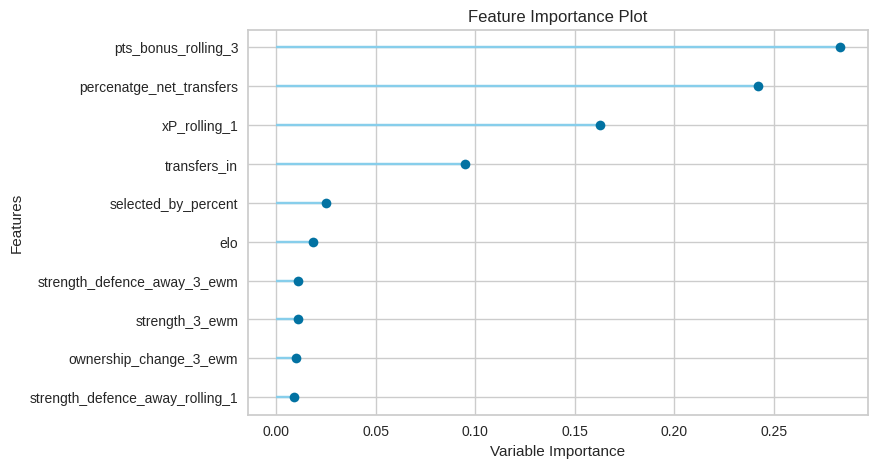

In [6]:
train_data, test_data, player_names, player_ids, test_mask = working_df(data, 11)
base_model = setup(train_data, target = 'xP',
                    train_size=0.8,
                    remove_multicollinearity=True,  # Drop collinear features
                    # feature_selection=True,        # Auto-select important features
                    session_id=42,
                    # use_gpu=True


                )
# models()

best_model_11 = base_model.compare_models(sort='MAE', n_select=1)
print(best_model_11)

evaluate_model(best_model_11)

plot_model(best_model_11, plot='feature')        # Feature importance


## GW 12


,Description,Value
0,Session id,42
1,Target,xP
2,Target type,Regression
3,Original data shape,"(1377, 346)"
4,Transformed data shape,"(1377, 130)"
5,Transformed train set shape,"(1101, 130)"
6,Transformed test set shape,"(276, 130)"
7,Numeric features,345
8,Preprocess,True
9,Imputation type,simple


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
lightgbm,Light Gradient Boosting Machine,0.7178,0.9079,0.9521,0.7476,0.2415,0.3537,1.5900
gbr,Gradient Boosting Regressor,0.7272,0.9617,0.9797,0.7321,0.2445,0.3638,1.0400
ridge,Ridge Regression,0.7424,0.9916,0.9945,0.7235,0.2500,0.3552,0.3180
et,Extra Trees Regressor,0.7448,0.9978,0.9977,0.7224,0.2538,0.3885,1.3210
rf,Random Forest Regressor,0.7616,1.0316,1.0143,0.7135,0.2575,0.3944,2.2300
xgboost,Extreme Gradient Boosting,0.7618,1.0247,1.0097,0.7166,0.2517,0.3632,0.9000
ada,AdaBoost Regressor,0.8650,1.2212,1.1038,0.6596,0.2917,0.5062,0.6730
lr,Linear Regression,0.8660,1.2788,1.1294,0.6467,0.3010,0.4340,0.3210
en,Elastic Net,0.9848,1.6069,1.2656,0.5502,0.3195,0.5142,0.3400
lasso,Lasso Regression,1.0440,1.7767,1.3310,0.5026,0.3346,0.5486,0.3000


LGBMRegressor(n_jobs=-1, random_state=42)


interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

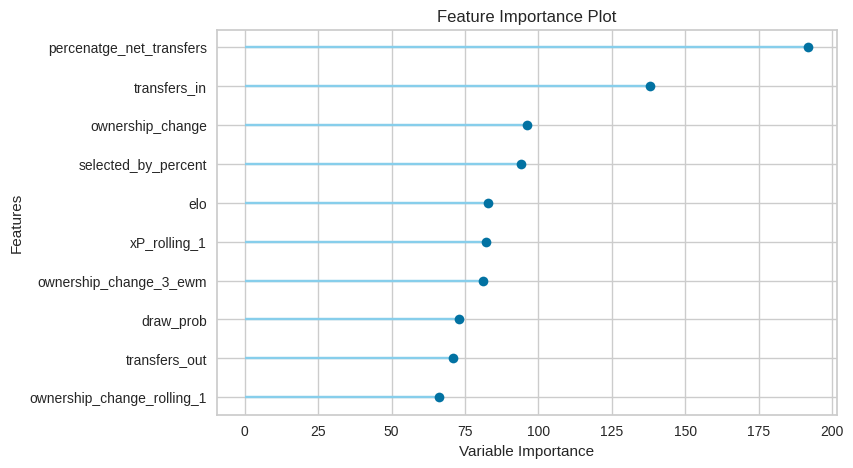

In [7]:
train_data, test_data, player_names, player_ids, test_mask = working_df(data, 12)
base_model_12 = setup(train_data, target = 'xP',
                    train_size=0.8,
                    remove_multicollinearity=True,  # Drop collinear features
                    # feature_selection=True,        # Auto-select important features
                    session_id=42,
                    # use_gpu=True


                )
# models()

best_model_12 = base_model_12.compare_models(sort='MAE', n_select=1)
print(best_model_12)

evaluate_model(best_model_12)

plot_model(best_model_12, plot='feature')        # Feature importance


## GW 13


,Description,Value
0,Session id,42
1,Target,xP
2,Target type,Regression
3,Original data shape,"(1597, 346)"
4,Transformed data shape,"(1597, 128)"
5,Transformed train set shape,"(1277, 128)"
6,Transformed test set shape,"(320, 128)"
7,Numeric features,345
8,Preprocess,True
9,Imputation type,simple


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
lightgbm,Light Gradient Boosting Machine,0.7448,1.0232,1.0081,0.7177,0.2500,0.3629,1.0550
gbr,Gradient Boosting Regressor,0.7587,1.0406,1.0172,0.7119,0.2530,0.3766,0.9620
xgboost,Extreme Gradient Boosting,0.7860,1.1467,1.0663,0.6759,0.2594,0.3782,0.7980
et,Extra Trees Regressor,0.7955,1.1441,1.0655,0.6832,0.2649,0.4036,1.2310
ridge,Ridge Regression,0.8060,1.1125,1.0534,0.6890,0.2674,0.3789,0.2830
rf,Random Forest Regressor,0.8165,1.1969,1.0899,0.6692,0.2693,0.4118,2.1610
lr,Linear Regression,0.8779,1.2952,1.1356,0.6341,0.2907,0.4199,0.2840
ada,AdaBoost Regressor,0.9733,1.4539,1.2040,0.5969,0.3160,0.5669,0.5150
en,Elastic Net,1.0267,1.7342,1.3131,0.5243,0.3293,0.5245,0.2810
lasso,Lasso Regression,1.0891,1.9117,1.3787,0.4772,0.3444,0.5601,0.2740


LGBMRegressor(n_jobs=-1, random_state=42)


interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

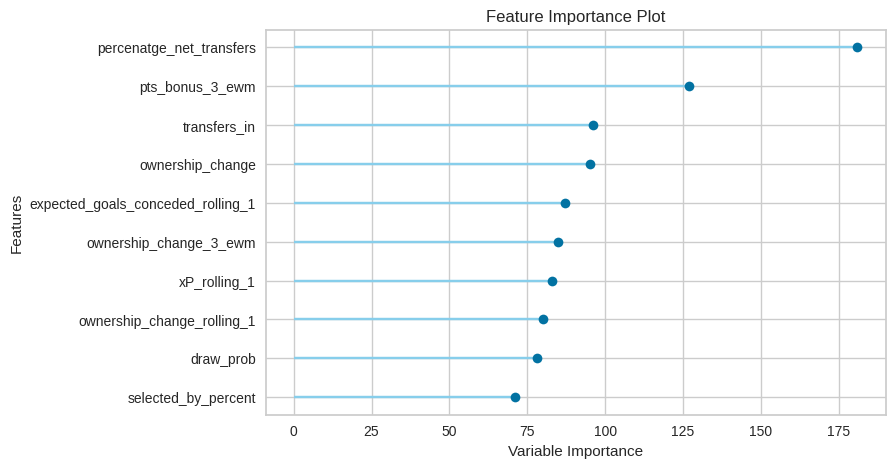

In [8]:
train_data, test_data, player_names, player_ids, test_mask = working_df(data, 13)
base_model_13 = setup(train_data, target = 'xP',
                    train_size=0.8,
                    remove_multicollinearity=True,  # Drop collinear features
                    # feature_selection=True,        # Auto-select important features
                    session_id=42,
                    # use_gpu=True


                )
# models()

best_model_13 = base_model_13.compare_models(sort='MAE', n_select=1)
print(best_model_13)

evaluate_model(best_model_13)

plot_model(best_model_13, plot='feature')        # Feature importance


## GW 14


,Description,Value
0,Session id,42
1,Target,xP
2,Target type,Regression
3,Original data shape,"(1811, 346)"
4,Transformed data shape,"(1811, 127)"
5,Transformed train set shape,"(1448, 127)"
6,Transformed test set shape,"(363, 127)"
7,Numeric features,345
8,Preprocess,True
9,Imputation type,simple


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
lightgbm,Light Gradient Boosting Machine,0.7213,0.9321,0.9617,0.7494,0.2383,0.3401,1.0820
gbr,Gradient Boosting Regressor,0.7405,0.9711,0.9806,0.7383,0.2462,0.3584,1.1280
ridge,Ridge Regression,0.7627,1.0096,1.0020,0.7254,0.2505,0.3530,0.3140
et,Extra Trees Regressor,0.7715,1.0759,1.0336,0.7101,0.2578,0.3871,1.3820
xgboost,Extreme Gradient Boosting,0.7778,1.0590,1.0247,0.7150,0.2546,0.3688,0.8400
rf,Random Forest Regressor,0.8066,1.1774,1.0813,0.6824,0.2675,0.4023,2.4920
lr,Linear Regression,0.8148,1.1387,1.0646,0.6900,0.2696,0.3818,0.2980
ada,AdaBoost Regressor,0.9224,1.3574,1.1623,0.6312,0.3022,0.5254,0.5590
en,Elastic Net,0.9858,1.6052,1.2638,0.5670,0.3179,0.5059,0.3140
lasso,Lasso Regression,1.0670,1.8303,1.3497,0.5067,0.3379,0.5505,0.2940


LGBMRegressor(n_jobs=-1, random_state=42)


interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

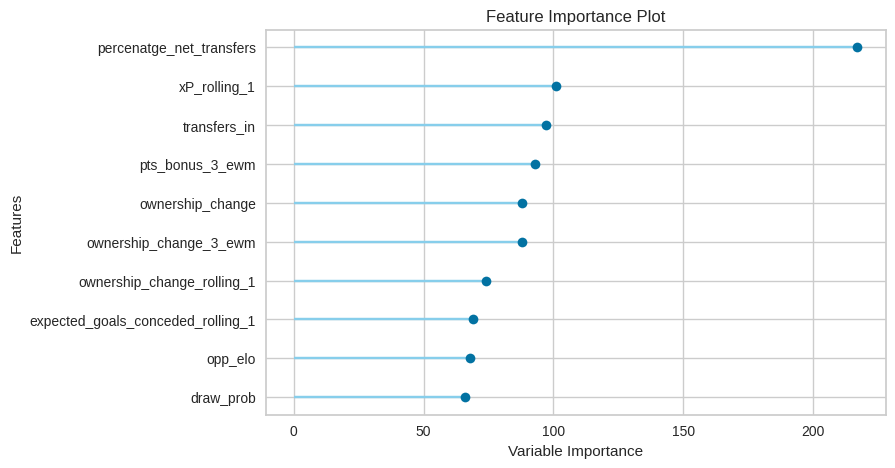

In [9]:
train_data, test_data, player_names, player_ids, test_mask = working_df(data, 14)
base_model_14 = setup(train_data, target = 'xP',
                    train_size=0.8,
                    remove_multicollinearity=True,  # Drop collinear features
                    # feature_selection=True,        # Auto-select important features
                    session_id=42,
                    # use_gpu=True


                )
# models()

best_model_14 = base_model_14.compare_models(sort='MAE', n_select=1)
print(best_model_14)

evaluate_model(best_model_14)

plot_model(best_model_14, plot='feature')        # Feature importance


## GW 15


,Description,Value
0,Session id,42
1,Target,xP
2,Target type,Regression
3,Original data shape,"(2047, 346)"
4,Transformed data shape,"(2047, 127)"
5,Transformed train set shape,"(1637, 127)"
6,Transformed test set shape,"(410, 127)"
7,Numeric features,345
8,Preprocess,True
9,Imputation type,simple


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
lightgbm,Light Gradient Boosting Machine,0.7109,0.9272,0.9612,0.7499,0.2371,0.3535,1.0990
gbr,Gradient Boosting Regressor,0.7384,0.9957,0.9961,0.7334,0.2469,0.3716,1.2140
ridge,Ridge Regression,0.7621,1.0196,1.0085,0.7262,0.2503,0.3666,0.3210
et,Extra Trees Regressor,0.7636,1.0562,1.0259,0.7175,0.2557,0.4004,1.5700
xgboost,Extreme Gradient Boosting,0.7700,1.0513,1.0233,0.7178,0.2489,0.3653,0.8770
rf,Random Forest Regressor,0.7891,1.1120,1.0521,0.7027,0.2617,0.4083,2.7890
lr,Linear Regression,0.8596,1.2656,1.1231,0.6607,0.2836,0.4129,0.3340
ada,AdaBoost Regressor,0.9280,1.3573,1.1631,0.6363,0.3077,0.5555,0.6190
en,Elastic Net,0.9856,1.6176,1.2701,0.5672,0.3176,0.5192,0.3260
lasso,Lasso Regression,1.0826,1.8980,1.3758,0.4921,0.3428,0.5733,0.3310


LGBMRegressor(n_jobs=-1, random_state=42)


interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

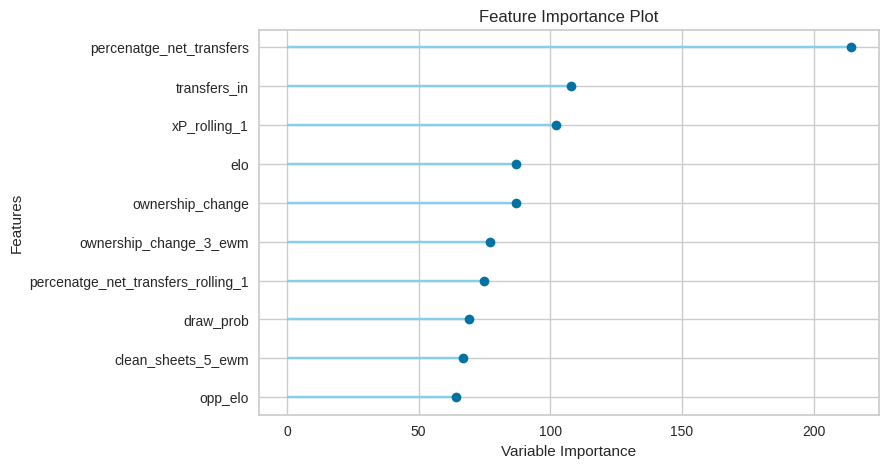

In [10]:
train_data, test_data, player_names, player_ids, test_mask = working_df(data, 15)
base_model_15 = setup(train_data, target = 'xP',
                    train_size=0.8,
                    remove_multicollinearity=True,  # Drop collinear features
                    # feature_selection=True,        # Auto-select important features
                    session_id=42,
                    # use_gpu=True


                )
# models()

best_model_15 = base_model_15.compare_models(sort='MAE', n_select=1)
print(best_model_15)

evaluate_model(best_model_15)

plot_model(best_model_15, plot='feature')        # Feature importance


## GW 16


,Description,Value
0,Session id,42
1,Target,xP
2,Target type,Regression
3,Original data shape,"(2277, 346)"
4,Transformed data shape,"(2277, 129)"
5,Transformed train set shape,"(1821, 129)"
6,Transformed test set shape,"(456, 129)"
7,Numeric features,345
8,Preprocess,True
9,Imputation type,simple


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
lightgbm,Light Gradient Boosting Machine,0.7191,0.9516,0.9705,0.7441,0.2310,0.3232,1.1420
gbr,Gradient Boosting Regressor,0.7375,0.9966,0.9939,0.7309,0.2391,0.3394,1.3650
ridge,Ridge Regression,0.7450,0.9822,0.9850,0.7320,0.2427,0.3319,0.3380
et,Extra Trees Regressor,0.7486,1.0180,1.0043,0.7256,0.2480,0.3617,1.7330
xgboost,Extreme Gradient Boosting,0.7572,1.0853,1.0359,0.7090,0.2499,0.3425,0.9020
rf,Random Forest Regressor,0.7826,1.0990,1.0426,0.7048,0.2561,0.3768,3.1570
lr,Linear Regression,0.8592,1.2747,1.1213,0.6533,0.2815,0.3885,0.3450
ada,AdaBoost Regressor,0.9120,1.3326,1.1512,0.6374,0.3017,0.5132,0.6800
en,Elastic Net,0.9680,1.5622,1.2441,0.5764,0.3102,0.4814,0.3470
lasso,Lasso Regression,1.0592,1.8323,1.3488,0.5019,0.3350,0.5303,0.3470


LGBMRegressor(n_jobs=-1, random_state=42)


interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

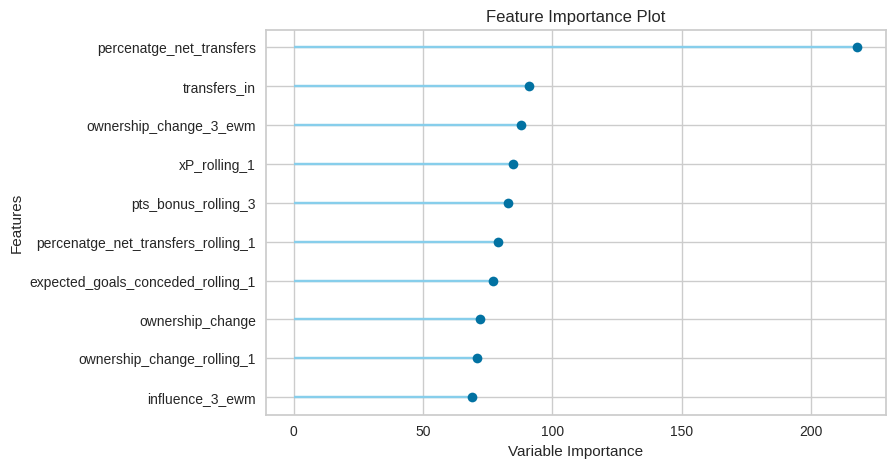

In [11]:
train_data, test_data, player_names, player_ids, test_mask = working_df(data, 16)
base_model_16 = setup(train_data, target = 'xP',
                    train_size=0.8,
                    remove_multicollinearity=True,  # Drop collinear features
                    # feature_selection=True,        # Auto-select important features
                    session_id=42,
                    # use_gpu=True


                )
# models()

best_model_16 = base_model_16.compare_models(sort='MAE', n_select=1)
print(best_model_16)

evaluate_model(best_model_16)

plot_model(best_model_16, plot='feature')        # Feature importance


## Feature Importance


In [12]:

def select_best_features(df, features):
    """
    Ranks features using LightGBM feature importance.
    Tree models naturally calculate which features reduce variance the most.
    """
    reliable_df = df[df['round'] >= 6].copy()

    X = reliable_df[features]
    y = reliable_df['xP']

    # Use default params for ranking
    model = LGBMRegressor(n_estimators=100, random_state=42, verbose=-1)
    model.fit(X, y)

    importances = pd.DataFrame({
        'Feature': features,
        'Importance': model.feature_importances_
    }).sort_values(by='Importance', ascending=False)

    # Add a 'Rank' column to match the previous structure
    importances['Rank'] = range(1, len(importances) + 1)
    return importances

def run_reliability_test(df, selected_features):
    """
    Simulates the season using only the selected features.
    """
    gws = sorted(df['round'].unique())
    results = []
    test_start_gw = 7
    scaler = StandardScaler()

    # Range of alpha values to test
    # alphas_to_test = [0.01, 0.1, 1.0, 10.0, 100.0]
    # Hyperparameters to tune: Learning Rate and Complexity (num_leaves)
    learning_rates = [0.01, 0.05, 0.1]
    num_leaves_list = [15, 31, 63]
    best_gw_mae = float('inf')
    # best_n = 1
    # best_alpha = 1.0
    best_learning_rate = 1.0
    best_num_leaves = 10

    best_gw_mae = float('inf')
    # best_n = 1
    best_lr = 0.1
    best_leaves = 31

    # 3. Grid Search: Feature Count x Learning Rate x Leaves
    search_limit = min(len(selected_features), 12)

    # for current_gw in range(test_start_gw, max(gws) + 1):
    train_df = df[df['round'] < round]
    test_df = df[df['round'] == round]

    X_train = scaler.fit_transform(train_df[selected_features])
    X_test = scaler.transform(test_df[selected_features])

    # model = Ridge(alpha=1.0)
    # model.fit(X_train, train_df['xP'])

    for lr in learning_rates:
        for leaves in num_leaves_list:
            val_model = LGBMRegressor(
                learning_rate=lr,
                num_leaves=leaves,
                n_estimators=100,
                random_state=42,
                verbose=-1
            )
        # val_model = Ridge(alpha=a, random_state=42)
            val_model.fit(X_train, train_df['xP'])
            v_mae = mean_absolute_error(test_df['xP'], val_model.predict(X_test))

            if v_mae < best_gw_mae:
                best_gw_mae = v_mae
                # best_n = n
                best_lr = lr
                best_leaves = leaves

    results.append({'GW': round, 'MAE': best_gw_mae, 'lr': best_lr, 'leaves': best_leaves})

    return pd.DataFrame(results)

def get_gw_best_features(data, round):
    print(f"Step 1: Ranking Features for GW {round} using Recursive Feature Elimination...")

    feature_ranks = select_best_features(data[data['round'] < round],  feature_cols)

    # # Step 2: Automated Selection
    print(f"\nStep 2: Finding Optimal Feature Cut-off. of the {len(feature_cols)} features..")

    # We iterate through the top N features to find where MAE stops improving
    best_overall_mae = float('inf')
    best_overall_lr = 1
    best_overall_leaves = 31
    optimal_count = 1

    # Testing up to top 10 (or however many you want to check)
    search_limit = min(len(feature_cols), 50)

    for i in range(1, search_limit + 1):
        trial_features = feature_ranks.head(i)['Feature'].tolist()
        reliability_df = run_reliability_test(data[data['round']<= round], trial_features)


        avg_mae = reliability_df['MAE'].mean()
        avg_lr = reliability_df['lr'].mean()
        avg_leaves = reliability_df['leaves'].mean()


        print(f"Testing top {i} features: Average MAE = {avg_mae:.4f}")

        if avg_mae < best_overall_mae:
            best_overall_mae = avg_mae
            best_overall_lr = avg_lr
            best_overall_leaves = avg_leaves
            optimal_count = i

    # Final Prediction for the actual Deadline
    train_df = data[data['round'] < round]
    test_df = data[data['round'] == round]

    chosen_features = feature_ranks.head(optimal_count)['Feature'].tolist()

    final_model = LGBMRegressor(
        learning_rate=best_overall_lr,
        num_leaves=np.int64(best_overall_leaves),
        n_estimators=100,
        random_state=42,
        verbose=-1
    )

    print(best_overall_leaves, best_overall_lr)
    final_model.fit(train_df[chosen_features], train_df['xP'])
    pred_xP = final_model.predict(test_df[chosen_features])
    actual_mae = mean_absolute_error(test_df['xP'], pred_xP)

    print(f"GW {round}: Used {len(chosen_features)} features. MAE: {actual_mae:.4f}")
    print(f"\nOptimal number of features: {optimal_count}")
    print(f"Selected Features: {round}==> {chosen_features}")

    return chosen_features, optimal_count, actual_mae, best_overall_lr, best_overall_leaves, pred_xP


In [13]:
feature_ranks = select_best_features(data[data['round'] < 16],  feature_cols)
feature_ranks

,Feature,Importance,Rank
6,percenatge_net_transfers,183,1
38,xP_rolling_1,68,2
168,pts_bonus_3_ewm,64,3
2,transfers_in,59,4
5,ownership_change,59,5
...,...,...,...
242,ownership_change_1_ewm,0,336
239,transfers_out_1_ewm,0,337
236,transfers_in_1_ewm,0,338
233,selected_1_ewm,0,339


In [14]:
selected_features = {}
for round in range(8,24):
    selected_features[round] = get_gw_best_features(data, round)


Step 1: Ranking Features for GW 8 using Recursive Feature Elimination...

Step 2: Finding Optimal Feature Cut-off. of the 340 features..
Testing top 1 features: Average MAE = 1.1678
Testing top 2 features: Average MAE = 1.0909
Testing top 3 features: Average MAE = 0.9714
Testing top 4 features: Average MAE = 0.9551
Testing top 5 features: Average MAE = 0.9210
Testing top 6 features: Average MAE = 0.8913
Testing top 7 features: Average MAE = 0.9262
Testing top 8 features: Average MAE = 0.9321
Testing top 9 features: Average MAE = 0.9108
Testing top 10 features: Average MAE = 0.8835
Testing top 11 features: Average MAE = 0.8820
Testing top 12 features: Average MAE = 0.8794
Testing top 13 features: Average MAE = 0.9033
Testing top 14 features: Average MAE = 0.8876
Testing top 15 features: Average MAE = 0.8789
Testing top 16 features: Average MAE = 0.8593
Testing top 17 features: Average MAE = 0.8689
Testing top 18 features: Average MAE = 0.8850
Testing top 19 features: Average MAE = 0.883

In [15]:
selections = pd.DataFrame(selected_features).T
selections.columns = ['best_features', 'optimal_count', 'best_overall_mae', 'best_lr', 'best_leaves', 'xP_predictions']
selections

,best_features,optimal_count,best_overall_mae,best_lr,best_leaves,xP_predictions
8,"[percenatge_net_transfers, transfers_in, pts_b...",32,0.844301,0.1,31.0,"[5.1329526965107855, 8.606485607284363, 3.4163..."
9,"[percenatge_net_transfers, transfers_in, owner...",47,0.739452,0.1,15.0,"[4.88734454365884, 7.496543099664686, 5.633936..."
10,"[percenatge_net_transfers, transfers_in, owner...",49,0.751067,0.1,15.0,"[6.350196154947295, 9.637316911515315, 3.52376..."
11,"[percenatge_net_transfers, transfers_in, owner...",33,0.851061,0.05,31.0,"[6.572186370895644, 5.265406325201024, 5.54999..."
12,"[percenatge_net_transfers, transfers_in, owner...",12,0.979615,0.1,63.0,"[3.9541673158377924, 4.189441799587704, 4.0111..."
13,"[percenatge_net_transfers, ownership_change, p...",34,0.798859,0.1,15.0,"[3.8681599121310106, 3.8855897204764642, 6.542..."
14,"[percenatge_net_transfers, transfers_in, xP_ro...",43,0.667274,0.05,15.0,"[4.259629549113868, 3.2188442907942236, 4.8652..."
15,"[percenatge_net_transfers, transfers_in, owner...",33,0.665388,0.05,15.0,"[5.670751675201662, 2.716704038567192, 6.94014..."
16,"[percenatge_net_transfers, xP_rolling_1, pts_b...",47,0.700192,0.05,15.0,"[4.3112613694699675, 3.369630414418875, 2.0716..."
17,"[percenatge_net_transfers, xP_rolling_1, pts_b...",10,0.658128,0.05,15.0,"[4.01495485085629, 3.2003225742300265, 3.06265..."


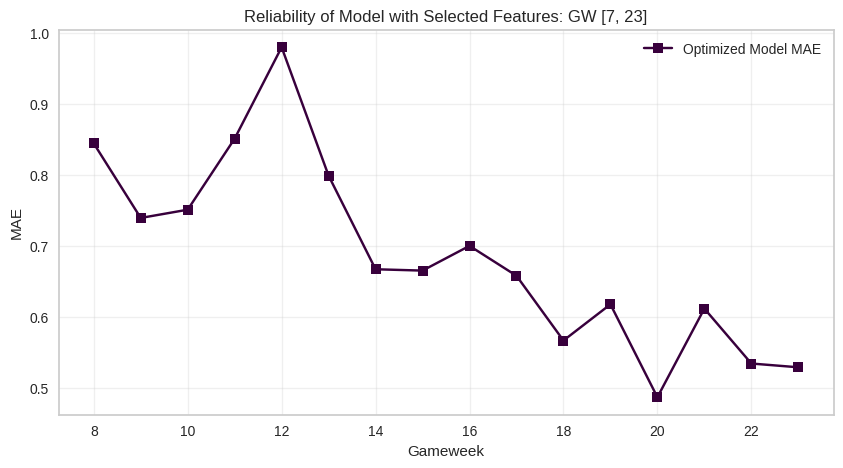

In [16]:

# --- Visualization ---
plt.figure(figsize=(10, 5))
plt.plot(selections.index, selections['best_overall_mae'], marker='s', color="#38003c", label='Optimized Model MAE')
plt.title('Reliability of Model with Selected Features: GW [7, 23]', fontsize=12)
plt.xlabel('Gameweek')
plt.ylabel('MAE')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


### AffinePNN


#### Preds


Data prepared. X shape: (4000, 31), M shape: (4000, 9), Y shape: (4000, 2)

Starting Training...
Epoch 1/100


2026-02-25 23:04:09.930611: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected
2026-02-25 23:04:10.114328: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_16}}


12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - loss: 0.7089 - mae: 0.4271 - mse: 0.2066 - val_loss: 0.7213 - val_mae: 0.4502 - val_mse: 0.2213 - learning_rate: 1.0000e-04
Epoch 2/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.6837 - mae: 0.4000 - mse: 0.1855 - val_loss: 0.6993 - val_mae: 0.4302 - val_mse: 0.2033 - learning_rate: 1.0000e-04
Epoch 3/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.6558 - mae: 0.3671 - mse: 0.1617 - val_loss: 0.6776 - val_mae: 0.4097 - val_mse: 0.1858 - learning_rate: 1.0000e-04
Epoch 4/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.6309 - mae: 0.3382 - mse: 0.1409 - val_loss: 0.6566 - val_mae: 0.3887 - val_mse: 0.1689 - learning_rate: 1.0000e-04
Epoch 5/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.6081 - mae: 0.3104 - mse: 0.1223 - val_loss: 0.6358 - val_mae: 0.3669 - val_mse: 0.1522 - learning_rate: 1.0000e-04
Epoch 6/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.5890 - mae: 0.2873 - mse: 0.1073 - val_loss: 0.6157 - val_mae: 0

2026-02-25 23:04:24.083909: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_16}}


8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step

Generating Predictions...
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
{'fpl_name': array(['Raya', 'Gabriel', 'Saliba', 'Calafiori', 'J.Timber', 'Zinchenko',
       'Saka', 'Trossard', 'Rice', 'Merino', 'Zubimendi', 'Martinez',
       'Cash', 'Digne', 'Konsa', 'Pau', 'Rogers', 'Buendía', 'Malen',
       'McGinn', 'Kamara', 'Watkins', 'Petrović', 'Senesi', 'Truffert',
       'Kluivert', 'Semenyo', 'O.Dango', 'Tavernier', 'Adams', 'Christie',
       'Scott', 'Kelleher', 'Collins', 'Ajer', 'Kayode', 'Van den Berg',
       'Mbeumo', 'Schade', 'Damsgaard', 'Henderson', 'Yarmoliuk',
       'Thiago', 'Verbruggen', 'Dunk', 'F.Kadıoğlu', 'Van Hecke',
       'Georginio', 'Minteh', 'Ayari', 'Baleba', 'Gomez', 'Wieffer',
       'Welbeck', 'Walker', 'Estève', 'Hartman', 'Tuanzebe', 'Anthony',
       'Bruun Larsen', 'Cullen', 'Tchaouna', 'Sánchez', 'Cucurella',
       'James', 'Chalobah', 'Acheampong', 'Neto', 'Caicedo',
       'Dewsbury-Hall', 'Lavia', 'Andrey Santos

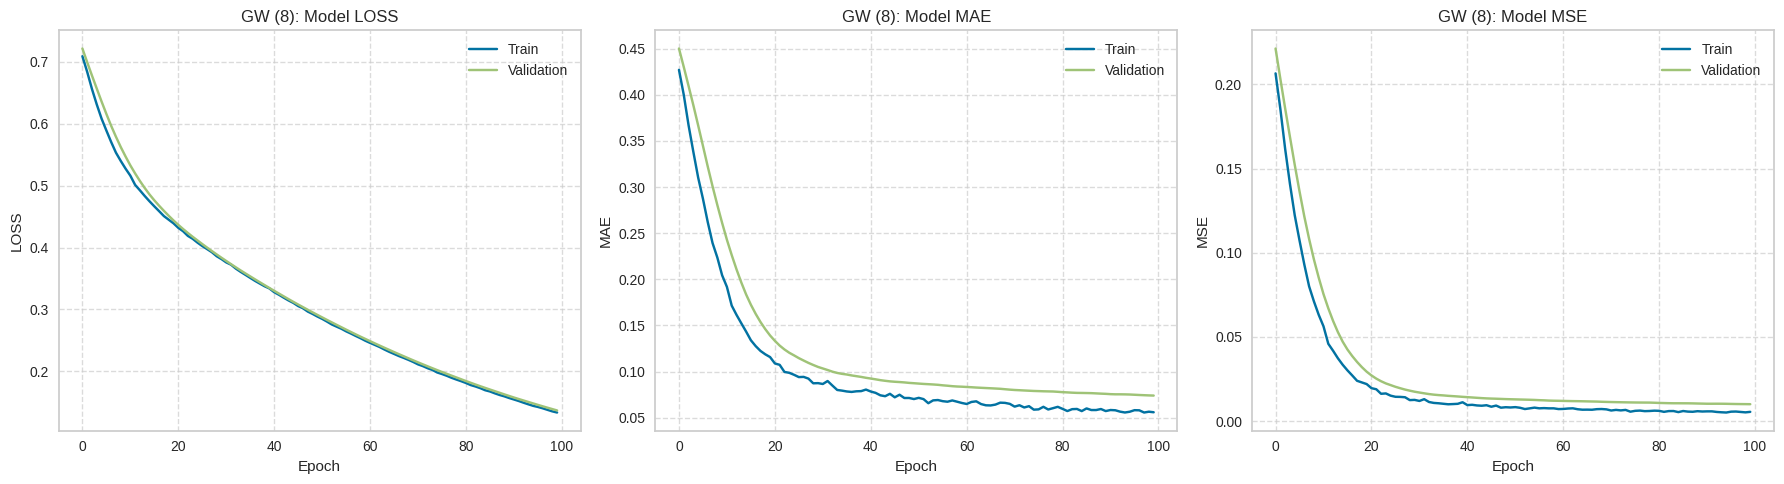

Data prepared. X shape: (4000, 45), M shape: (4000, 9), Y shape: (4000, 2)

Starting Training...
Epoch 1/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 0.6048 - mae: 0.2672 - mse: 0.1009 - val_loss: 0.6263 - val_mae: 0.3107 - val_mse: 0.1262 - learning_rate: 1.0000e-04
Epoch 2/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.5732 - mae: 0.2262 - mse: 0.0761 - val_loss: 0.5974 - val_mae: 0.2798 - val_mse: 0.1042 - learning_rate: 1.0000e-04
Epoch 3/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.5476 - mae: 0.1957 - mse: 0.0575 - val_loss: 0.5702 - val_mae: 0.2495 - val_mse: 0.0841 - learning_rate: 1.0000e-04
Epoch 4/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.5279 - mae: 0.1721 - mse: 0.0451 - val_loss: 0.5457 - val_mae: 0.2213 - val_mse: 0.0669 - learning_rate: 1.0000e-04
Epoch 5/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.5114 - mae: 0.1543 - mse: 0.0361 - val_loss: 0.5242 - val_mae: 0.1962 - val_mse: 0.0530 - learning_rate: 1.0000e-04
Epoch 6/100
18/18

2026-02-25 23:04:40.789628: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_16}}


8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step

Generating Predictions...
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
{'fpl_name': array(['Raya', 'Gabriel', 'Saliba', 'Calafiori', 'J.Timber', 'Saka',
       'Trossard', 'Rice', 'Zubimendi', 'Martinez', 'Cash', 'Digne',
       'Konsa', 'Pau', 'Rogers', 'Buendía', 'McGinn', 'Kamara', 'Onana',
       'Watkins', 'Petrović', 'Senesi', 'Truffert', 'Kluivert', 'Semenyo',
       'O.Dango', 'Tavernier', 'Adams', 'Brooks', 'Scott', 'Kroupi.Jr',
       'Kelleher', 'Collins', 'Ajer', 'Kayode', 'Van den Berg', 'Mbeumo',
       'Schade', 'Damsgaard', 'Henderson', 'Yarmoliuk', 'Thiago',
       'Verbruggen', 'De Cuyper', 'Dunk', 'F.Kadıoğlu', 'Van Hecke',
       'Georginio', 'Minteh', 'Ayari', 'Baleba', 'Gomez', 'Wieffer',
       'Welbeck', 'Walker', 'Estève', 'Hartman', 'Tuanzebe', 'Anthony',
       'Bruun Larsen', 'Cullen', 'Laurent', 'Flemming', 'Sánchez',
       'Cucurella', 'James', 'Chalobah', 'Acheampong', 'Neto', 'Enzo',
       'Estêvão', 'Caicedo', 'Dewsbury

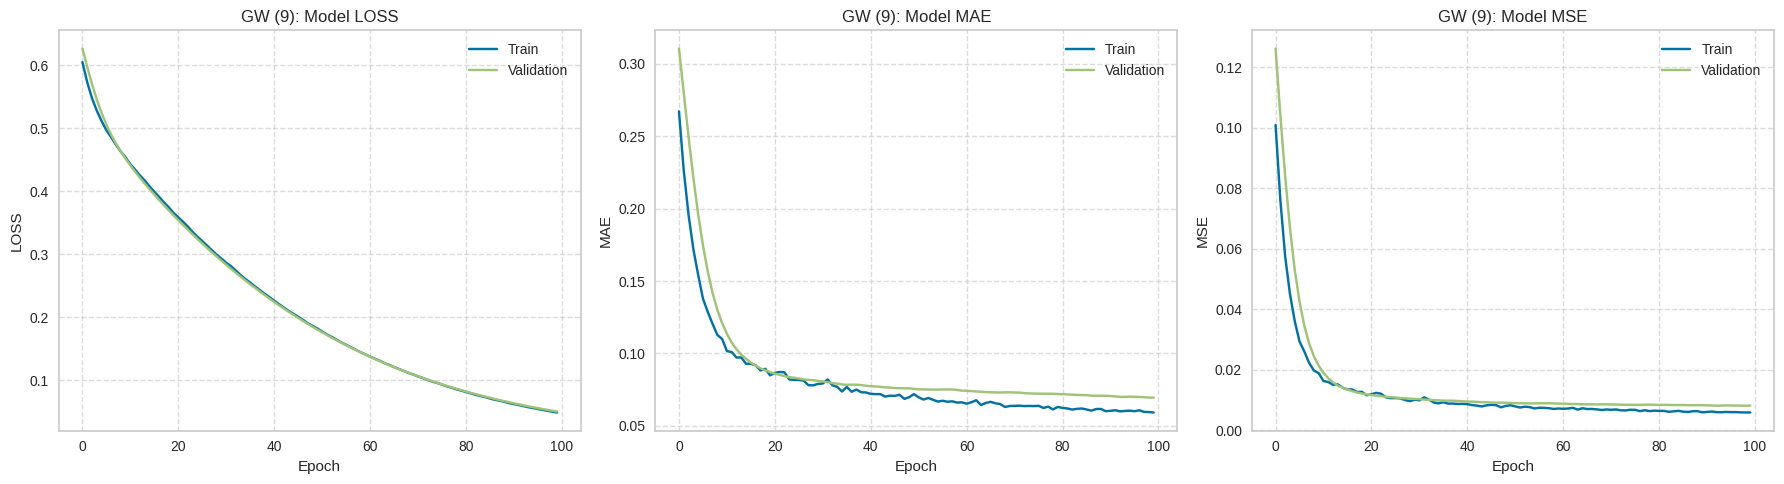

Data prepared. X shape: (4000, 48), M shape: (4000, 9), Y shape: (4000, 2)

Starting Training...
Epoch 1/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 0.5725 - mae: 0.1844 - mse: 0.0531 - val_loss: 0.5782 - val_mae: 0.2138 - val_mse: 0.0646 - learning_rate: 1.0000e-04
Epoch 2/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.5456 - mae: 0.1511 - mse: 0.0373 - val_loss: 0.5498 - val_mae: 0.1834 - val_mse: 0.0476 - learning_rate: 1.0000e-04
Epoch 3/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.5228 - mae: 0.1250 - mse: 0.0262 - val_loss: 0.5261 - val_mae: 0.1588 - val_mse: 0.0358 - learning_rate: 1.0000e-04
Epoch 4/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.5068 - mae: 0.1157 - mse: 0.0224 - val_loss: 0.5057 - val_mae: 0.1394 - val_mse: 0.0278 - learning_rate: 1.0000e-04
Epoch 5/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.4913 - mae: 0.1065 - mse: 0.0194 - val_loss: 0.4877 - val_mae: 0.1242 - val_mse: 0.0223 - learning_rate: 1.0000e-04
Epoch 6/100
23/23

2026-02-25 23:04:59.345990: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_16}}


8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step

Generating Predictions...
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
{'fpl_name': array(['Raya', 'Gabriel', 'Saliba', 'Calafiori', 'J.Timber', 'Saka',
       'Trossard', 'Rice', 'Merino', 'Zubimendi', 'Martinez', 'Cash',
       'Digne', 'Konsa', 'Pau', 'Rogers', 'Malen', 'McGinn', 'Kamara',
       'Onana', 'Watkins', 'Petrović', 'Senesi', 'Truffert', 'Kluivert',
       'Semenyo', 'O.Dango', 'Tavernier', 'Adams', 'Brooks', 'Scott',
       'Evanilson', 'Kroupi.Jr', 'Kelleher', 'Collins', 'Ajer', 'Kayode',
       'Van den Berg', 'Mbeumo', 'Schade', 'Damsgaard', 'Henderson',
       'Janelt', 'Yarmoliuk', 'Thiago', 'Verbruggen', 'Dunk',
       'F.Kadıoğlu', 'Van Hecke', 'Georginio', 'Minteh', 'Ayari',
       'Baleba', 'Gomez', 'Wieffer', 'Welbeck', 'Walker', 'Estève',
       'Hartman', 'Tuanzebe', 'Anthony', 'Bruun Larsen', 'Cullen',
       'Laurent', 'Tchaouna', 'Flemming', 'Sánchez', 'Cucurella', 'James',
       'Chalobah', 'Gusto', 'Neto', 'Enzo', 'Gitte

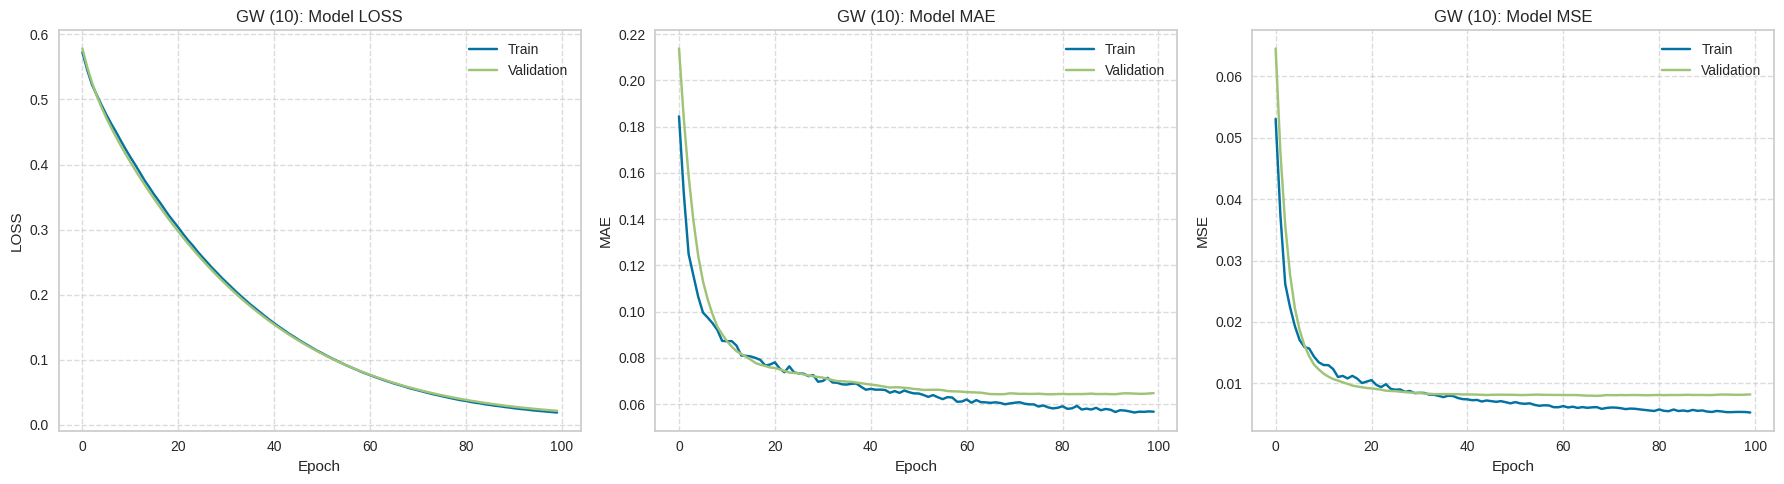

Data prepared. X shape: (4000, 32), M shape: (4000, 9), Y shape: (4000, 2)

Starting Training...
Epoch 1/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - loss: 0.6131 - mae: 0.2769 - mse: 0.1119 - val_loss: 0.6359 - val_mae: 0.3214 - val_mse: 0.1400 - learning_rate: 1.0000e-04
Epoch 2/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.5646 - mae: 0.2149 - mse: 0.0736 - val_loss: 0.5901 - val_mae: 0.2729 - val_mse: 0.1046 - learning_rate: 1.0000e-04
Epoch 3/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.5301 - mae: 0.1724 - mse: 0.0499 - val_loss: 0.5487 - val_mae: 0.2266 - val_mse: 0.0744 - learning_rate: 1.0000e-04
Epoch 4/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.5039 - mae: 0.1404 - mse: 0.0353 - val_loss: 0.5147 - val_mae: 0.1879 - val_mse: 0.0522 - learning_rate: 1.0000e-04
Epoch 5/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.4841 - mae: 0.1253 - mse: 0.0274 - val_loss: 0.4869 - val_mae: 0.1571 - val_mse: 0.0366 - learning_rate: 1.0000e-04
Epoch 6/100
29/29

2026-02-25 23:05:20.334922: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_16}}


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step

Generating Predictions...
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
{'fpl_name': array(['Raya', 'Saliba', 'Calafiori', 'J.Timber', 'Saka', 'Trossard',
       'Rice', 'Merino', 'Zubimendi', 'Martinez', 'Cash', 'Digne',
       'Konsa', 'Pau', 'Rogers', 'Buendía', 'J.Ramsey', 'McGinn',
       'Barkley', 'Kamara', 'Onana', 'Watkins', 'Petrović', 'Senesi',
       'Truffert', 'Semenyo', 'O.Dango', 'Tavernier', 'Adams', 'Christie',
       'Scott', 'Kroupi.Jr', 'Kelleher', 'Collins', 'Kayode',
       'Van den Berg', 'Mbeumo', 'Schade', 'Damsgaard', 'Henderson',
       'Yarmoliuk', 'Thiago', 'Verbruggen', 'Dunk', 'F.Kadıoğlu',
       'Van Hecke', 'Georginio', 'Minteh', 'Ayari', 'Baleba', 'Gomez',
       'Wieffer', 'Welbeck', 'Walker', 'Estève', 'Hartman', 'Tuanzebe',
       'Anthony', 'Bruun Larsen', 'Cullen', 'Tchaouna', 'Flemming',
       'Sánchez', 'Cucurella', 'Chalobah', 'Gusto', 'Fofana', 'Neto',
       'Enzo', 'Estêvão', 'Caicedo', 'Dewsbury-Hall', 'Joã

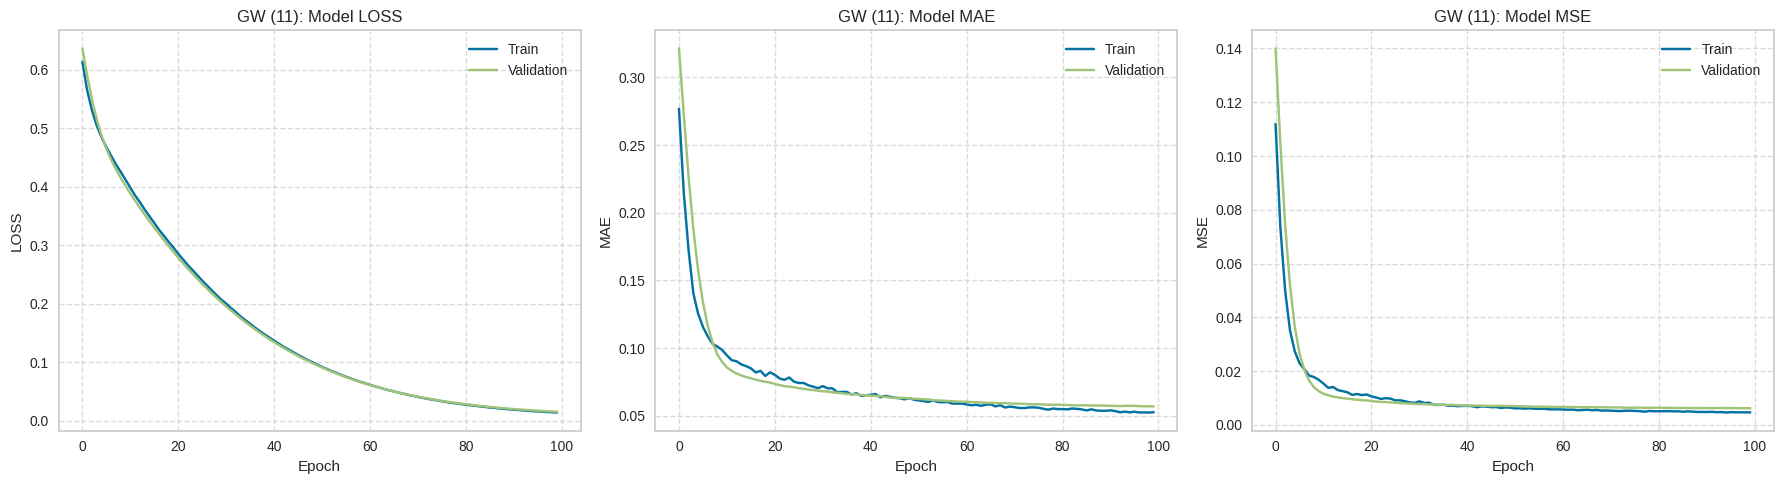

Data prepared. X shape: (4000, 11), M shape: (4000, 9), Y shape: (4000, 2)

Starting Training...
Epoch 1/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.5477 - mae: 0.2342 - mse: 0.0795 - val_loss: 0.5322 - val_mae: 0.2201 - val_mse: 0.0707 - learning_rate: 1.0000e-04
Epoch 2/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.5007 - mae: 0.1728 - mse: 0.0456 - val_loss: 0.4989 - val_mae: 0.1881 - val_mse: 0.0510 - learning_rate: 1.0000e-04
Epoch 3/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.4703 - mae: 0.1371 - mse: 0.0295 - val_loss: 0.4708 - val_mae: 0.1619 - val_mse: 0.0378 - learning_rate: 1.0000e-04
Epoch 4/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.4477 - mae: 0.1166 - mse: 0.0221 - val_loss: 0.4468 - val_mae: 0.1425 - val_mse: 0.0292 - learning_rate: 1.0000e-04
Epoch 5/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.4277 - mae: 0.1037 - mse: 0.0177 - val_loss: 0.4253 - val_mae: 0.1273 - val_mse: 0.0234 - learning_rate: 1.0000e-04
Epoch 6/100
35/35

2026-02-25 23:05:42.069915: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_16}}


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step

Generating Predictions...
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
{'fpl_name': array(['Raya', 'Saliba', 'Calafiori', 'J.Timber', 'Saka', 'Trossard',
       'Rice', 'Merino', 'Zubimendi', 'Martinez', 'Cash', 'Digne',
       'Konsa', 'Pau', 'Rogers', 'Buendía', 'McGinn', 'Barkley', 'Kamara',
       'Watkins', 'Petrović', 'Senesi', 'Truffert', 'O.Dango',
       'Tavernier', 'Adams', 'Brooks', 'Cook', 'Scott', 'Evanilson',
       'Kroupi.Jr', 'Kelleher', 'Collins', 'Ajer', 'Kayode',
       'Van den Berg', 'Mbeumo', 'Schade', 'Damsgaard', 'Henderson',
       'Yarmoliuk', 'Thiago', 'Verbruggen', 'De Cuyper', 'Dunk',
       'F.Kadıoğlu', 'Van Hecke', 'Georginio', 'Minteh', 'Ayari',
       'Baleba', 'Gomez', 'Wieffer', 'Welbeck', 'Walker', 'Estève',
       'Hartman', 'Tuanzebe', 'Anthony', 'Cullen', 'Tchaouna', 'Flemming',
       'Sánchez', 'Cucurella', 'James', 'Chalobah', 'Gusto', 'Neto',
       'Enzo', 'Dewsbury-Hall', 'João Pedro', 'Delap', 'Henderson',

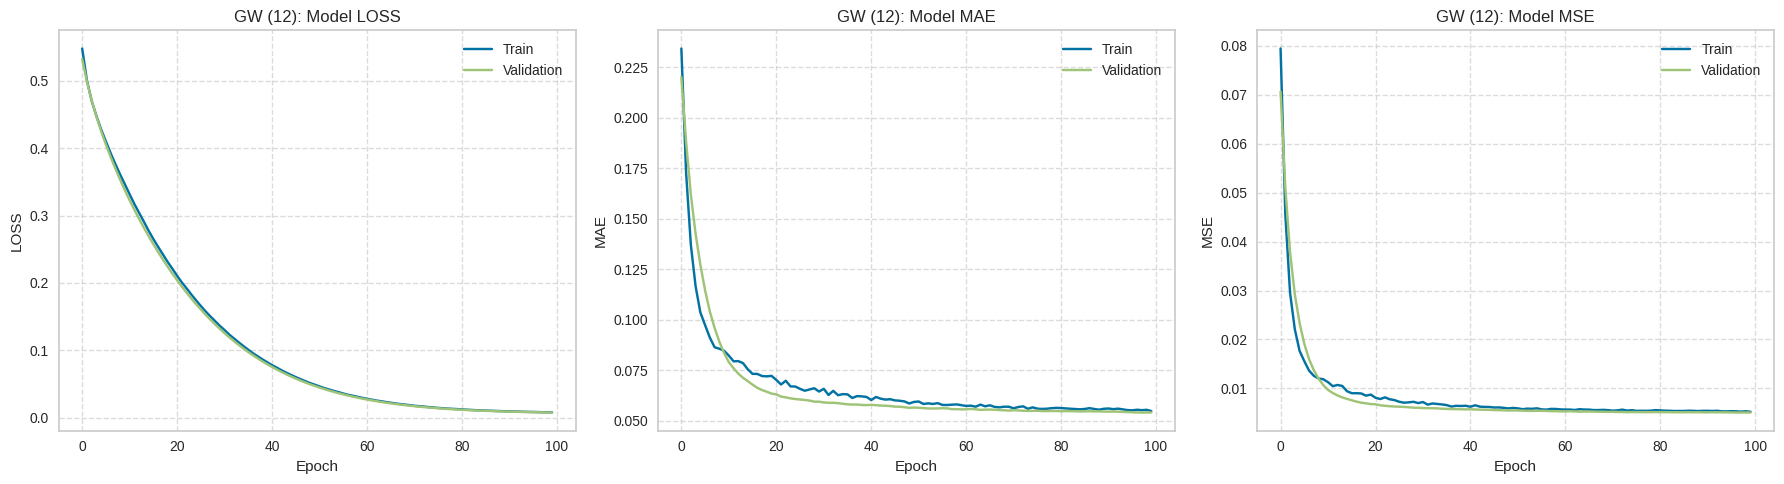

Data prepared. X shape: (4000, 33), M shape: (4000, 9), Y shape: (4000, 2)

Starting Training...
Epoch 1/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.7969 - mae: 0.4991 - mse: 0.2842 - val_loss: 0.7727 - val_mae: 0.4951 - val_mse: 0.2678 - learning_rate: 1.0000e-04
Epoch 2/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.7017 - mae: 0.4081 - mse: 0.2038 - val_loss: 0.7064 - val_mae: 0.4380 - val_mse: 0.2157 - learning_rate: 1.0000e-04
Epoch 3/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.6205 - mae: 0.3225 - mse: 0.1366 - val_loss: 0.6320 - val_mae: 0.3646 - val_mse: 0.1553 - learning_rate: 1.0000e-04
Epoch 4/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.5552 - mae: 0.2447 - mse: 0.0855 - val_loss: 0.5648 - val_mae: 0.2890 - val_mse: 0.1026 - learning_rate: 1.0000e-04
Epoch 5/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.5100 - mae: 0.1899 - mse: 0.0550 - val_loss: 0.5120 - val_mae: 0.2232 - val_mse: 0.0646 - learning_rate: 1.0000e-04
Epoch 6/100
40/40 

2026-02-25 23:06:04.684614: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_16}}


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step

Generating Predictions...
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
{'fpl_name': array(['Raya', 'Calafiori', 'J.Timber', 'Saka', 'Rice', 'Merino',
       'Zubimendi', 'Martinez', 'Cash', 'Digne', 'Konsa', 'Pau', 'Rogers',
       'Tielemans', 'Buendía', 'J.Ramsey', 'Malen', 'McGinn', 'Kamara',
       'Watkins', 'Petrović', 'Truffert', 'Semenyo', 'O.Dango',
       'Tavernier', 'Adams', 'Scott', 'Evanilson', 'Kelleher', 'Collins',
       'Kayode', 'Van den Berg', 'Hickey', 'Mbeumo', 'Schade',
       'Damsgaard', 'Henderson', 'Thiago', 'Verbruggen', 'De Cuyper',
       'Dunk', 'F.Kadıoğlu', 'Van Hecke', 'Georginio', 'Minteh', 'Ayari',
       'Gomez', 'Wieffer', 'Welbeck', 'Walker', 'Estève', 'Hartman',
       'Tuanzebe', 'Cullen', 'Hannibal', 'Tchaouna', 'Flemming',
       'Sánchez', 'Cucurella', 'James', 'Chalobah', 'Gusto', 'Fofana',
       'Neto', 'Enzo', 'Dewsbury-Hall', 'João Pedro', 'Delap',
       'Henderson', 'Muñoz', 'Lacroix', 'Mitchell', 'Guéhi

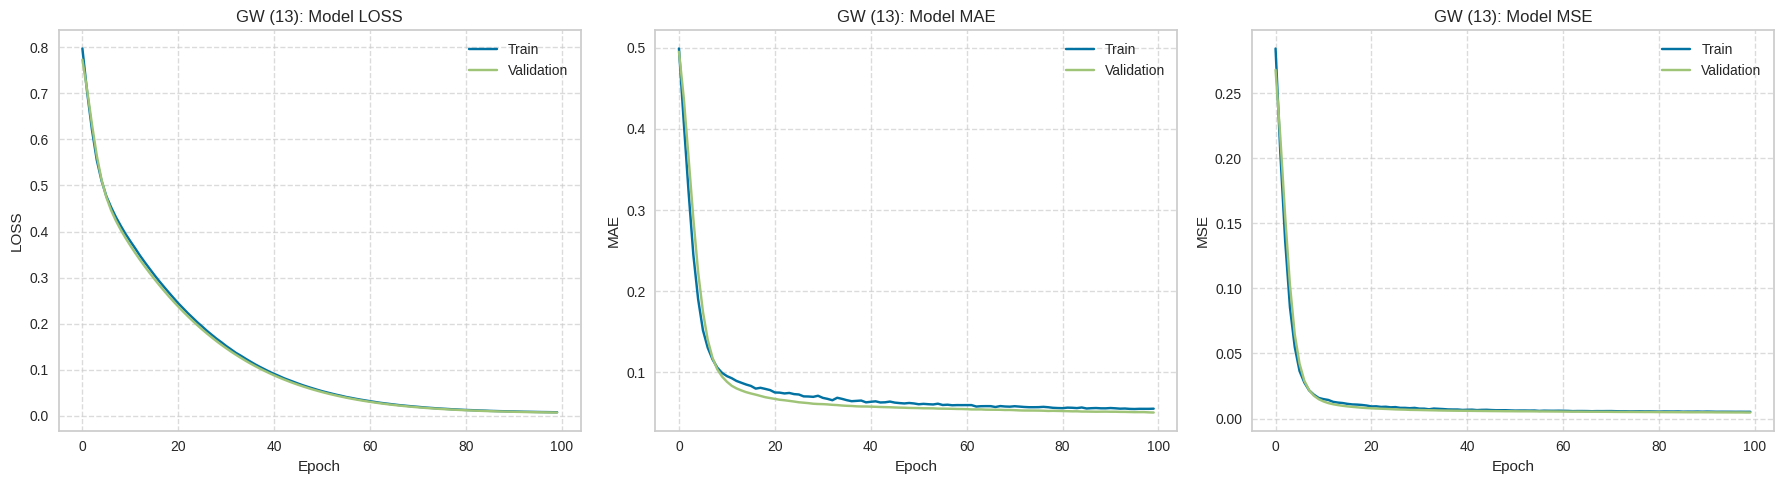

Data prepared. X shape: (4000, 41), M shape: (4000, 9), Y shape: (4000, 2)

Starting Training...
Epoch 1/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.5738 - mae: 0.1770 - mse: 0.0501 - val_loss: 0.5517 - val_mae: 0.1657 - val_mse: 0.0406 - learning_rate: 1.0000e-04
Epoch 2/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.5304 - mae: 0.1381 - mse: 0.0314 - val_loss: 0.5119 - val_mae: 0.1309 - val_mse: 0.0258 - learning_rate: 1.0000e-04
Epoch 3/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.4969 - mae: 0.1186 - mse: 0.0228 - val_loss: 0.4792 - val_mae: 0.1088 - val_mse: 0.0180 - learning_rate: 1.0000e-04
Epoch 4/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.4680 - mae: 0.1069 - mse: 0.0187 - val_loss: 0.4507 - val_mae: 0.0953 - val_mse: 0.0141 - learning_rate: 1.0000e-04
Epoch 5/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.4409 - mae: 0.0986 - mse: 0.0158 - val_loss: 0.4246 - val_mae: 0.0866 - val_mse: 0.0118 - learning_rate: 1.0000e-04
Epoch 6/100
46/46 

2026-02-25 23:06:29.963011: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_16}}


8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step

Generating Predictions...
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
{'fpl_name': array(['Raya', 'Calafiori', 'J.Timber', 'Saka', 'Martinelli', 'Rice',
       'Merino', 'Zubimendi', 'Cash', 'Digne', 'Konsa', 'Pau', 'Rogers',
       'Tielemans', 'McGinn', 'Kamara', 'Onana', 'Watkins', 'Petrović',
       'Truffert', 'Semenyo', 'O.Dango', 'Tavernier', 'Scott',
       'Evanilson', 'Kroupi.Jr', 'Kelleher', 'Collins', 'Ajer', 'Kayode',
       'Van den Berg', 'Mbeumo', 'Schade', 'Damsgaard', 'Henderson',
       'Jensen', 'Yarmoliuk', 'Thiago', 'Verbruggen', 'De Cuyper', 'Dunk',
       'F.Kadıoğlu', 'Van Hecke', 'Minteh', 'Hinshelwood', 'Baleba',
       'Gomez', 'Wieffer', 'Welbeck', 'Walker', 'Estève', 'Hartman',
       'Anthony', 'Bruun Larsen', 'Cullen', 'Tchaouna', 'Flemming',
       'Foster', 'Sánchez', 'Cucurella', 'Chalobah', 'Gusto', 'Tosin',
       'Neto', 'Enzo', 'Estêvão', 'Gittens', 'Dewsbury-Hall',
       'Andrey Santos', 'João Pedro', 'Delap', 'H

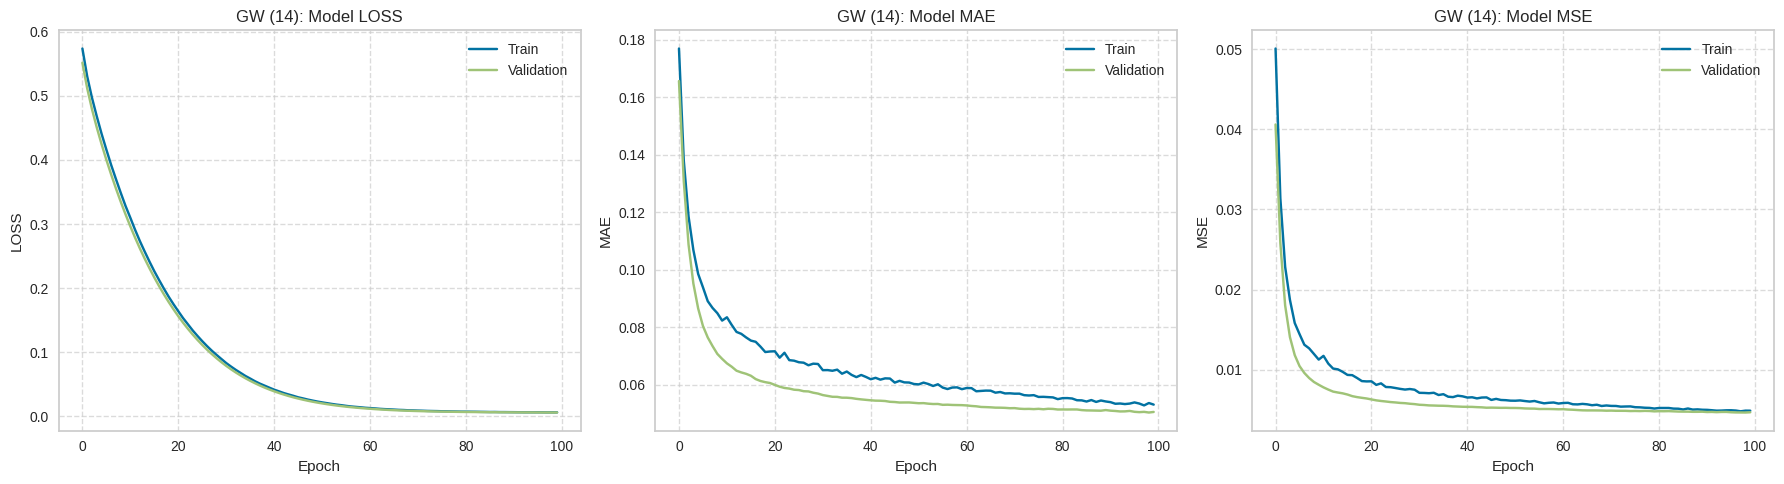

Data prepared. X shape: (4000, 32), M shape: (4000, 9), Y shape: (4000, 2)

Starting Training...
Epoch 1/100
52/52 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.6312 - mae: 0.2853 - mse: 0.1090 - val_loss: 0.6233 - val_mae: 0.3005 - val_mse: 0.1115 - learning_rate: 1.0000e-04
Epoch 2/100
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.5565 - mae: 0.1931 - mse: 0.0547 - val_loss: 0.5513 - val_mae: 0.2101 - val_mse: 0.0606 - learning_rate: 1.0000e-04
Epoch 3/100
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.5105 - mae: 0.1406 - mse: 0.0308 - val_loss: 0.5022 - val_mae: 0.1519 - val_mse: 0.0346 - learning_rate: 1.0000e-04
Epoch 4/100
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.4794 - mae: 0.1205 - mse: 0.0232 - val_loss: 0.4659 - val_mae: 0.1196 - val_mse: 0.0220 - learning_rate: 1.0000e-04
Epoch 5/100
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.4508 - mae: 0.1055 - mse: 0.0184 - val_loss: 0.4364 - val_mae: 0.1017 - val_mse: 0.0163 - learning_rate: 1.0000e-04
Epoch 6/100
52/52 

2026-02-25 23:06:57.573250: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_16}}


8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step

Generating Predictions...
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
{'fpl_name': array(['Raya', 'J.Timber', 'White', 'Saka', 'Ødegaard', 'Trossard',
       'Rice', 'Merino', 'Zubimendi', 'Martinez', 'Cash', 'Konsa',
       'Maatsen', 'Pau', 'Rogers', 'Tielemans', 'Malen', 'McGinn',
       'Kamara', 'Onana', 'Watkins', 'Petrović', 'Senesi', 'Smith',
       'Truffert', 'Kluivert', 'Semenyo', 'O.Dango', 'Tavernier',
       'Brooks', 'Scott', 'Evanilson', 'Kelleher', 'Collins', 'Ajer',
       'Henry', 'Kayode', 'Van den Berg', 'Mbeumo', 'Damsgaard',
       'Henderson', 'Jensen', 'Yarmoliuk', 'Thiago', 'Verbruggen',
       'De Cuyper', 'Dunk', 'F.Kadıoğlu', 'Van Hecke', 'Georginio',
       'Minteh', 'Gruda', 'Hinshelwood', 'Baleba', 'Gomez', 'Wieffer',
       'Welbeck', 'Ekdal', 'Estève', 'Bruun Larsen', 'Cullen', 'Foster',
       'Sánchez', 'Cucurella', 'James', 'Chalobah', 'Gusto', 'Fofana',
       'Neto', 'Enzo', 'Dewsbury-Hall', 'João Pedro', 'Henderso

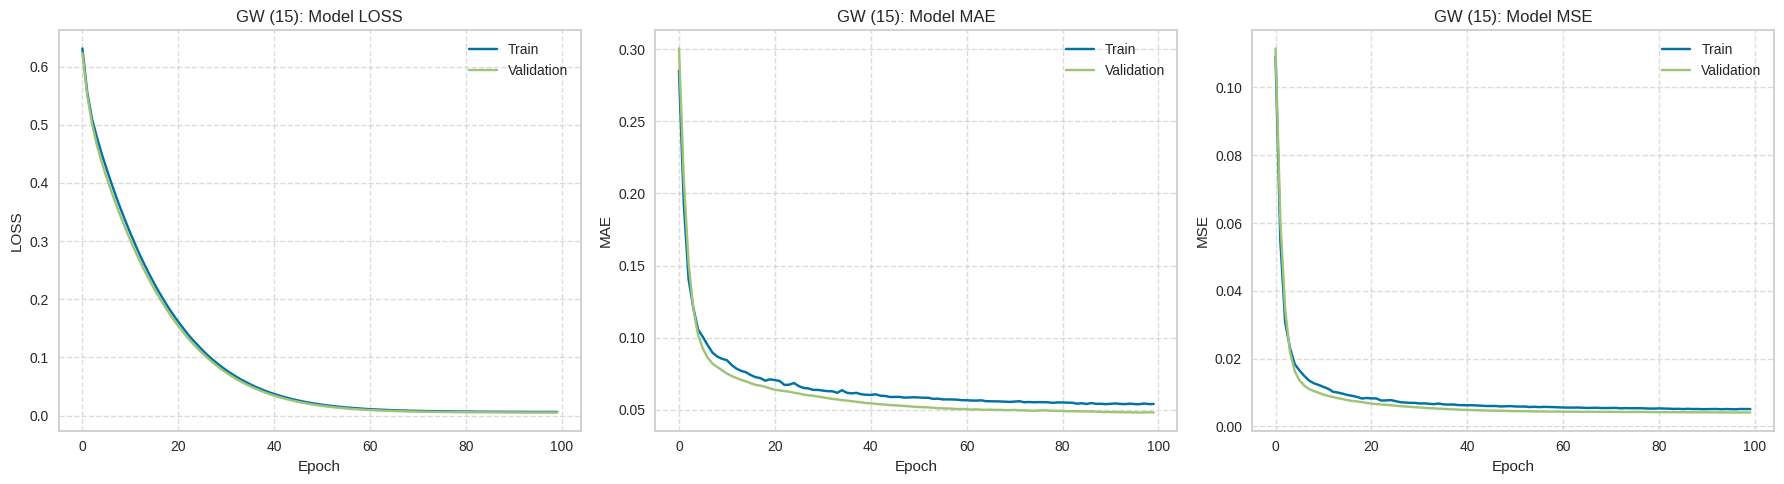

Data prepared. X shape: (4000, 45), M shape: (4000, 9), Y shape: (4000, 2)

Starting Training...
Epoch 1/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.5790 - mae: 0.1899 - mse: 0.0533 - val_loss: 0.5539 - val_mae: 0.1817 - val_mse: 0.0417 - learning_rate: 1.0000e-04
Epoch 2/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.5232 - mae: 0.1271 - mse: 0.0250 - val_loss: 0.5058 - val_mae: 0.1279 - val_mse: 0.0224 - learning_rate: 1.0000e-04
Epoch 3/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.4864 - mae: 0.1044 - mse: 0.0175 - val_loss: 0.4675 - val_mae: 0.0971 - val_mse: 0.0137 - learning_rate: 1.0000e-04
Epoch 4/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.4542 - mae: 0.0942 - mse: 0.0147 - val_loss: 0.4348 - val_mae: 0.0817 - val_mse: 0.0100 - learning_rate: 1.0000e-04
Epoch 5/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.4237 - mae: 0.0885 - mse: 0.0129 - val_loss: 0.4050 - val_mae: 0.0738 - val_mse: 0.0084 - learning_rate: 1.0000e-04
Epoch 6/100
57/57 

2026-02-25 23:07:25.645538: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_16}}


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step

Generating Predictions...
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
{'fpl_name': array(['Raya', 'J.Timber', 'Lewis-Skelly', 'Saka', 'Ødegaard',
       'Martinelli', 'Rice', 'Merino', 'Zubimendi', 'M.Bizot', 'Cash',
       'Konsa', 'Maatsen', 'Rogers', 'Tielemans', 'Malen', 'McGinn',
       'Kamara', 'Onana', 'Watkins', 'Petrović', 'Senesi', 'Smith',
       'Truffert', 'Kluivert', 'Semenyo', 'Tavernier', 'Scott',
       'Evanilson', 'Kelleher', 'Collins', 'Henry', 'Kayode',
       'Van den Berg', 'Hickey', 'Damsgaard', 'Henderson', 'Janelt',
       'Jensen', 'Thiago', 'Verbruggen', 'F.Kadıoğlu', 'Van Hecke',
       'Georginio', 'Minteh', 'Gruda', 'Hinshelwood', 'Ayari', 'Wieffer',
       'Ekdal', 'Estève', 'Hartman', 'Bruun Larsen', 'Cullen', 'Flemming',
       'Sánchez', 'Cucurella', 'James', 'Chalobah', 'Gusto', 'Fofana',
       'Palmer', 'Neto', 'Enzo', 'Gittens', 'Andrey Santos', 'João Pedro',
       'Henderson', 'Lacroix', 'Mitchell', 'Guéhi', 'Ri

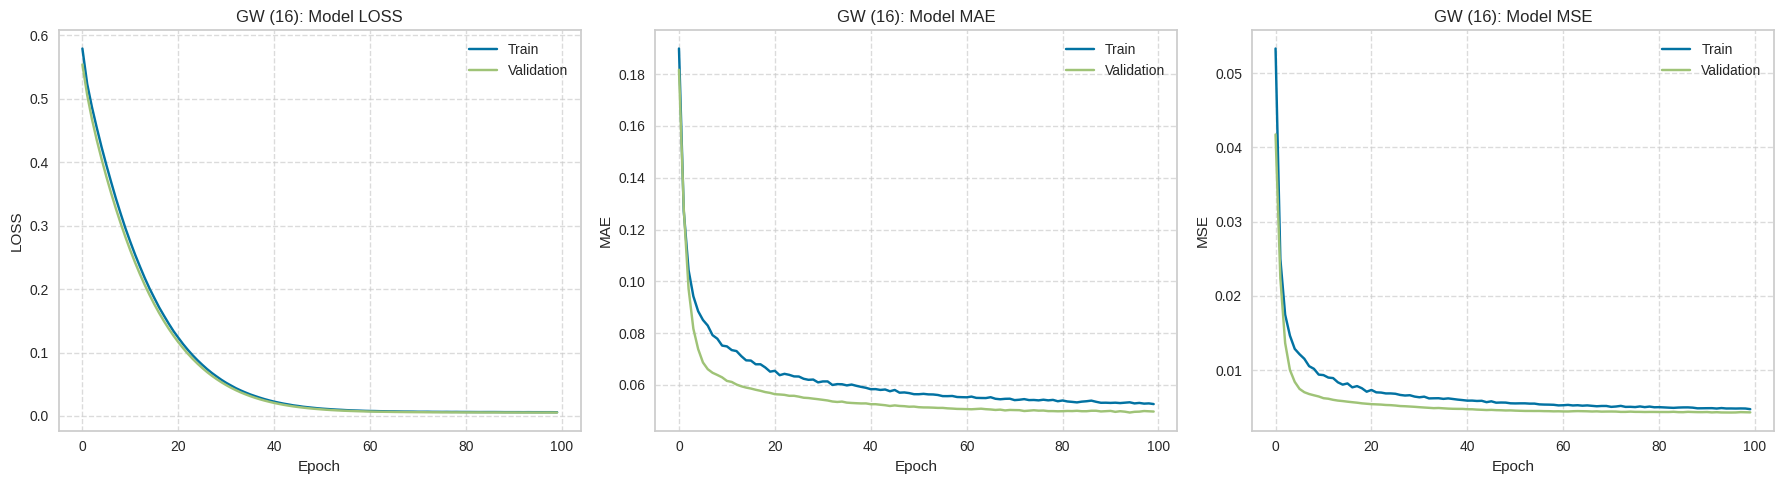

Data prepared. X shape: (4000, 9), M shape: (4000, 9), Y shape: (4000, 2)

Starting Training...
Epoch 1/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.5801 - mae: 0.2870 - mse: 0.1072 - val_loss: 0.5311 - val_mae: 0.2408 - val_mse: 0.0704 - learning_rate: 1.0000e-04
Epoch 2/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.4909 - mae: 0.1711 - mse: 0.0426 - val_loss: 0.4689 - val_mae: 0.1658 - val_mse: 0.0340 - learning_rate: 1.0000e-04
Epoch 3/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.4430 - mae: 0.1159 - mse: 0.0215 - val_loss: 0.4250 - val_mae: 0.1152 - val_mse: 0.0177 - learning_rate: 1.0000e-04
Epoch 4/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4085 - mae: 0.0955 - mse: 0.0149 - val_loss: 0.3904 - val_mae: 0.0870 - val_mse: 0.0108 - learning_rate: 1.0000e-04
Epoch 5/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.3784 - mae: 0.0852 - mse: 0.0122 - val_loss: 0.3602 - val_mae: 0.0720 - val_mse: 0.0078 - learning_rate: 1.0000e-04
Epoch 6/100
62/62 ━

2026-02-25 23:07:51.815873: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_16}}


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step

Generating Predictions...
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
{'fpl_name': array(['Raya', 'Saliba', 'Calafiori', 'J.Timber', 'Saka', 'Ødegaard',
       'Trossard', 'Rice', 'Zubimendi', 'Martinez', 'Cash', 'Konsa',
       'Maatsen', 'Rogers', 'Tielemans', 'J.Ramsey', 'McGinn', 'Kamara',
       'Onana', 'Watkins', 'Petrović', 'Senesi', 'Truffert', 'Kluivert',
       'Semenyo', 'Tavernier', 'Evanilson', 'Kroupi.Jr', 'Kelleher',
       'Collins', 'Lewis-Potter', 'Henry', 'Kayode', 'Van den Berg',
       'Schade', 'Damsgaard', 'Janelt', 'Jensen', 'Yarmoliuk', 'Thiago',
       'Verbruggen', 'De Cuyper', 'F.Kadıoğlu', 'Georginio', 'Minteh',
       'Gruda', 'Hinshelwood', 'Wieffer', 'Walker', 'Ekdal', 'Anthony',
       'Bruun Larsen', 'Cullen', 'Flemming', 'Sánchez', 'Cucurella',
       'James', 'Chalobah', 'Gusto', 'Fofana', 'Palmer', 'Neto', 'Enzo',
       'João Pedro', 'Henderson', 'Lacroix', 'Mitchell', 'Guéhi',
       'Richards', 'Clyne', 'Lerma', 

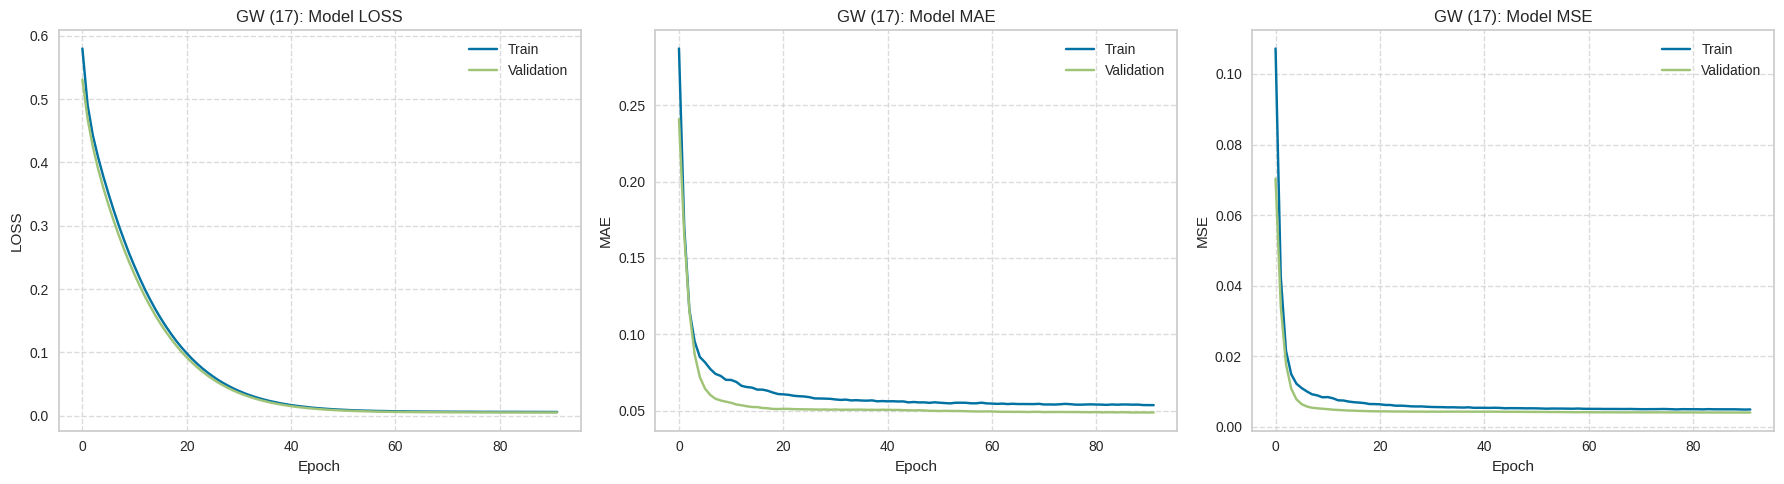

Data prepared. X shape: (4000, 34), M shape: (4000, 9), Y shape: (4000, 2)

Starting Training...
Epoch 1/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.5895 - mae: 0.2070 - mse: 0.0672 - val_loss: 0.5593 - val_mae: 0.1830 - val_mse: 0.0527 - learning_rate: 1.0000e-04
Epoch 2/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.5210 - mae: 0.1323 - mse: 0.0303 - val_loss: 0.5000 - val_mae: 0.1260 - val_mse: 0.0260 - learning_rate: 1.0000e-04
Epoch 3/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4763 - mae: 0.1056 - mse: 0.0187 - val_loss: 0.4565 - val_mae: 0.0983 - val_mse: 0.0158 - learning_rate: 1.0000e-04
Epoch 4/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4399 - mae: 0.0952 - mse: 0.0154 - val_loss: 0.4198 - val_mae: 0.0844 - val_mse: 0.0116 - learning_rate: 1.0000e-04
Epoch 5/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4058 - mae: 0.0882 - mse: 0.0132 - val_loss: 0.3868 - val_mae: 0.0780 - val_mse: 0.0098 - learning_rate: 1.0000e-04
Epoch 6/100
67/67 

2026-02-25 23:08:17.279304: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_16}}


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step

Generating Predictions...
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
{'fpl_name': array(['Raya', 'Saliba', 'Lewis-Skelly', 'Saka', 'Ødegaard', 'Trossard',
       'Rice', 'Merino', 'Zubimendi', 'Martinez', 'Konsa', 'Maatsen',
       'Rogers', 'Tielemans', 'J.Ramsey', 'Malen', 'McGinn', 'Onana',
       'Watkins', 'Petrović', 'Senesi', 'Smith', 'Truffert', 'Kluivert',
       'Semenyo', 'Tavernier', 'Brooks', 'Cook', 'Scott', 'Evanilson',
       'Kelleher', 'Collins', 'Lewis-Potter', 'Ajer', 'Henry', 'Kayode',
       'Schade', 'Janelt', 'Jensen', 'Yarmoliuk', 'Wissa', 'Thiago',
       'Verbruggen', 'Coppola', 'De Cuyper', 'Dunk', 'F.Kadıoğlu',
       'Van Hecke', 'Georginio', 'Minteh', 'Gruda', 'Hinshelwood',
       'Ayari', 'Gomez', 'Wieffer', 'Walker', 'Ekdal', 'Lucas Pires',
       'Anthony', 'Bruun Larsen', 'Cullen', 'Laurent', 'Sánchez',
       'Cucurella', 'James', 'Chalobah', 'Gusto', 'Palmer', 'Neto',
       'Enzo', 'Caicedo', 'João Pedro', 'Hender

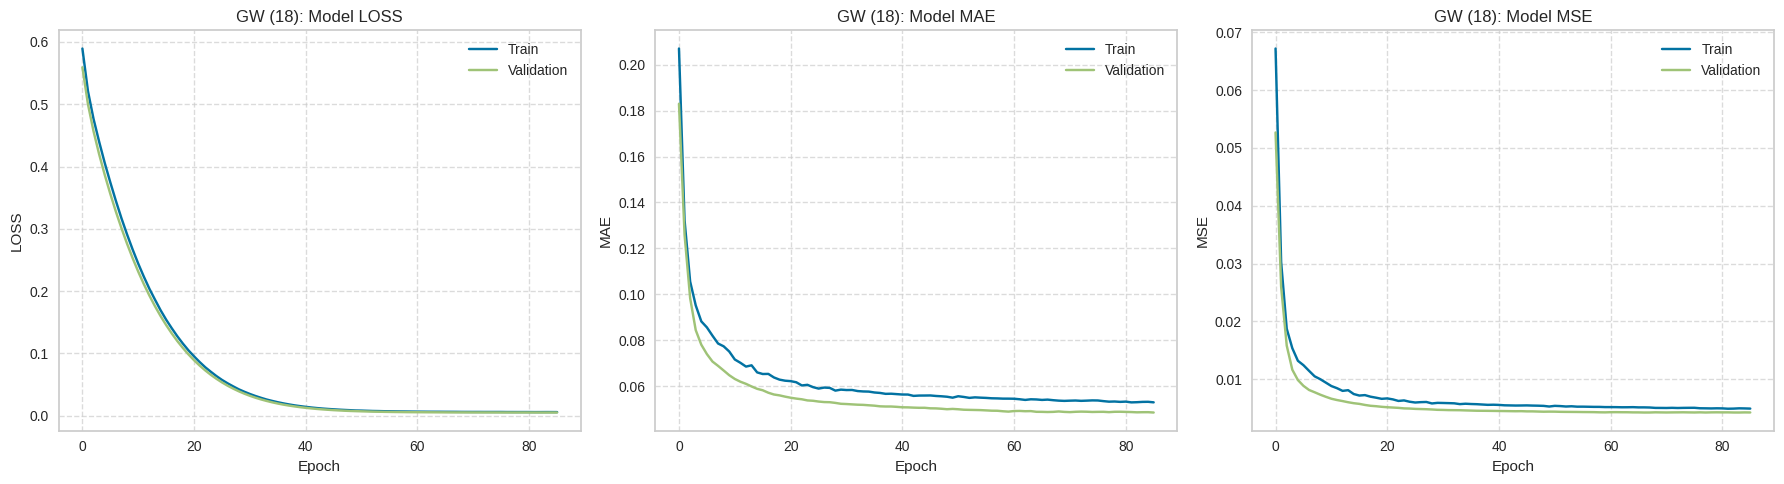

Data prepared. X shape: (4000, 45), M shape: (4000, 9), Y shape: (4000, 2)

Starting Training...
Epoch 1/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.6225 - mae: 0.2581 - mse: 0.0886 - val_loss: 0.5703 - val_mae: 0.2070 - val_mse: 0.0520 - learning_rate: 1.0000e-04
Epoch 2/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.5363 - mae: 0.1488 - mse: 0.0343 - val_loss: 0.5063 - val_mae: 0.1237 - val_mse: 0.0216 - learning_rate: 1.0000e-04
Epoch 3/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.4874 - mae: 0.1101 - mse: 0.0198 - val_loss: 0.4612 - val_mae: 0.0847 - val_mse: 0.0114 - learning_rate: 1.0000e-04
Epoch 4/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.4469 - mae: 0.0924 - mse: 0.0141 - val_loss: 0.4236 - val_mae: 0.0709 - val_mse: 0.0083 - learning_rate: 1.0000e-04
Epoch 5/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.4111 - mae: 0.0861 - mse: 0.0123 - val_loss: 0.3892 - val_mae: 0.0656 - val_mse: 0.0071 - learning_rate: 1.0000e-04
Epoch 6/100
73/73 

2026-02-25 23:08:44.501623: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_16}}


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step

Generating Predictions...
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
{'fpl_name': array(['Raya', 'Saliba', 'J.Timber', 'Saka', 'Ødegaard', 'Trossard',
       'Merino', 'Zubimendi', 'Martinez', 'Konsa', 'Rogers', 'Tielemans',
       'Buendía', 'Malen', 'McGinn', 'Watkins', 'Petrović', 'Senesi',
       'Truffert', 'Kluivert', 'Semenyo', 'Tavernier', 'Brooks', 'Scott',
       'Evanilson', 'Kelleher', 'Collins', 'Lewis-Potter', 'Ajer',
       'Henry', 'Kayode', 'Schade', 'Henderson', 'Janelt', 'Yarmoliuk',
       'Wissa', 'Thiago', 'Verbruggen', 'De Cuyper', 'Dunk', 'F.Kadıoğlu',
       'Van Hecke', 'Mitoma', 'Georginio', 'Minteh', 'Gruda',
       'Hinshelwood', 'Ayari', 'Gomez', 'Walker', 'Ekdal', 'Humphreys',
       'Lucas Pires', 'Bruun Larsen', 'Edwards', 'Laurent', 'Sánchez',
       'James', 'Chalobah', 'Gusto', 'Fofana', 'Palmer', 'Neto', 'Enzo',
       'João Pedro', 'Henderson', 'Lacroix', 'Mitchell', 'Guéhi', 'Clyne',
       'Hughes', 'Lerma', 'Wha

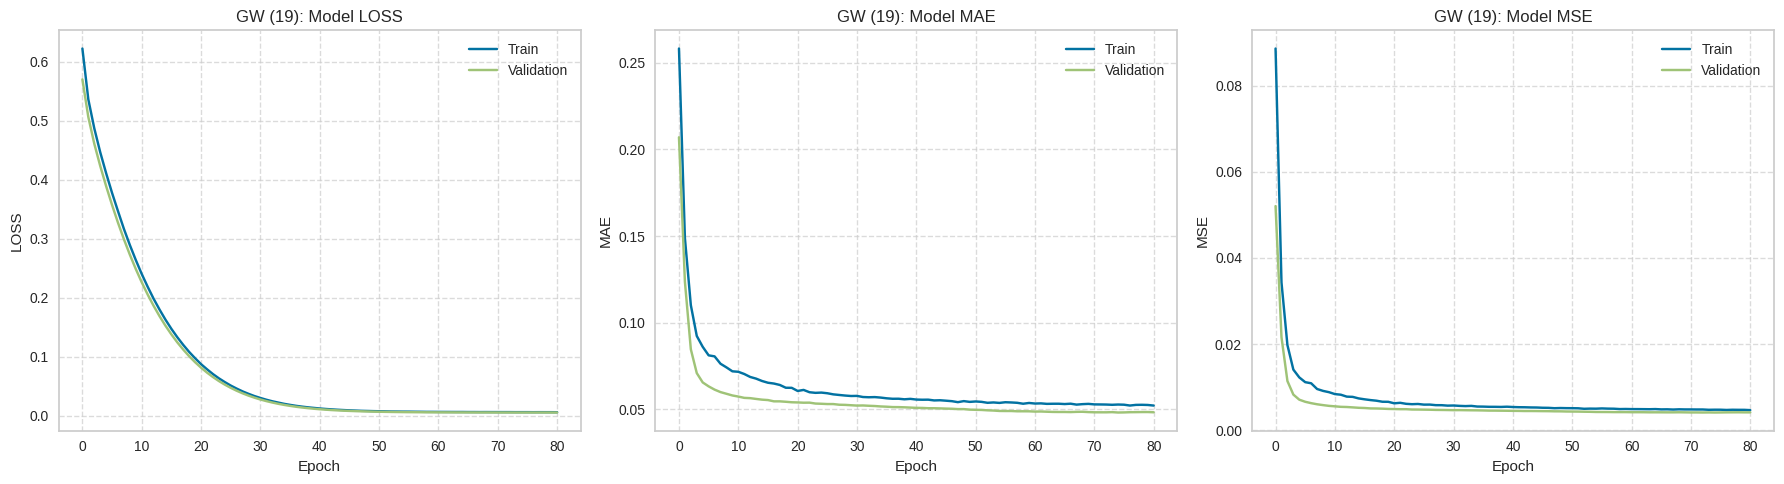

Data prepared. X shape: (4000, 44), M shape: (4000, 9), Y shape: (4000, 2)

Starting Training...
Epoch 1/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.6384 - mae: 0.2731 - mse: 0.1052 - val_loss: 0.5928 - val_mae: 0.2412 - val_mse: 0.0769 - learning_rate: 1.0000e-04
Epoch 2/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.5388 - mae: 0.1622 - mse: 0.0403 - val_loss: 0.5153 - val_mae: 0.1573 - val_mse: 0.0352 - learning_rate: 1.0000e-04
Epoch 3/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.4815 - mae: 0.1116 - mse: 0.0200 - val_loss: 0.4608 - val_mae: 0.1097 - val_mse: 0.0183 - learning_rate: 1.0000e-04
Epoch 4/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.4385 - mae: 0.0949 - mse: 0.0145 - val_loss: 0.4177 - val_mae: 0.0897 - val_mse: 0.0124 - learning_rate: 1.0000e-04
Epoch 5/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.3999 - mae: 0.0861 - mse: 0.0122 - val_loss: 0.3797 - val_mae: 0.0796 - val_mse: 0.0099 - learning_rate: 1.0000e-04
Epoch 6/100
78/78 

2026-02-25 23:09:14.556986: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_16}}


8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step

Generating Predictions...
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
{'fpl_name': array(['Raya', 'Gabriel', 'Saliba', 'J.Timber', 'Saka', 'Ødegaard',
       'Trossard', 'Rice', 'Zubimendi', 'G.Jesus', 'Martinez', 'Cash',
       'Digne', 'Konsa', 'Maatsen', 'Rogers', 'Tielemans', 'Buendía',
       'J.Ramsey', 'McGinn', 'Kamara', 'Watkins', 'Petrović', 'Senesi',
       'Truffert', 'Hill', 'Kluivert', 'Semenyo', 'Tavernier', 'Brooks',
       'Cook', 'Scott', 'Evanilson', 'Kroupi.Jr', 'Kelleher', 'Collins',
       'Lewis-Potter', 'Ajer', 'Kayode', 'Schade', 'Henderson', 'Janelt',
       'Jensen', 'Yarmoliuk', 'Wissa', 'Thiago', 'Verbruggen',
       'De Cuyper', 'Dunk', 'F.Kadıoğlu', 'Van Hecke', 'Veltman',
       'Mitoma', 'Georginio', 'Gruda', 'Ayari', 'Gomez', 'Welbeck',
       'Walker', 'Ekdal', 'Humphreys', 'Lucas Pires', 'Anthony',
       'Bruun Larsen', 'Edwards', 'Laurent', 'Tchaouna', 'James',
       'Chalobah', 'Gusto', 'B.Badiashile', 'Palmer', '

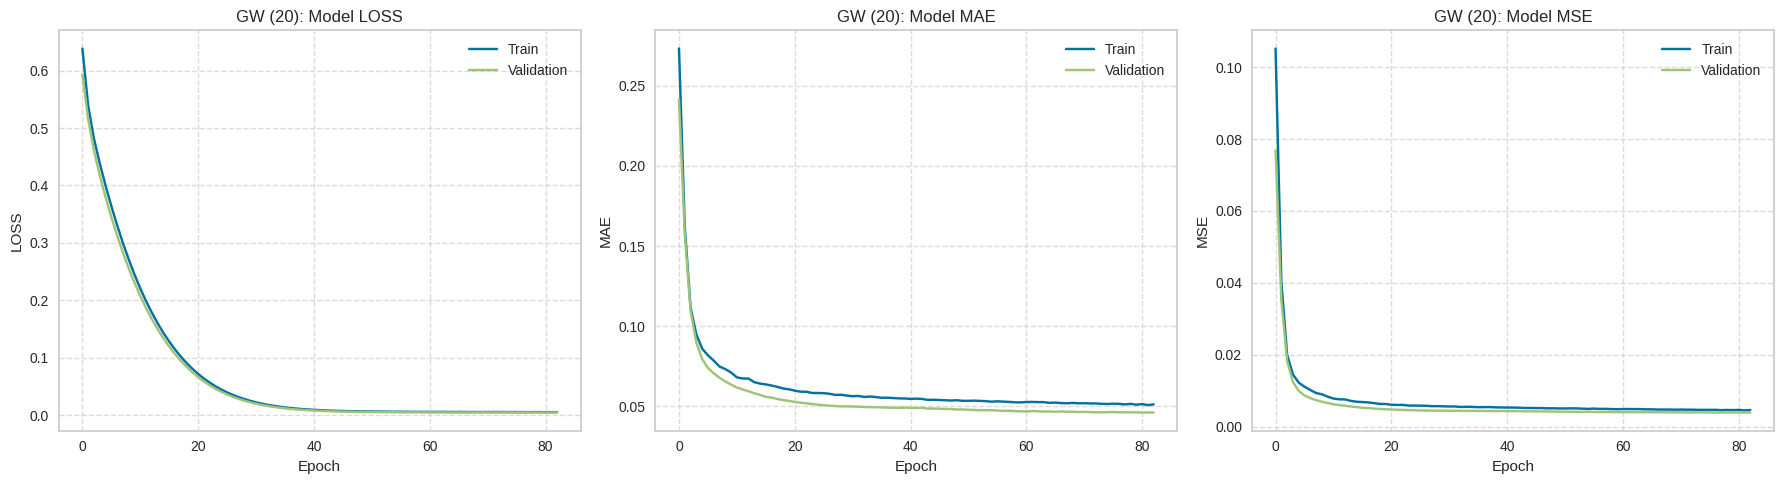

Data prepared. X shape: (4000, 43), M shape: (4000, 9), Y shape: (4000, 2)

Starting Training...
Epoch 1/100
84/84 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.5753 - mae: 0.1866 - mse: 0.0533 - val_loss: 0.5354 - val_mae: 0.1545 - val_mse: 0.0331 - learning_rate: 1.0000e-04
Epoch 2/100
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.5010 - mae: 0.1070 - mse: 0.0192 - val_loss: 0.4738 - val_mae: 0.0928 - val_mse: 0.0134 - learning_rate: 1.0000e-04
Epoch 3/100
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.4534 - mae: 0.0898 - mse: 0.0137 - val_loss: 0.4273 - val_mae: 0.0719 - val_mse: 0.0087 - learning_rate: 1.0000e-04
Epoch 4/100
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4104 - mae: 0.0827 - mse: 0.0117 - val_loss: 0.3861 - val_mae: 0.0653 - val_mse: 0.0074 - learning_rate: 1.0000e-04
Epoch 5/100
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.3705 - mae: 0.0784 - mse: 0.0103 - val_loss: 0.3482 - val_mae: 0.0622 - val_mse: 0.0067 - learning_rate: 1.0000e-04
Epoch 6/100
84/84 

2026-02-25 23:09:43.434028: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_16}}


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step

Generating Predictions...
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
{'fpl_name': array(['Raya', 'Gabriel', 'Saliba', 'J.Timber', 'Lewis-Skelly', 'Saka',
       'Ødegaard', 'Martinelli', 'Trossard', 'Rice', 'Zubimendi',
       'G.Jesus', 'Martinez', 'Cash', 'Digne', 'Konsa', 'Maatsen',
       'Rogers', 'Tielemans', 'Buendía', 'McGinn', 'Watkins', 'Petrović',
       'Senesi', 'Truffert', 'Hill', 'Semenyo', 'Tavernier', 'Brooks',
       'Cook', 'Scott', 'Evanilson', 'Kroupi.Jr', 'Kelleher', 'Collins',
       'Lewis-Potter', 'Ajer', 'Henry', 'Kayode', 'Schade', 'Damsgaard',
       'Janelt', 'Jensen', 'Yarmoliuk', 'Thiago', 'Verbruggen',
       'De Cuyper', 'Dunk', 'F.Kadıoğlu', 'Van Hecke', 'Mitoma',
       'Georginio', 'Hinshelwood', 'Ayari', 'Gomez', 'Walker',
       'Humphreys', 'Lucas Pires', 'Anthony', 'Edwards', 'Laurent',
       'Sánchez', 'Cucurella', 'James', 'Chalobah', 'Gusto', 'Palmer',
       'Neto', 'Enzo', 'Caicedo', 'Andrey Santos', 'Delap

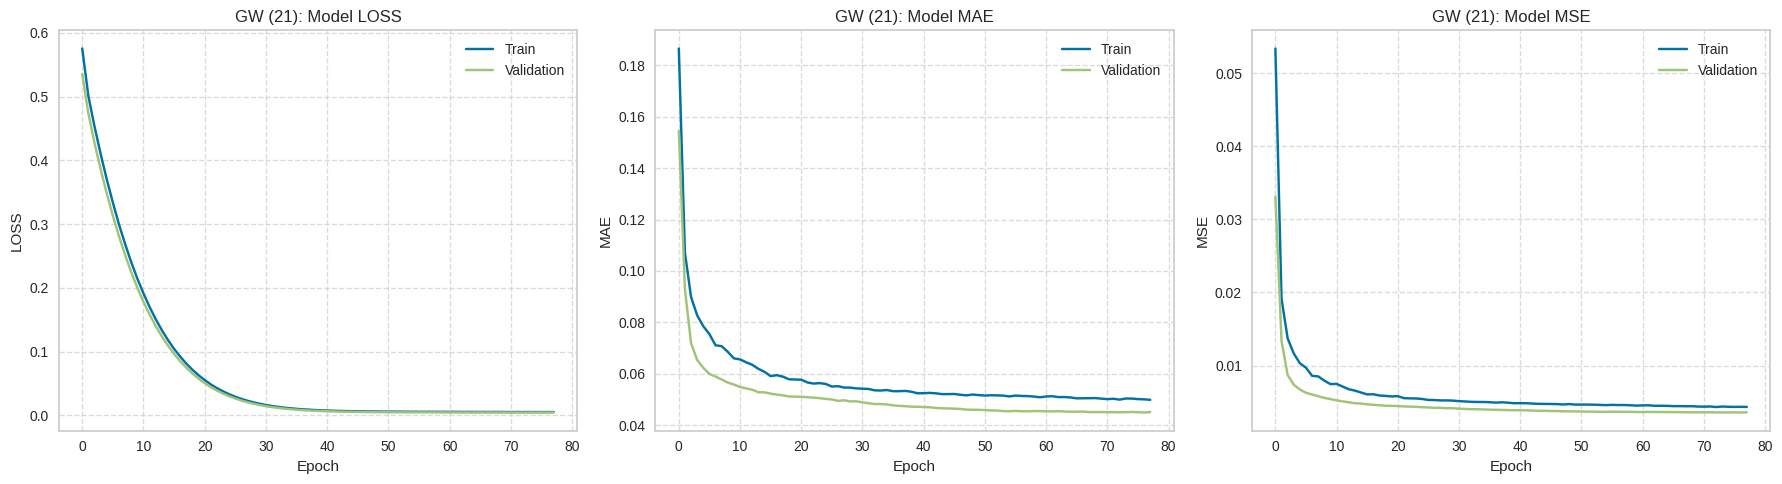

Data prepared. X shape: (4000, 30), M shape: (4000, 9), Y shape: (4000, 2)

Starting Training...
Epoch 1/100
90/90 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.5551 - mae: 0.1723 - mse: 0.0491 - val_loss: 0.5168 - val_mae: 0.1472 - val_mse: 0.0322 - learning_rate: 1.0000e-04
Epoch 2/100
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4823 - mae: 0.1080 - mse: 0.0197 - val_loss: 0.4533 - val_mae: 0.0939 - val_mse: 0.0136 - learning_rate: 1.0000e-04
Epoch 3/100
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4321 - mae: 0.0914 - mse: 0.0140 - val_loss: 0.4057 - val_mae: 0.0778 - val_mse: 0.0098 - learning_rate: 1.0000e-04
Epoch 4/100
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.3877 - mae: 0.0843 - mse: 0.0122 - val_loss: 0.3633 - val_mae: 0.0710 - val_mse: 0.0085 - learning_rate: 1.0000e-04
Epoch 5/100
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.3465 - mae: 0.0788 - mse: 0.0105 - val_loss: 0.3247 - val_mae: 0.0674 - val_mse: 0.0077 - learning_rate: 1.0000e-04
Epoch 6/100
90/90 

2026-02-25 23:10:12.240741: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_16}}


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step

Generating Predictions...
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
{'fpl_name': array(['Raya', 'Gabriel', 'Saliba', 'J.Timber', 'Saka', 'Ødegaard',
       'Madueke', 'Martinelli', 'Trossard', 'Rice', 'Merino', 'Zubimendi',
       'G.Jesus', 'Martinez', 'Cash', 'Digne', 'Konsa', 'Maatsen',
       'Bogarde', 'Rogers', 'Tielemans', 'Buendía', 'Watkins', 'Petrović',
       'Senesi', 'Truffert', 'Hill', 'Semenyo', 'Cook', 'Scott',
       'Evanilson', 'Kroupi.Jr', 'Kelleher', 'Collins', 'Ajer', 'Henry',
       'Kayode', 'Schade', 'Damsgaard', 'Janelt', 'Jensen', 'Yarmoliuk',
       'Wissa', 'Thiago', 'Verbruggen', 'Dunk', 'F.Kadıoğlu', 'Van Hecke',
       'Veltman', 'Mitoma', 'Georginio', 'Minteh', 'Gruda', 'Hinshelwood',
       'Gomez', 'Welbeck', 'Walker', 'Ekdal', 'Estève', 'Humphreys',
       'Lucas Pires', 'Anthony', 'Edwards', 'Sánchez', 'James',
       'Chalobah', 'Fofana', 'Palmer', 'Neto', 'Enzo', 'Caicedo',
       'Andrey Santos', 'João Pedro', '

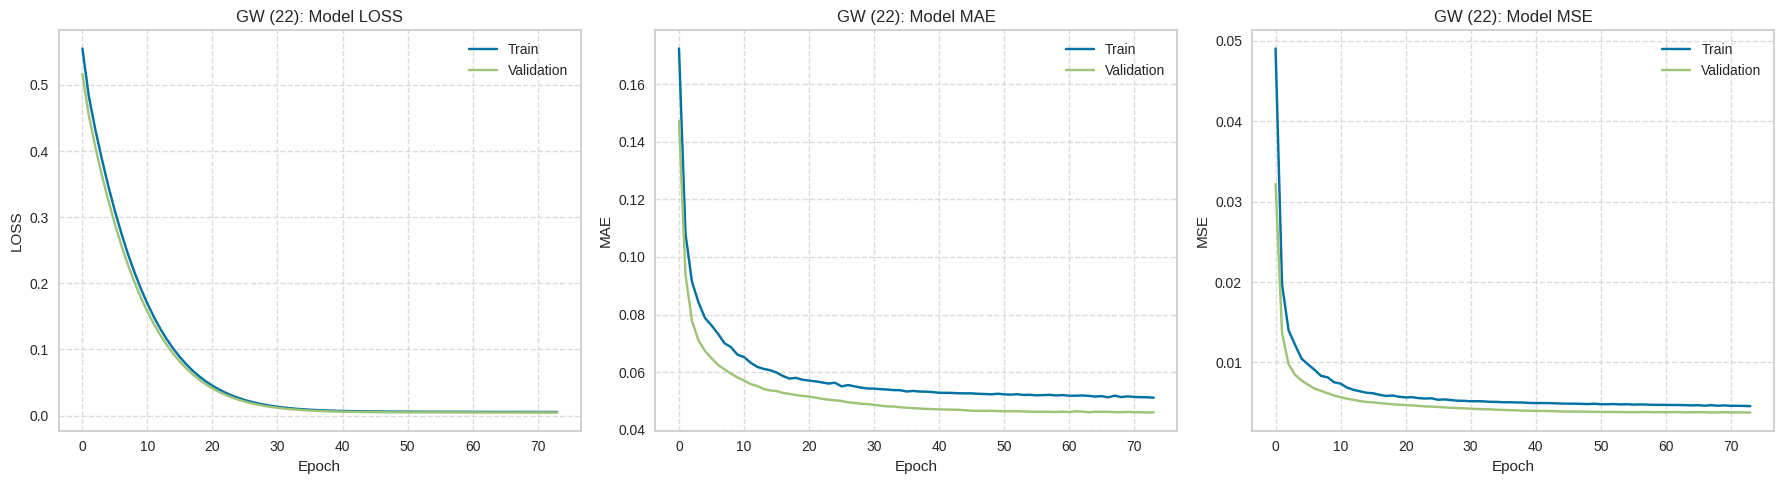

Data prepared. X shape: (4000, 43), M shape: (4000, 9), Y shape: (4000, 2)

Starting Training...
Epoch 1/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.5422 - mae: 0.1190 - mse: 0.0228 - val_loss: 0.5013 - val_mae: 0.0870 - val_mse: 0.0113 - learning_rate: 1.0000e-04
Epoch 2/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.4751 - mae: 0.0898 - mse: 0.0134 - val_loss: 0.4418 - val_mae: 0.0756 - val_mse: 0.0087 - learning_rate: 1.0000e-04
Epoch 3/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4182 - mae: 0.0817 - mse: 0.0113 - val_loss: 0.3884 - val_mae: 0.0696 - val_mse: 0.0076 - learning_rate: 1.0000e-04
Epoch 4/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.3671 - mae: 0.0765 - mse: 0.0099 - val_loss: 0.3405 - val_mae: 0.0648 - val_mse: 0.0067 - learning_rate: 1.0000e-04
Epoch 5/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.3215 - mae: 0.0730 - mse: 0.0090 - val_loss: 0.2975 - val_mae: 0.0613 - val_mse: 0.0061 - learning_rate: 1.0000e-04
Epoch 6/100
95/95 

2026-02-25 23:10:38.525130: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_16}}


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step

Generating Predictions...
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
{'fpl_name': array(['Raya', 'Gabriel', 'Saliba', 'J.Timber', 'White', 'Saka',
       'Ødegaard', 'Trossard', 'Rice', 'Zubimendi', 'G.Jesus', 'Martinez',
       'Cash', 'Konsa', 'Maatsen', 'Pau', 'Bogarde', 'Rogers',
       'Tielemans', 'Buendía', 'Watkins', 'Petrović', 'Senesi',
       'Truffert', 'Hill', 'Semenyo', 'Cook', 'Scott', 'Evanilson',
       'Kroupi.Jr', 'Kelleher', 'Collins', 'Ajer', 'Henry', 'Kayode',
       'Hickey', 'Mbeumo', 'Schade', 'Damsgaard', 'Janelt', 'Jensen',
       'Yarmoliuk', 'Wissa', 'Thiago', 'Verbruggen', 'Dunk', 'F.Kadıoğlu',
       'Van Hecke', 'Mitoma', 'Ayari', 'Gomez', 'Welbeck', 'Walker',
       'Estève', 'Humphreys', 'Lucas Pires', 'Tuanzebe', 'Anthony',
       'Edwards', 'Laurent', 'Sánchez', 'Cucurella', 'James', 'Chalobah',
       'Gusto', 'B.Badiashile', 'Neto', 'Enzo', 'Caicedo',
       'Andrey Santos', 'João Pedro', 'Henderson', 'Lacroix', 'M

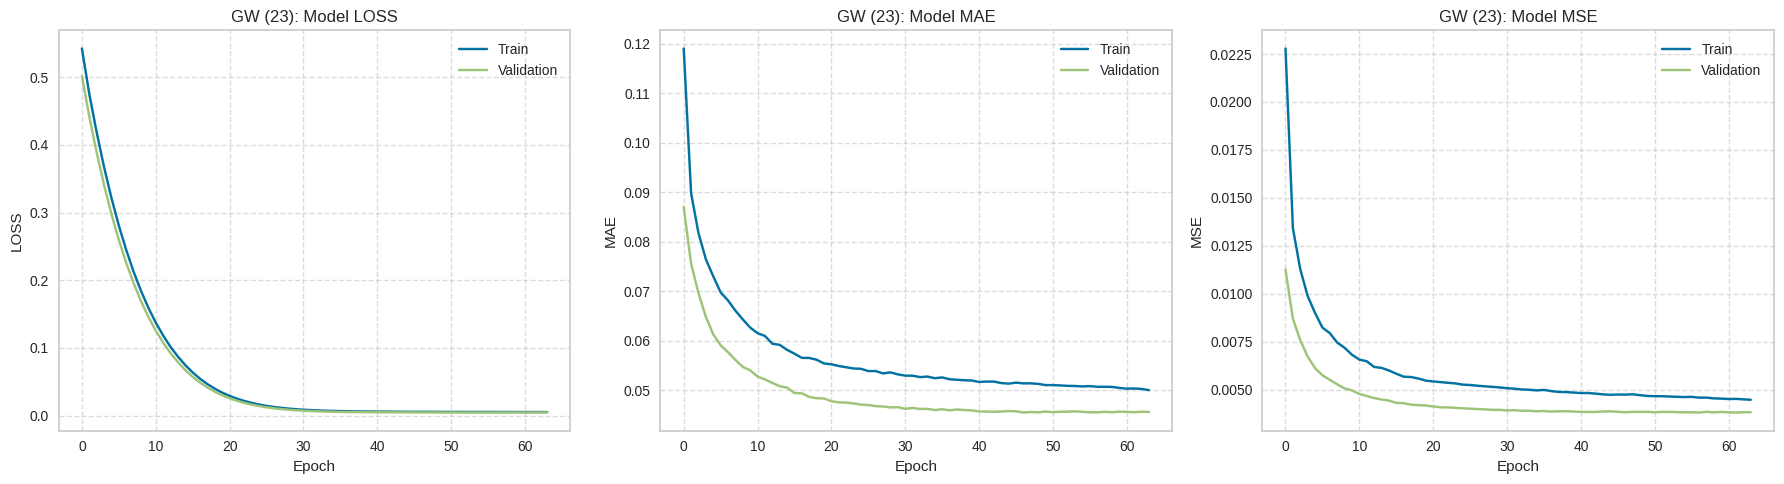

In [17]:
eval_metrics_affine = {}
preds = {}
for round in range(8,24):
    history, evaluation_metrics, preds_df, _ = apnn_trainer(data, selections.loc[round, 'best_features'], round)
    preds[round] = preds_df
    eval_metrics_affine[round] = evaluation_metrics

    # Plot History
    plot_training_history(history, round)


#### Plots


In [18]:
eval_metrics_affine_ = pd.DataFrame(eval_metrics_affine).T

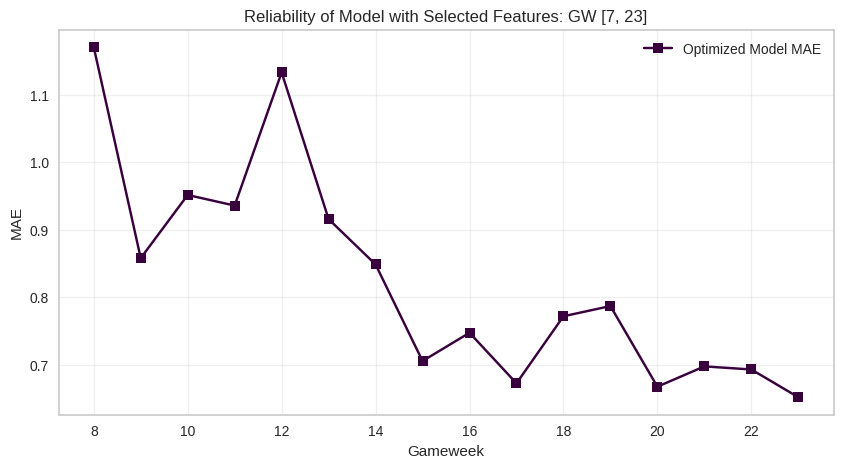

In [19]:

# --- Visualization ---
plt.figure(figsize=(10, 5))
plt.plot(eval_metrics_affine_.index, eval_metrics_affine_['test_mae'], marker='s', color="#38003c", label='Optimized Model MAE')
plt.title('Reliability of Model with Selected Features: GW [7, 23]', fontsize=12)
plt.xlabel('Gameweek')
plt.ylabel('MAE')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


# Joint 24-25


## Functions


In [20]:
def working_df(data, gw):
    data_24 = data[data['season'] == 2024]
    data_25 = data[data['season'] == 2025]

    GW_full = data_25['round'].values

    # Split
    GW_TRAIN_END = gw - 1
    train_mask = GW_full <= GW_TRAIN_END
    test_mask = GW_full == (GW_TRAIN_END + 1)

    train_data = data_25[train_mask]
    test_data = data_25[test_mask]

    train_data = pd.concat([data_24, train_data])

    test_player_names = test_data['fpl_name'].values
    test_player_ids = test_data['fpl_id'].values
    # test_player_positions = test_data['position'].values
    test_data = test_data.drop(columns=['fpl_name', 'fpl_id', 'team_id', 'round'])
    train_data = train_data.drop(columns=['fpl_name', 'fpl_id', 'team_id', 'round'])

    return train_data, test_data, test_player_names, test_player_ids, test_mask


def working_df(data, gw, joint=False):
    GW_TRAIN_END = gw - 1
    if joint:
        GW_full = data[['round', 'season']]
        train_mask = (GW_full['season'] == 2024) | ((GW_full['season'] == 2025) & (GW_full['round'] <= GW_TRAIN_END))
        test_mask = ((GW_full['season'] == 2025) &  (GW_full['round'] == (GW_TRAIN_END + 1))) # GW_full == (GW_TRAIN_END + 1)
    else:
        GW_full = data['round'].values
        train_mask = GW_full <= GW_TRAIN_END
        test_mask = GW_full == (GW_TRAIN_END + 1)

    train_data = data[train_mask]
    test_data = data[test_mask]

    test_player_names = test_data['fpl_name'].values
    test_player_ids = test_data['fpl_id'].values
    # test_player_positions = test_data['position'].values
    test_data = test_data.drop(columns=['fpl_name', 'fpl_id', 'team_id', 'round'])
    train_data = train_data.drop(columns=['fpl_name', 'fpl_id', 'team_id', 'round'])

    return train_data, test_data, test_player_names, test_player_ids, test_mask

def plot_preds(preds, position, gw, full_data, test_mask):
    # xp_actual = test_target
    # xp_pred = preds #['prediction_label'].values
    # position = data_25_26[test_mask]['position'].values

    preds_data = pd.DataFrame({
        'fpl_name': full_data[test_mask]['fpl_name'].values,
        'Actual_xP':  full_data[test_mask]['xP'].values,
        'Pred_xP': preds,
        'position': full_data[test_mask]['position'].values
    })

    position = position
    names = preds_data[preds_data['position'] == position]['fpl_name'].values
    xp_actual = preds_data[preds_data['position'] == position]['Actual_xP'].values
    xp_pred = preds_data[preds_data['position'] == position]['Pred_xP'].values


    # Convert names to positions on x-axis
    x = np.arange(len(names))

    plt.figure(figsize=(14, 6))

    # Plot actual points
    plt.plot(x, xp_actual, marker='o', linewidth=2, label='Actual Points')

    # Plot predicted points
    plt.plot(x, xp_pred, marker='x', linewidth=2, label='Predicted Points')

    # Improve readability
    plt.xticks(x, names, rotation=75, ha='right')
    plt.xlabel("Players")
    plt.ylabel("Points")
    plt.title(f" : Actual vs Predicted Points per Player for position {position} (GW {gw})")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Width of each bar
    width = 0.31

    plt.figure(figsize=(14, 6))

    # Bars
    plt.bar(x - width/2, xp_actual, width, label='Actual Points')
    plt.bar(x + width/2, xp_pred, width, label='Predicted Points')

    # Labels & formatting
    plt.xticks(x, names, rotation=75, ha='right')
    plt.xlabel("Players")
    plt.ylabel("Points")
    plt.title(f" {position} : Actual vs Predicted Points per Player for position {position} (GW {gw})")
    plt.legend()

    plt.tight_layout()
    plt.show()


## Data Prep


In [21]:
# all_data = pd.read_csv('https://raw.githubusercontent.com/ilyandho/FPL-Optimal-Transfer/refs/heads/FantasyGo/Prediction%20with%20Affine%20PNN/data/rolled_player_data.csv')
all_data = pd.read_csv('../Prediction with Affine PNN/data/all_data.csv')


In [22]:
cols = [

    'fpl_id', 'round', 'fpl_name', 'position', 'team_id', 'team', 'season', 'opponent_team', 'was_home', 'xP_25',# 'xP_next',
    'selected_by_percent','value', 'transfers_in', 'transfers_out',  'selected', 'ownership_change', 'percenatge_net_transfers',
    'cbitr_volume_90', 'cbitr_ewm_90', 'cbitr_ewm_probability',  'cbitr_probability','elo',  'team_h_difficulty', 'team_a_difficulty',
    'win_prob', 'draw_prob', 'lose_prob', 'anytime_logit', 'two_plus_logit', 'hatrick_logit',


    'creativity_rolling_1', 'creativity_rolling_3', 'creativity_rolling_5', 'influence_rolling_1', 'influence_rolling_3', 'influence_rolling_5', 'threat_rolling_1',
    'threat_rolling_3', 'threat_rolling_5', 'minutes_rolling_1', 'minutes_rolling_3', 'minutes_rolling_5', 'pts_bonus_rolling_1', 'pts_bonus_rolling_3',
    'pts_bonus_rolling_5', 'expected_goals_rolling_1', 'expected_goals_rolling_3', 'expected_goals_rolling_5', 'expected_assists_rolling_1',
    'expected_assists_rolling_3', 'expected_assists_rolling_5', 'xP_rolling_1', 'xP_rolling_3', 'xP_rolling_5', 'expected_goals_conceded_rolling_1',
    'expected_goals_conceded_rolling_3', 'expected_goals_conceded_rolling_5', 'goals_conceded_rolling_1', 'goals_conceded_rolling_3', 'goals_conceded_rolling_5',
    'goals_scored_rolling_1', 'goals_scored_rolling_3', 'goals_scored_rolling_5', 'shots_rolling_1', 'shots_rolling_3', 'shots_rolling_5', 'key_passes_rolling_1',
    'key_passes_rolling_3', 'key_passes_rolling_5', 'npg_rolling_1', 'npg_rolling_3', 'npg_rolling_5', 'npxG_rolling_1', 'npxG_rolling_3', 'npxG_rolling_5',
    'goals_rolling_1', 'goals_rolling_3', 'goals_rolling_5', 'xG_rolling_1', 'xG_rolling_3', 'xG_rolling_5', 'xA_rolling_1', 'xA_rolling_3', 'xA_rolling_5',
    'saves_rolling_1', 'saves_rolling_3', 'saves_rolling_5', 'starts_rolling_1', 'starts_rolling_3', 'starts_rolling_5', 'yellow_cards_rolling_1',
    'yellow_cards_rolling_3', 'yellow_cards_rolling_5', 'red_cards_rolling_1', 'red_cards_rolling_3', 'red_cards_rolling_5', 'assists_rolling_1', 'assists_rolling_3',
    'assists_rolling_5', 'clean_sheets_rolling_1', 'clean_sheets_rolling_3', 'clean_sheets_rolling_5', 'value_rolling_1', 'value_rolling_3', 'value_rolling_5',
    'ict_index_rolling_1', 'ict_index_rolling_3', 'ict_index_rolling_5', 'selected_rolling_1', 'selected_rolling_3', 'selected_rolling_5', 'transfers_in_rolling_1',
    'transfers_in_rolling_3', 'transfers_in_rolling_5', 'transfers_out_rolling_1', 'transfers_out_rolling_3', 'transfers_out_rolling_5', 'ownership_change_rolling_1',
    'ownership_change_rolling_3', 'ownership_change_rolling_5', 'percenatge_net_transfers_rolling_1', 'percenatge_net_transfers_rolling_3',
    'percenatge_net_transfers_rolling_5', 'xGChain_rolling_1', 'xGChain_rolling_3', 'xGChain_rolling_5', 'xGBuildup_rolling_1', 'xGBuildup_rolling_3',
    'xGBuildup_rolling_5', 'expected_goal_involvements_rolling_1', 'expected_goal_involvements_rolling_3', 'expected_goal_involvements_rolling_5', 'form_rolling_1',
    'form_rolling_3', 'form_rolling_5', 'clearances_blocks_interceptions_rolling_1', 'clearances_blocks_interceptions_rolling_3',
    'clearances_blocks_interceptions_rolling_5', 'tackles_rolling_1', 'tackles_rolling_3', 'tackles_rolling_5', 'recoveries_rolling_1', 'recoveries_rolling_3',
    'recoveries_rolling_5', 'selected_by_percent_rolling_1', 'selected_by_percent_rolling_3', 'selected_by_percent_rolling_5', 'strength_rolling_1',
    'strength_rolling_3', 'strength_rolling_5', 'strength_overall_home_rolling_1', 'strength_overall_home_rolling_3', 'strength_overall_home_rolling_5',
    'strength_overall_away_rolling_1', 'strength_overall_away_rolling_3', 'strength_overall_away_rolling_5', 'strength_attack_home_rolling_1',
    'strength_attack_home_rolling_3', 'strength_attack_home_rolling_5', 'strength_attack_away_rolling_1', 'strength_attack_away_rolling_3',
    'strength_attack_away_rolling_5', 'strength_defence_home_rolling_1', 'strength_defence_home_rolling_3', 'strength_defence_home_rolling_5',
    'strength_defence_away_rolling_1', 'strength_defence_away_rolling_3', 'strength_defence_away_rolling_5',

    'creativity_1_ewm', 'creativity_3_ewm', 'creativity_5_ewm', 'influence_1_ewm', 'influence_3_ewm', 'influence_5_ewm', 'threat_1_ewm', 'threat_3_ewm', 'threat_5_ewm',
    'minutes_1_ewm', 'minutes_3_ewm', 'minutes_5_ewm', 'pts_bonus_1_ewm', 'pts_bonus_3_ewm', 'pts_bonus_5_ewm', 'expected_goals_1_ewm', 'expected_goals_3_ewm',
    'expected_goals_5_ewm', 'expected_assists_1_ewm', 'expected_assists_3_ewm', 'expected_assists_5_ewm', 'xP_1_ewm', 'xP_3_ewm', 'xP_5_ewm',
    'expected_goals_conceded_1_ewm', 'expected_goals_conceded_3_ewm', 'expected_goals_conceded_5_ewm', 'goals_conceded_1_ewm', 'goals_conceded_3_ewm',
    'goals_conceded_5_ewm', 'goals_scored_1_ewm', 'goals_scored_3_ewm', 'goals_scored_5_ewm', 'shots_1_ewm', 'shots_3_ewm', 'shots_5_ewm', 'key_passes_1_ewm',
    'key_passes_3_ewm', 'key_passes_5_ewm', 'npg_1_ewm', 'npg_3_ewm', 'npg_5_ewm', 'npxG_1_ewm', 'npxG_3_ewm', 'npxG_5_ewm', 'goals_1_ewm', 'goals_3_ewm',
    'goals_5_ewm', 'xG_1_ewm', 'xG_3_ewm', 'xG_5_ewm', 'xA_1_ewm', 'xA_3_ewm', 'xA_5_ewm', 'saves_1_ewm', 'saves_3_ewm', 'saves_5_ewm', 'starts_1_ewm', 'starts_3_ewm',
    'starts_5_ewm', 'yellow_cards_1_ewm', 'yellow_cards_3_ewm', 'yellow_cards_5_ewm', 'red_cards_1_ewm', 'red_cards_3_ewm', 'red_cards_5_ewm', 'assists_1_ewm',
    'assists_3_ewm', 'assists_5_ewm', 'clean_sheets_1_ewm', 'clean_sheets_3_ewm', 'clean_sheets_5_ewm', 'value_1_ewm', 'value_3_ewm', 'value_5_ewm', 'ict_index_1_ewm',
    'ict_index_3_ewm', 'ict_index_5_ewm', 'selected_1_ewm', 'selected_3_ewm', 'selected_5_ewm', 'transfers_in_1_ewm', 'transfers_in_3_ewm', 'transfers_in_5_ewm',
    'transfers_out_1_ewm', 'transfers_out_3_ewm', 'transfers_out_5_ewm', 'ownership_change_1_ewm', 'ownership_change_3_ewm', 'ownership_change_5_ewm',
    'percenatge_net_transfers_1_ewm', 'percenatge_net_transfers_3_ewm', 'percenatge_net_transfers_5_ewm', 'xGChain_1_ewm', 'xGChain_3_ewm', 'xGChain_5_ewm',
    'xGBuildup_1_ewm', 'xGBuildup_3_ewm', 'xGBuildup_5_ewm', 'expected_goal_involvements_1_ewm', 'expected_goal_involvements_3_ewm', 'expected_goal_involvements_5_ewm',
    'form_1_ewm', 'form_3_ewm', 'form_5_ewm', 'clearances_blocks_interceptions_1_ewm', 'clearances_blocks_interceptions_3_ewm', 'clearances_blocks_interceptions_5_ewm',
    'tackles_1_ewm', 'tackles_3_ewm', 'tackles_5_ewm', 'recoveries_1_ewm', 'recoveries_3_ewm', 'recoveries_5_ewm', 'selected_by_percent_1_ewm',
    'selected_by_percent_3_ewm', 'selected_by_percent_5_ewm', 'strength_1_ewm', 'strength_3_ewm', 'strength_5_ewm', 'strength_overall_home_1_ewm',
    'strength_overall_home_3_ewm', 'strength_overall_home_5_ewm', 'strength_overall_away_1_ewm', 'strength_overall_away_3_ewm', 'strength_overall_away_5_ewm',
    'strength_attack_home_1_ewm', 'strength_attack_home_3_ewm', 'strength_attack_home_5_ewm', 'strength_attack_away_1_ewm', 'strength_attack_away_3_ewm',
    'strength_attack_away_5_ewm', 'strength_defence_home_1_ewm', 'strength_defence_home_3_ewm', 'strength_defence_home_5_ewm', 'strength_defence_away_1_ewm',
    'strength_defence_away_3_ewm', 'strength_defence_away_5_ewm',

    'opp_elo', 'opp_clean_sheets', 'opp_strength'
    ]

# all_data = all_data.rename({'web_name': 'fpl_name'}, axis=1)

all_data_24 = all_data[all_data['season'] == 2024]
all_data_25 = all_data[all_data['season'] == 2025]
all_data_24

hist_data_24 = all_data_24[
    # (all_data_24['round'] > 5)  &
    (all_data_24['minutes_rolling_3'] > 15) &
    (all_data_24['minutes'] > 15)
    ]

hist_data_25 = all_data_25[
    # (all_data_25['round'] > 5)  &
    (all_data_25['minutes_rolling_3'] > 15) &
    (all_data_25['minutes'] > 15)
    ]
# Cater for round = 1: rolling_3 = 0
hist_data_25_1 = all_data_25[
    (all_data_25['round'] == 1)  &
    # (all_data_25['minutes_rolling_3'] > 15) &
    (all_data_25['minutes'] > 15)
    ]

hist_data_25 = pd.concat([hist_data_25_1, hist_data_25])

# Make sure round = gw is included: it doesn't meet most of the filters
tar_data = all_data_25[
                        (all_data_25['round'] == gw) &
                        (all_data_25['minutes_rolling_3'] >= 15)
                    ]

all_data_ = pd.concat([hist_data_24, hist_data_25, tar_data])

active_data = all_data_[cols].copy()
active_data_ = active_data.copy()


CATEGORICAL_COLS = ['position', 'team', 'opponent_team', 'was_home']

# Initialize encoder
# handle_unknown='ignore' ensures new teams result in all-zero rows for those features
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

# Fit and transform the categorical columns
encoded_array = encoder.fit(active_data_[CATEGORICAL_COLS])

# Create a DataFrame with the encoded features
encoded_cols = encoder.get_feature_names_out(CATEGORICAL_COLS)
encoded_df = pd.DataFrame(
    encoder.transform(active_data_[CATEGORICAL_COLS]),
    columns=encoded_cols,
    index=active_data_.index
)

cols = [*cols, *encoded_cols]
# Combine with numerical data
data = pd.concat([active_data_, encoded_df], axis=1).drop(columns=CATEGORICAL_COLS)

feature_cols = [
 'selected_by_percent',
 'value',
 'transfers_in',
 'transfers_out',
 'selected',
 'ownership_change',
 'percenatge_net_transfers',
 'cbitr_volume_90',
 'cbitr_ewm_90',
 'cbitr_ewm_probability',
 'cbitr_probability',
 'elo',
 'team_h_difficulty',
 'team_a_difficulty',
 'win_prob',
 'draw_prob',
 'lose_prob',
 'creativity_rolling_1',
 'creativity_rolling_3',
 'creativity_rolling_5',
 'influence_rolling_1',
 'influence_rolling_3',
 'influence_rolling_5',
 'threat_rolling_1',
 'threat_rolling_3',
 'threat_rolling_5',
 'minutes_rolling_1',
 'minutes_rolling_3',
 'minutes_rolling_5',
 'pts_bonus_rolling_1',
 'pts_bonus_rolling_3',
 'pts_bonus_rolling_5',
 'expected_goals_rolling_1',
 'expected_goals_rolling_3',
 'expected_goals_rolling_5',
 'expected_assists_rolling_1',
 'expected_assists_rolling_3',
 'expected_assists_rolling_5',
 'xP_rolling_1',
 'xP_rolling_3',
 'xP_rolling_5',
 'expected_goals_conceded_rolling_1',
 'expected_goals_conceded_rolling_3',
 'expected_goals_conceded_rolling_5',
 'goals_conceded_rolling_1',
 'goals_conceded_rolling_3',
 'goals_conceded_rolling_5',
 'goals_scored_rolling_1',
 'goals_scored_rolling_3',
 'goals_scored_rolling_5',
 'shots_rolling_1',
 'shots_rolling_3',
 'shots_rolling_5',
 'key_passes_rolling_1',
 'key_passes_rolling_3',
 'key_passes_rolling_5',
 'npg_rolling_1',
 'npg_rolling_3',
 'npg_rolling_5',
 'npxG_rolling_1',
 'npxG_rolling_3',
 'npxG_rolling_5',
 'goals_rolling_1',
 'goals_rolling_3',
 'goals_rolling_5',
 'xG_rolling_1',
 'xG_rolling_3',
 'xG_rolling_5',
 'xA_rolling_1',
 'xA_rolling_3',
 'xA_rolling_5',
 'saves_rolling_1',
 'saves_rolling_3',
 'saves_rolling_5',
 'starts_rolling_1',
 'starts_rolling_3',
 'starts_rolling_5',
 'yellow_cards_rolling_1',
 'yellow_cards_rolling_3',
 'yellow_cards_rolling_5',
 'red_cards_rolling_1',
 'red_cards_rolling_3',
 'red_cards_rolling_5',
 'assists_rolling_1',
 'assists_rolling_3',
 'assists_rolling_5',
 'clean_sheets_rolling_1',
 'clean_sheets_rolling_3',
 'clean_sheets_rolling_5',
 'value_rolling_1',
 'value_rolling_3',
 'value_rolling_5',
 'ict_index_rolling_1',
 'ict_index_rolling_3',
 'ict_index_rolling_5',
 'selected_rolling_1',
 'selected_rolling_3',
 'selected_rolling_5',
 'transfers_in_rolling_1',
 'transfers_in_rolling_3',
 'transfers_in_rolling_5',
 'transfers_out_rolling_1',
 'transfers_out_rolling_3',
 'transfers_out_rolling_5',
 'ownership_change_rolling_1',
 'ownership_change_rolling_3',
 'ownership_change_rolling_5',
 'percenatge_net_transfers_rolling_1',
 'percenatge_net_transfers_rolling_3',
 'percenatge_net_transfers_rolling_5',
 'xGChain_rolling_1',
 'xGChain_rolling_3',
 'xGChain_rolling_5',
 'xGBuildup_rolling_1',
 'xGBuildup_rolling_3',
 'xGBuildup_rolling_5',
 'expected_goal_involvements_rolling_1',
 'expected_goal_involvements_rolling_3',
 'expected_goal_involvements_rolling_5',
 'form_rolling_1',
 'form_rolling_3',
 'form_rolling_5',
 'clearances_blocks_interceptions_rolling_1',
 'clearances_blocks_interceptions_rolling_3',
 'clearances_blocks_interceptions_rolling_5',
 'tackles_rolling_1',
 'tackles_rolling_3',
 'tackles_rolling_5',
 'recoveries_rolling_1',
 'recoveries_rolling_3',
 'recoveries_rolling_5',
 'selected_by_percent_rolling_1',
 'selected_by_percent_rolling_3',
 'selected_by_percent_rolling_5',
 'strength_rolling_1',
 'strength_rolling_3',
 'strength_rolling_5',
 'strength_overall_home_rolling_1',
 'strength_overall_home_rolling_3',
 'strength_overall_home_rolling_5',
 'strength_overall_away_rolling_1',
 'strength_overall_away_rolling_3',
 'strength_overall_away_rolling_5',
 'strength_attack_home_rolling_1',
 'strength_attack_home_rolling_3',
 'strength_attack_home_rolling_5',
 'strength_attack_away_rolling_1',
 'strength_attack_away_rolling_3',
 'strength_attack_away_rolling_5',
 'strength_defence_home_rolling_1',
 'strength_defence_home_rolling_3',
 'strength_defence_home_rolling_5',
 'strength_defence_away_rolling_1',
 'strength_defence_away_rolling_3',
 'strength_defence_away_rolling_5',
 'creativity_1_ewm',
 'creativity_3_ewm',
 'creativity_5_ewm',
 'influence_1_ewm',
 'influence_3_ewm',
 'influence_5_ewm',
 'threat_1_ewm',
 'threat_3_ewm',
 'threat_5_ewm',
 'minutes_1_ewm',
 'minutes_3_ewm',
 'minutes_5_ewm',
 'pts_bonus_1_ewm',
 'pts_bonus_3_ewm',
 'pts_bonus_5_ewm',
 'expected_goals_1_ewm',
 'expected_goals_3_ewm',
 'expected_goals_5_ewm',
 'expected_assists_1_ewm',
 'expected_assists_3_ewm',
 'expected_assists_5_ewm',
 'xP_1_ewm',
 'xP_3_ewm',
 'xP_5_ewm',
 'expected_goals_conceded_1_ewm',
 'expected_goals_conceded_3_ewm',
 'expected_goals_conceded_5_ewm',
 'goals_conceded_1_ewm',
 'goals_conceded_3_ewm',
 'goals_conceded_5_ewm',
 'goals_scored_1_ewm',
 'goals_scored_3_ewm',
 'goals_scored_5_ewm',
 'shots_1_ewm',
 'shots_3_ewm',
 'shots_5_ewm',
 'key_passes_1_ewm',
 'key_passes_3_ewm',
 'key_passes_5_ewm',
 'npg_1_ewm',
 'npg_3_ewm',
 'npg_5_ewm',
 'npxG_1_ewm',
 'npxG_3_ewm',
 'npxG_5_ewm',
 'goals_1_ewm',
 'goals_3_ewm',
 'goals_5_ewm',
 'xG_1_ewm',
 'xG_3_ewm',
 'xG_5_ewm',
 'xA_1_ewm',
 'xA_3_ewm',
 'xA_5_ewm',
 'saves_1_ewm',
 'saves_3_ewm',
 'saves_5_ewm',
 'starts_1_ewm',
 'starts_3_ewm',
 'starts_5_ewm',
 'yellow_cards_1_ewm',
 'yellow_cards_3_ewm',
 'yellow_cards_5_ewm',
 'red_cards_1_ewm',
 'red_cards_3_ewm',
 'red_cards_5_ewm',
 'assists_1_ewm',
 'assists_3_ewm',
 'assists_5_ewm',
 'clean_sheets_1_ewm',
 'clean_sheets_3_ewm',
 'clean_sheets_5_ewm',
 'value_1_ewm',
 'value_3_ewm',
 'value_5_ewm',
 'ict_index_1_ewm',
 'ict_index_3_ewm',
 'ict_index_5_ewm',
 'selected_1_ewm',
 'selected_3_ewm',
 'selected_5_ewm',
 'transfers_in_1_ewm',
 'transfers_in_3_ewm',
 'transfers_in_5_ewm',
 'transfers_out_1_ewm',
 'transfers_out_3_ewm',
 'transfers_out_5_ewm',
 'ownership_change_1_ewm',
 'ownership_change_3_ewm',
 'ownership_change_5_ewm',
 'percenatge_net_transfers_1_ewm',
 'percenatge_net_transfers_3_ewm',
 'percenatge_net_transfers_5_ewm',
 'xGChain_1_ewm',
 'xGChain_3_ewm',
 'xGChain_5_ewm',
 'xGBuildup_1_ewm',
 'xGBuildup_3_ewm',
 'xGBuildup_5_ewm',
 'expected_goal_involvements_1_ewm',
 'expected_goal_involvements_3_ewm',
 'expected_goal_involvements_5_ewm',
 'form_1_ewm',
 'form_3_ewm',
 'form_5_ewm',
 'clearances_blocks_interceptions_1_ewm',
 'clearances_blocks_interceptions_3_ewm',
 'clearances_blocks_interceptions_5_ewm',
 'tackles_1_ewm',
 'tackles_3_ewm',
 'tackles_5_ewm',
 'recoveries_1_ewm',
 'recoveries_3_ewm',
 'recoveries_5_ewm',
 'selected_by_percent_1_ewm',
 'selected_by_percent_3_ewm',
 'selected_by_percent_5_ewm',
 'strength_1_ewm',
 'strength_3_ewm',
 'strength_5_ewm',
 'strength_overall_home_1_ewm',
 'strength_overall_home_3_ewm',
 'strength_overall_home_5_ewm',
 'strength_overall_away_1_ewm',
 'strength_overall_away_3_ewm',
 'strength_overall_away_5_ewm',
 'strength_attack_home_1_ewm',
 'strength_attack_home_3_ewm',
 'strength_attack_home_5_ewm',
 'strength_attack_away_1_ewm',
 'strength_attack_away_3_ewm',
 'strength_attack_away_5_ewm',
 'strength_defence_home_1_ewm',
 'strength_defence_home_3_ewm',
 'strength_defence_home_5_ewm',
 'strength_defence_away_1_ewm',
 'strength_defence_away_3_ewm',
 'strength_defence_away_5_ewm',
 'opp_elo',
 'opp_clean_sheets',
 'opp_strength',
 'position_0',
 'position_DEF',
 'position_FWD',
 'position_GK',
 'position_MID',
 'team_0',
 'team_Arsenal_2024',
 'team_Arsenal_2025',
 'team_Aston Villa_2024',
 'team_Aston Villa_2025',
 'team_Bournemouth_2024',
 'team_Bournemouth_2025',
 'team_Brentford_2024',
 'team_Brentford_2025',
 'team_Brighton_2024',
 'team_Brighton_2025',
 'team_Burnley_2025',
 'team_Chelsea_2024',
 'team_Chelsea_2025',
 'team_Crystal Palace_2024',
 'team_Crystal Palace_2025',
 'team_Everton_2024',
 'team_Everton_2025',
 'team_Fulham_2024',
 'team_Fulham_2025',
 'team_Ipswich_2024',
 'team_Leeds_2025',
 'team_Leicester_2024',
 'team_Liverpool_2024',
 'team_Liverpool_2025',
 'team_Man City_2024',
 'team_Man City_2025',
 'team_Man Utd_2024',
 'team_Man Utd_2025',
 'team_Newcastle_2024',
 'team_Newcastle_2025',
 "team_Nott'm Forest_2024",
 "team_Nott'm Forest_2025",
 'team_Southampton_2024',
 'team_Spurs_2024',
 'team_Spurs_2025',
 'team_Sunderland_2025',
 'team_West Ham_2024',
 'team_West Ham_2025',
 'team_Wolves_2024',
 'team_Wolves_2025',
 'opponent_team_0',
 'opponent_team_Arsenal_2024',
 'opponent_team_Arsenal_2025',
 'opponent_team_Aston Villa_2024',
 'opponent_team_Aston Villa_2025',
 'opponent_team_Bournemouth_2024',
 'opponent_team_Bournemouth_2025',
 'opponent_team_Brentford_2024',
 'opponent_team_Brentford_2025',
 'opponent_team_Brighton_2024',
 'opponent_team_Brighton_2025',
 'opponent_team_Burnley_2025',
 'opponent_team_Chelsea_2024',
 'opponent_team_Chelsea_2025',
 'opponent_team_Crystal Palace_2024',
 'opponent_team_Crystal Palace_2025',
 'opponent_team_Everton_2024',
 'opponent_team_Everton_2025',
 'opponent_team_Fulham_2024',
 'opponent_team_Fulham_2025',
 'opponent_team_Ipswich_2024',
 'opponent_team_Leeds_2025',
 'opponent_team_Leicester_2024',
 'opponent_team_Liverpool_2024',
 'opponent_team_Liverpool_2025',
 'opponent_team_Man City_2024',
 'opponent_team_Man City_2025',
 'opponent_team_Man Utd_2024',
 'opponent_team_Man Utd_2025',
 'opponent_team_Newcastle_2024',
 'opponent_team_Newcastle_2025',
 "opponent_team_Nott'm Forest_2024",
 "opponent_team_Nott'm Forest_2025",
 'opponent_team_Southampton_2024',
 'opponent_team_Spurs_2024',
 'opponent_team_Spurs_2025',
 'opponent_team_Sunderland_2025',
 'opponent_team_West Ham_2024',
 'opponent_team_West Ham_2025',
 'opponent_team_Wolves_2024',
 'opponent_team_Wolves_2025'
]

# data = data.rename(columns={'xP_25': 'xP'})
data

,fpl_id,round,fpl_name,team_id,season,xP_25,selected_by_percent,value,transfers_in,transfers_out,...,opponent_team_Spurs_2024,opponent_team_Spurs_2025,opponent_team_Sunderland_2025,opponent_team_West Ham_2024,opponent_team_West Ham_2025,opponent_team_Wolves_2024,opponent_team_Wolves_2025,was_home_0,was_home_False,was_home_True
6,509.0,7,Werner,0.0,2024,2.2,0.2,62.0,1237.0,1074.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
7,509.0,8,Werner,0.0,2024,3.5,0.2,62.0,2181.0,1092.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
8,509.0,9,Werner,0.0,2024,3.0,0.2,62.0,622.0,1218.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
10,509.0,11,Werner,0.0,2024,0.3,0.2,62.0,515.0,1892.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
14,509.0,15,Werner,0.0,2024,3.2,0.2,62.0,428.0,1020.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
53033,0.0,24,0,0.0,2025,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
53109,0.0,24,0,0.0,2025,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
53793,0.0,24,0,0.0,2025,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
53945,0.0,24,0,0.0,2025,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


## Model Selection


### GW 1


In [23]:
train_data, test_data, player_names, player_ids, test_mask = working_df(data, 1, joint=True)
train_data

,season,xP_25,selected_by_percent,value,transfers_in,transfers_out,selected,ownership_change,percenatge_net_transfers,cbitr_volume_90,...,opponent_team_Spurs_2024,opponent_team_Spurs_2025,opponent_team_Sunderland_2025,opponent_team_West Ham_2024,opponent_team_West Ham_2025,opponent_team_Wolves_2024,opponent_team_Wolves_2025,was_home_0,was_home_False,was_home_True
6,2024,2.2,0.2,62.0,1237.0,1074.0,17199.0,765.0,0.070532,8.684211,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
7,2024,3.5,0.2,62.0,2181.0,1092.0,19083.0,1884.0,0.332722,6.093750,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
8,2024,3.0,0.2,62.0,622.0,1218.0,18693.0,-390.0,-0.323913,5.943396,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
10,2024,0.3,0.2,62.0,515.0,1892.0,17661.0,17661.0,-0.572081,5.625000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
14,2024,3.2,0.2,62.0,428.0,1020.0,18990.0,-491.0,-0.408840,5.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
50120,2024,3.3,0.0,40.0,101.0,29.0,1516.0,100.0,0.553846,17.516779,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
50121,2024,0.5,0.0,40.0,127.0,89.0,1593.0,77.0,0.175926,17.396907,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
50422,2024,0.5,0.0,40.0,76.0,20.0,742.0,742.0,0.583333,15.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
50729,2024,0.5,0.0,45.0,131.0,43.0,330.0,99.0,0.505747,15.517241,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


,Description,Value
0,Session id,42
1,Target,xP_25
2,Target type,Regression
3,Original data shape,"(7943, 391)"
4,Transformed data shape,"(7943, 234)"
5,Transformed train set shape,"(6354, 234)"
6,Transformed test set shape,"(1589, 234)"
7,Numeric features,390
8,Preprocess,True
9,Imputation type,simple


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
lightgbm,Light Gradient Boosting Machine,0.9724,1.7775,1.3314,0.6192,0.4083,0.4590,2.2510
xgboost,Extreme Gradient Boosting,1.0119,1.8773,1.3685,0.5983,0.4087,0.4837,2.2970
gbr,Gradient Boosting Regressor,1.0210,2.0098,1.4160,0.5700,0.4425,0.4741,5.1080
et,Extra Trees Regressor,1.0296,2.0904,1.4436,0.5530,0.4504,0.4670,8.5790
br,Bayesian Ridge,1.0495,2.2300,1.4913,0.5233,0.4658,0.4504,1.1100
ridge,Ridge Regression,1.0507,2.2319,1.4920,0.5228,0.4662,0.4415,1.0540
lr,Linear Regression,1.0527,2.2344,1.4928,0.5223,0.4662,0.4426,1.5080
rf,Random Forest Regressor,1.0818,2.2685,1.5042,0.5148,0.4673,0.5018,16.3400
omp,Orthogonal Matching Pursuit,1.1565,2.5859,1.6063,0.4471,0.4956,0.5742,1.0400
en,Elastic Net,1.2605,2.8395,1.6838,0.3923,0.5138,0.6688,1.0990


LGBMRegressor(n_jobs=-1, random_state=42)


interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

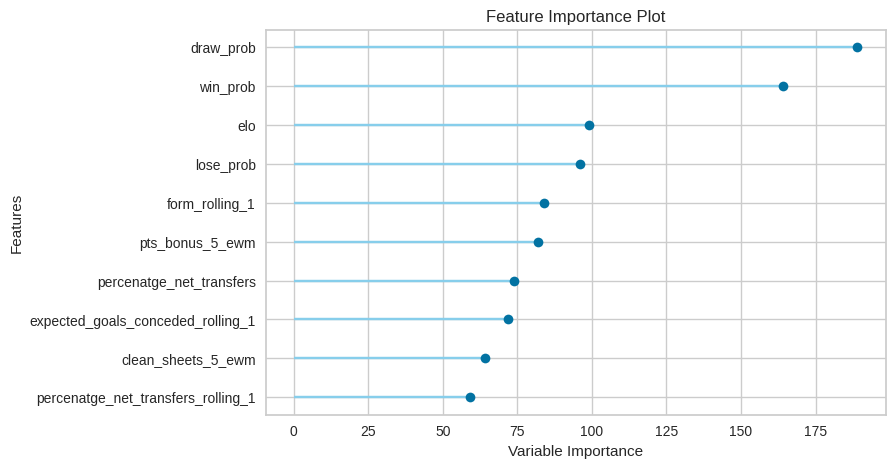

In [24]:
train_data, test_data, player_names, player_ids, test_mask = working_df(data, 1, joint=True)

train_data = train_data.reset_index(drop=True)

base_model = setup(train_data, target = 'xP_25',
                    train_size=0.8,
                    remove_multicollinearity=True,  # Drop collinear features
                    # feature_selection=True,        # Auto-select important features
                    session_id=42,
                    # use_gpu=True


                )
# models()

best_model_1 = base_model.compare_models(sort='MAE', n_select=1)
print(best_model_1)

evaluate_model(best_model_1)

plot_model(best_model_1, plot='feature')        # Feature importance


### GW 2


,Description,Value
0,Session id,42
1,Target,xP_25
2,Target type,Regression
3,Original data shape,"(8325, 391)"
4,Transformed data shape,"(8325, 214)"
5,Transformed train set shape,"(6660, 214)"
6,Transformed test set shape,"(1665, 214)"
7,Numeric features,390
8,Preprocess,True
9,Imputation type,simple


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
lightgbm,Light Gradient Boosting Machine,0.9895,1.8193,1.3476,0.6081,0.4126,0.4704,2.3530
xgboost,Extreme Gradient Boosting,1.0062,1.9013,1.3780,0.5900,0.4110,0.4886,1.9700
et,Extra Trees Regressor,1.0200,2.0881,1.4436,0.5500,0.4474,0.4640,9.4110
gbr,Gradient Boosting Regressor,1.0400,2.0678,1.4369,0.5540,0.4468,0.4916,5.4440
br,Bayesian Ridge,1.0733,2.2991,1.5146,0.5036,0.4698,0.4743,1.1690
ridge,Ridge Regression,1.0742,2.3035,1.5162,0.5028,0.4708,0.4656,1.0770
lr,Linear Regression,1.0759,2.3062,1.5171,0.5022,0.4708,0.4661,1.1170
rf,Random Forest Regressor,1.0811,2.2819,1.5091,0.5083,0.4659,0.5077,17.4090
omp,Orthogonal Matching Pursuit,1.1876,2.6928,1.6391,0.4188,0.5010,0.5990,1.0900
en,Elastic Net,1.2641,2.8703,1.6930,0.3807,0.5140,0.6734,1.1450


LGBMRegressor(n_jobs=-1, random_state=42)


interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

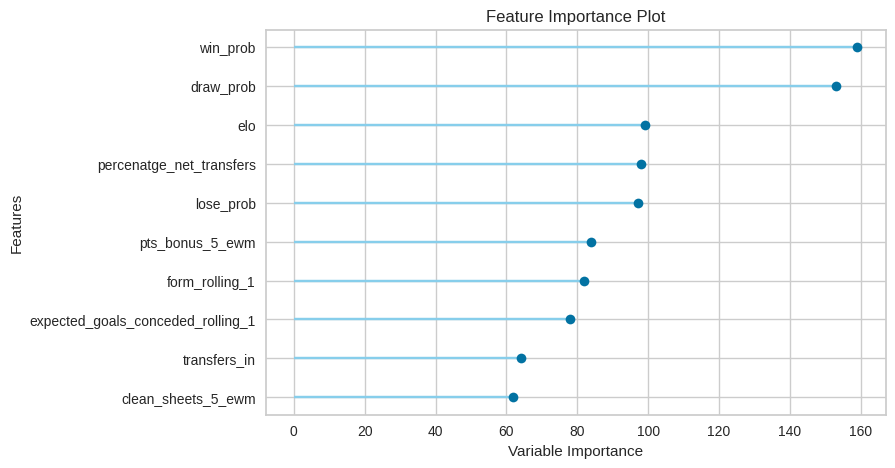

In [25]:
train_data, test_data, player_names, player_ids, test_mask = working_df(data, 2, joint=True)
train_data = train_data.reset_index(drop=True)
base_model_2 = setup(train_data, target = 'xP_25',
                    train_size=0.8,
                    remove_multicollinearity=True,  # Drop collinear features
                    # feature_selection=True,        # Auto-select important features
                    session_id=42,
                    # use_gpu=True


                )
# models()

best_model_2 = base_model_2.compare_models(sort='MAE', n_select=1)
print(best_model_2)

evaluate_model(best_model_2)

plot_model(best_model_2, plot='feature')        # Feature importance


### GW 3


,Description,Value
0,Session id,42
1,Target,xP_25
2,Target type,Regression
3,Original data shape,"(8537, 391)"
4,Transformed data shape,"(8537, 187)"
5,Transformed train set shape,"(6829, 187)"
6,Transformed test set shape,"(1708, 187)"
7,Numeric features,390
8,Preprocess,True
9,Imputation type,simple


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
lightgbm,Light Gradient Boosting Machine,0.9949,1.8472,1.3567,0.6017,0.4118,0.4739,2.4390
xgboost,Extreme Gradient Boosting,1.0180,1.9308,1.3877,0.5839,0.4105,0.4937,1.9470
et,Extra Trees Regressor,1.0222,2.0942,1.4444,0.5485,0.4468,0.4726,9.7680
gbr,Gradient Boosting Regressor,1.0539,2.1103,1.4506,0.5448,0.4500,0.4980,5.5070
rf,Random Forest Regressor,1.0847,2.2774,1.5064,0.5091,0.4625,0.5117,17.7490
ridge,Ridge Regression,1.0850,2.3173,1.5189,0.5012,0.4693,0.4788,1.0950
br,Bayesian Ridge,1.0857,2.3174,1.5191,0.5009,0.4691,0.4866,1.2050
lr,Linear Regression,1.0866,2.3230,1.5206,0.5001,0.4693,0.4799,1.1550
omp,Orthogonal Matching Pursuit,1.2468,2.8057,1.6736,0.3942,0.5066,0.6436,1.1160
en,Elastic Net,1.2649,2.8498,1.6868,0.3850,0.5115,0.6757,1.1820


LGBMRegressor(n_jobs=-1, random_state=42)


interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

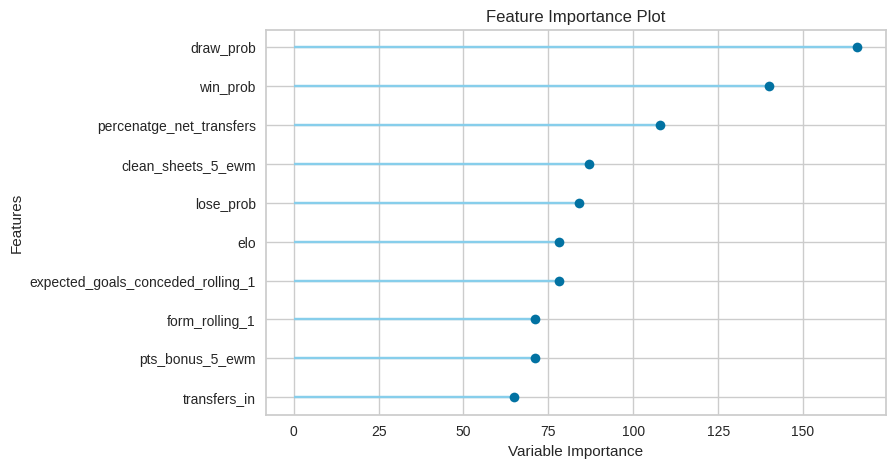

In [26]:
train_data, test_data, player_names, player_ids, test_mask = working_df(data, 3, joint=True)
train_data = train_data.reset_index(drop=True)
base_model_3 = setup(train_data, target = 'xP_25',
                    train_size=0.8,
                    remove_multicollinearity=True,  # Drop collinear features
                    # feature_selection=True,        # Auto-select important features
                    session_id=42,
                    # use_gpu=True


                )
# models()

best_model_3 = base_model_3.compare_models(sort='MAE', n_select=1)
print(best_model_3)

evaluate_model(best_model_3)

plot_model(best_model_3, plot='feature')        # Feature importance


### GW 4


,Description,Value
0,Session id,42
1,Target,xP_25
2,Target type,Regression
3,Original data shape,"(8768, 391)"
4,Transformed data shape,"(8768, 186)"
5,Transformed train set shape,"(7014, 186)"
6,Transformed test set shape,"(1754, 186)"
7,Numeric features,390
8,Preprocess,True
9,Imputation type,simple


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
lightgbm,Light Gradient Boosting Machine,0.9803,1.7765,1.3306,0.6161,0.4086,0.4716,2.4440
xgboost,Extreme Gradient Boosting,1.0042,1.8631,1.3634,0.5964,0.4064,0.4920,1.9810
et,Extra Trees Regressor,1.0106,2.0253,1.4199,0.5630,0.4435,0.4694,9.9790
gbr,Gradient Boosting Regressor,1.0421,2.0445,1.4280,0.5577,0.4443,0.4963,5.6030
rf,Random Forest Regressor,1.0690,2.1893,1.4768,0.5273,0.4596,0.5058,18.1490
br,Bayesian Ridge,1.0734,2.2593,1.4998,0.5126,0.4661,0.4809,1.2300
ridge,Ridge Regression,1.0744,2.2586,1.4995,0.5127,0.4669,0.4741,1.1340
lr,Linear Regression,1.0761,2.2621,1.5006,0.5120,0.4671,0.4748,1.1560
omp,Orthogonal Matching Pursuit,1.2382,2.7625,1.6593,0.4036,0.5046,0.6424,1.1230
en,Elastic Net,1.2553,2.7935,1.6689,0.3963,0.5091,0.6735,1.2050


LGBMRegressor(n_jobs=-1, random_state=42)


interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

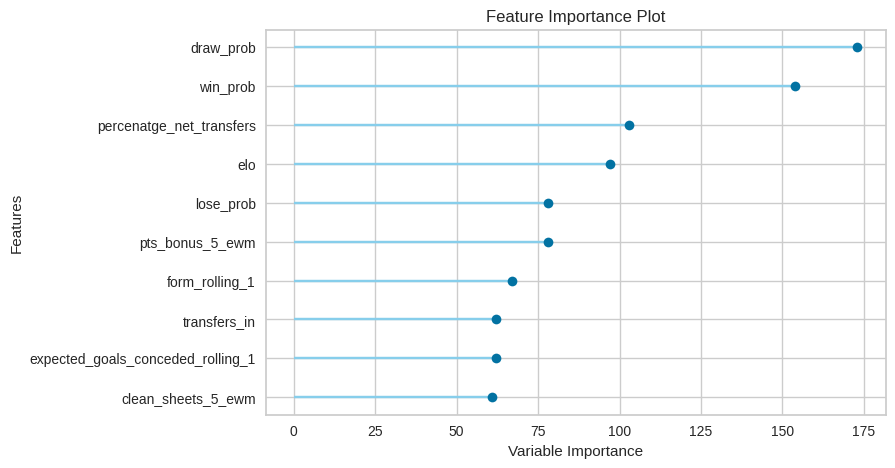

In [27]:
train_data, test_data, player_names, player_ids, test_mask = working_df(data, 4, joint=True)
train_data = train_data.reset_index(drop=True)
base_model_4 = setup(train_data, target = 'xP_25',
                    train_size=0.8,
                    remove_multicollinearity=True,  # Drop collinear features
                    # feature_selection=True,        # Auto-select important features
                    session_id=42,
                    # use_gpu=True


                )
# models()

best_model_4 = base_model_4.compare_models(sort='MAE', n_select=1)
print(best_model_4)

evaluate_model(best_model_4)

plot_model(best_model_4, plot='feature')        # Feature importance


### GW 5


,Description,Value
0,Session id,42
1,Target,xP_25
2,Target type,Regression
3,Original data shape,"(8982, 391)"
4,Transformed data shape,"(8982, 189)"
5,Transformed train set shape,"(7185, 189)"
6,Transformed test set shape,"(1797, 189)"
7,Numeric features,390
8,Preprocess,True
9,Imputation type,simple


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
lightgbm,Light Gradient Boosting Machine,0.9794,1.7848,1.3342,0.6118,0.4073,0.4615,2.3850
xgboost,Extreme Gradient Boosting,0.9931,1.8146,1.3455,0.6052,0.4007,0.4766,2.0570
et,Extra Trees Regressor,1.0131,2.0283,1.4221,0.5594,0.4401,0.4665,10.6370
gbr,Gradient Boosting Regressor,1.0486,2.0775,1.4400,0.5483,0.4458,0.4891,6.0540
br,Bayesian Ridge,1.0666,2.2502,1.4980,0.5111,0.4624,0.4679,1.2500
ridge,Ridge Regression,1.0684,2.2558,1.4999,0.5098,0.4634,0.4611,1.1640
lr,Linear Regression,1.0694,2.2566,1.5002,0.5096,0.4634,0.4616,1.2400
rf,Random Forest Regressor,1.0712,2.2145,1.4860,0.5190,0.4587,0.5019,19.6630
en,Elastic Net,1.2567,2.7968,1.6703,0.3925,0.5073,0.6635,1.2260
omp,Orthogonal Matching Pursuit,1.2751,2.8801,1.6955,0.3743,0.5106,0.6635,1.1570


LGBMRegressor(n_jobs=-1, random_state=42)


interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

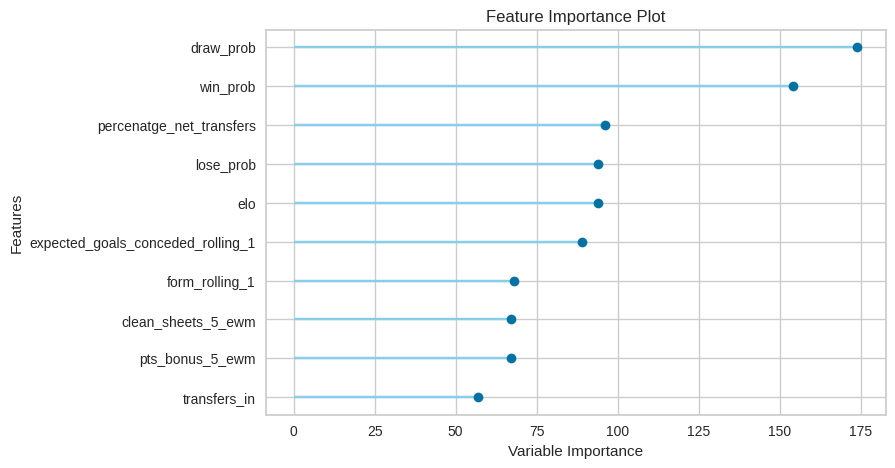

In [28]:
train_data, test_data, player_names, player_ids, test_mask = working_df(data, 5, joint=True)
train_data = train_data.reset_index(drop=True)
base_model_5 = setup(train_data, target = 'xP_25',
                    train_size=0.8,
                    remove_multicollinearity=True,  # Drop collinear features
                    # feature_selection=True,        # Auto-select important features
                    session_id=42,
                    # use_gpu=True


                )
# models()

best_model_5 = base_model_5.compare_models(sort='MAE', n_select=1)
print(best_model_5)

evaluate_model(best_model_5)

plot_model(best_model_5, plot='feature')        # Feature importance


### GW 6


,Description,Value
0,Session id,42
1,Target,xP_25
2,Target type,Regression
3,Original data shape,"(9216, 391)"
4,Transformed data shape,"(9216, 187)"
5,Transformed train set shape,"(7372, 187)"
6,Transformed test set shape,"(1844, 187)"
7,Numeric features,390
8,Preprocess,True
9,Imputation type,simple


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
lightgbm,Light Gradient Boosting Machine,0.9723,1.7541,1.3230,0.6176,0.4045,0.4642,2.4250
xgboost,Extreme Gradient Boosting,0.9945,1.8291,1.3513,0.6005,0.4016,0.4824,2.1860
et,Extra Trees Regressor,0.9982,1.9878,1.4083,0.5667,0.4360,0.4658,11.0160
gbr,Gradient Boosting Regressor,1.0366,2.0361,1.4260,0.5559,0.4404,0.4915,6.0750
rf,Random Forest Regressor,1.0601,2.1797,1.4751,0.5248,0.4535,0.5034,19.8160
br,Bayesian Ridge,1.0652,2.2390,1.4945,0.5120,0.4590,0.4809,1.2750
ridge,Ridge Regression,1.0670,2.2423,1.4955,0.5113,0.4599,0.4754,1.1800
lr,Linear Regression,1.0682,2.2435,1.4959,0.5111,0.4597,0.4764,1.2190
en,Elastic Net,1.2488,2.7840,1.6668,0.3936,0.5026,0.6657,1.2320
omp,Orthogonal Matching Pursuit,1.2686,2.8739,1.6924,0.3738,0.5063,0.6662,1.1790


LGBMRegressor(n_jobs=-1, random_state=42)


interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

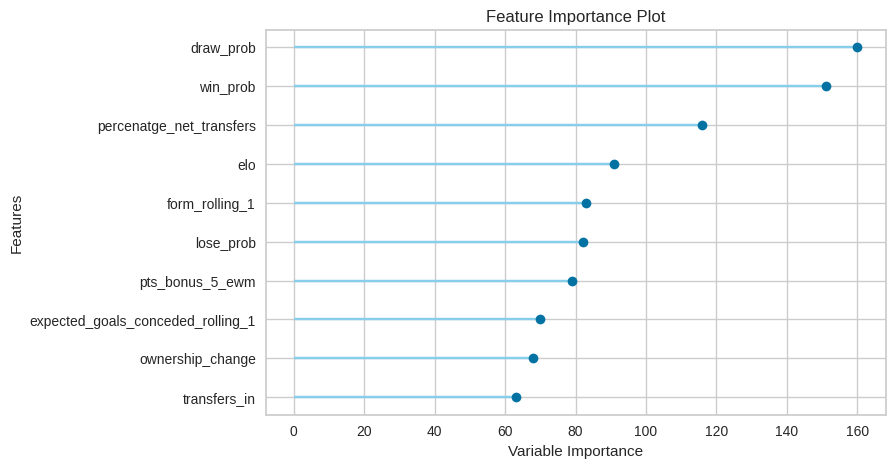

In [29]:
train_data, test_data, player_names, player_ids, test_mask = working_df(data, 6, joint=True)
train_data = train_data.reset_index(drop=True)
base_model_6 = setup(train_data, target = 'xP_25',
                    train_size=0.8,
                    remove_multicollinearity=True,  # Drop collinear features
                    # feature_selection=True,        # Auto-select important features
                    session_id=42,
                    # use_gpu=True


                )
# models()

best_model_6 = base_model_6.compare_models(sort='MAE', n_select=1)
print(best_model_6)

evaluate_model(best_model_6)

plot_model(best_model_6, plot='feature')        # Feature importance


### GW 7


,Description,Value
0,Session id,42
1,Target,xP_25
2,Target type,Regression
3,Original data shape,"(9448, 391)"
4,Transformed data shape,"(9448, 188)"
5,Transformed train set shape,"(7558, 188)"
6,Transformed test set shape,"(1890, 188)"
7,Numeric features,390
8,Preprocess,True
9,Imputation type,simple


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
lightgbm,Light Gradient Boosting Machine,0.9676,1.7512,1.3221,0.6160,0.4040,0.4602,2.3170
xgboost,Extreme Gradient Boosting,0.9818,1.7718,1.3304,0.6112,0.3971,0.4688,2.0750
et,Extra Trees Regressor,0.9885,1.9534,1.3962,0.5717,0.4324,0.4563,11.3510
gbr,Gradient Boosting Regressor,1.0329,2.0261,1.4223,0.5560,0.4403,0.4846,6.1600
rf,Random Forest Regressor,1.0496,2.1321,1.4586,0.5328,0.4488,0.4948,20.2560
br,Bayesian Ridge,1.0569,2.2131,1.4861,0.5150,0.4569,0.4710,1.3050
ridge,Ridge Regression,1.0581,2.2159,1.4871,0.5144,0.4577,0.4632,1.2170
lr,Linear Regression,1.0589,2.2183,1.4879,0.5140,0.4577,0.4639,1.2670
en,Elastic Net,1.2376,2.7516,1.6574,0.3971,0.4992,0.6560,1.2970
omp,Orthogonal Matching Pursuit,1.2860,2.9311,1.7109,0.3574,0.5096,0.6850,1.2040


LGBMRegressor(n_jobs=-1, random_state=42)


interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

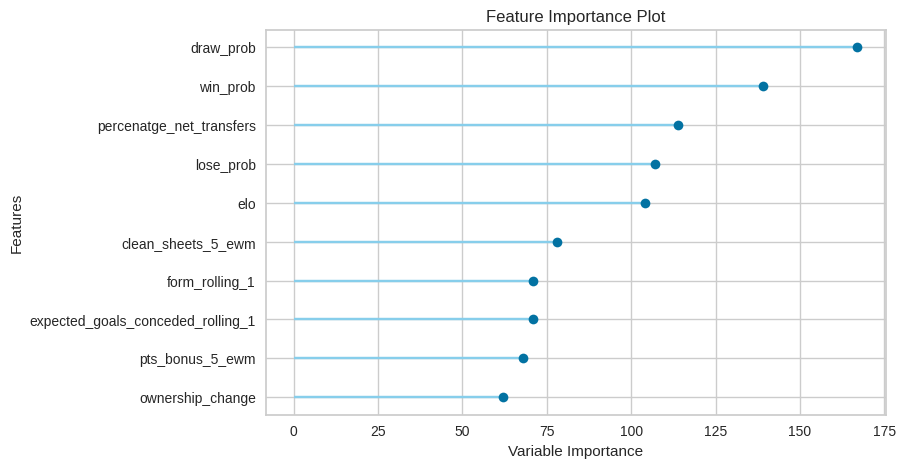

In [30]:
train_data, test_data, player_names, player_ids, test_mask = working_df(data, 7, joint=True)
train_data = train_data.reset_index(drop=True)
base_model_7 = setup(train_data, target = 'xP_25',
                    train_size=0.8,
                    remove_multicollinearity=True,  # Drop collinear features
                    # feature_selection=True,        # Auto-select important features
                    session_id=42,
                    # use_gpu=True


                )
# models()

best_model_7 = base_model_7.compare_models(sort='MAE', n_select=1)
print(best_model_7)

evaluate_model(best_model_7)

plot_model(best_model_7, plot='feature')        # Feature importance


### GW 8


,Description,Value
0,Session id,42
1,Target,xP_25
2,Target type,Regression
3,Original data shape,"(9674, 391)"
4,Transformed data shape,"(9674, 187)"
5,Transformed train set shape,"(7739, 187)"
6,Transformed test set shape,"(1935, 187)"
7,Numeric features,390
8,Preprocess,True
9,Imputation type,simple


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
lightgbm,Light Gradient Boosting Machine,0.9626,1.7485,1.3206,0.6131,0.3996,0.4575,2.5060
xgboost,Extreme Gradient Boosting,0.9823,1.8191,1.3471,0.5976,0.3997,0.4682,2.1120
et,Extra Trees Regressor,0.9909,1.9596,1.3983,0.5669,0.4299,0.4588,11.7570
gbr,Gradient Boosting Regressor,1.0314,2.0286,1.4228,0.5515,0.4362,0.4853,6.3650
rf,Random Forest Regressor,1.0485,2.1351,1.4592,0.5286,0.4468,0.4951,20.8010
br,Bayesian Ridge,1.0495,2.1966,1.4804,0.5146,0.4519,0.4716,1.3310
ridge,Ridge Regression,1.0506,2.1988,1.4810,0.5142,0.4527,0.4647,1.2380
lr,Linear Regression,1.0514,2.2007,1.4816,0.5138,0.4528,0.4656,1.2980
en,Elastic Net,1.2345,2.7297,1.6505,0.3964,0.4964,0.6584,1.3330
omp,Orthogonal Matching Pursuit,1.2819,2.9130,1.7052,0.3555,0.5067,0.6863,1.2420


LGBMRegressor(n_jobs=-1, random_state=42)


interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

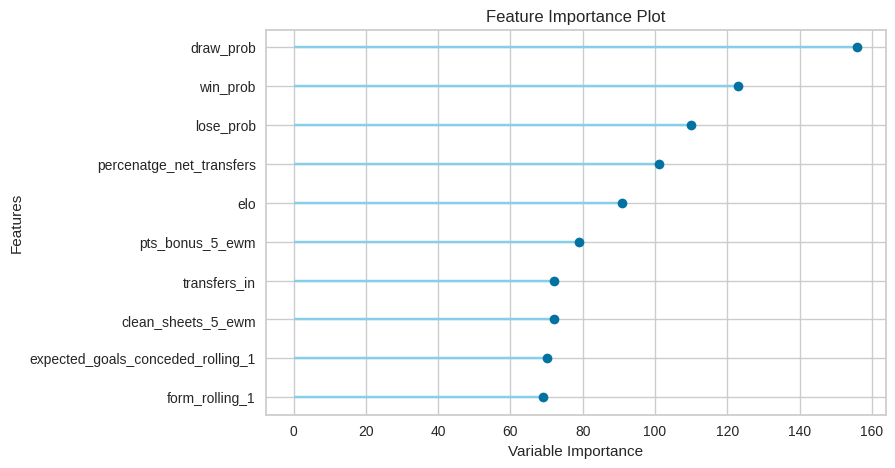

In [31]:
train_data, test_data, player_names, player_ids, test_mask = working_df(data, 8, joint=True)
train_data = train_data.reset_index(drop=True)
base_model_8 = setup(train_data, target = 'xP_25',
                    train_size=0.8,
                    remove_multicollinearity=True,  # Drop collinear features
                    # feature_selection=True,        # Auto-select important features
                    session_id=42,
                    # use_gpu=True


                )
# models()

best_model_8 = base_model_8.compare_models(sort='MAE', n_select=1)
print(best_model_8)

evaluate_model(best_model_8)

plot_model(best_model_8, plot='feature')        # Feature importance


### GW 9


,Description,Value
0,Session id,42
1,Target,xP_25
2,Target type,Regression
3,Original data shape,"(9904, 391)"
4,Transformed data shape,"(9904, 188)"
5,Transformed train set shape,"(7923, 188)"
6,Transformed test set shape,"(1981, 188)"
7,Numeric features,390
8,Preprocess,True
9,Imputation type,simple


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
lightgbm,Light Gradient Boosting Machine,0.9577,1.7066,1.3046,0.6267,0.3960,0.4508,2.6930
xgboost,Extreme Gradient Boosting,0.9705,1.7559,1.3233,0.6157,0.3890,0.4623,2.1850
et,Extra Trees Regressor,0.9823,1.9283,1.3864,0.5786,0.4253,0.4550,12.0820
gbr,Gradient Boosting Regressor,1.0221,1.9832,1.4067,0.5662,0.4327,0.4782,6.5030
rf,Random Forest Regressor,1.0365,2.0812,1.4405,0.5452,0.4413,0.4861,21.4210
br,Bayesian Ridge,1.0408,2.1507,1.4644,0.5301,0.4475,0.4626,1.3600
ridge,Ridge Regression,1.0418,2.1517,1.4646,0.5299,0.4478,0.4555,1.3200
lr,Linear Regression,1.0427,2.1538,1.4653,0.5295,0.4477,0.4563,1.3500
en,Elastic Net,1.2315,2.7141,1.6461,0.4059,0.4943,0.6540,1.3860
omp,Orthogonal Matching Pursuit,1.2759,2.8754,1.6947,0.3702,0.5029,0.6777,1.2850


LGBMRegressor(n_jobs=-1, random_state=42)


interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

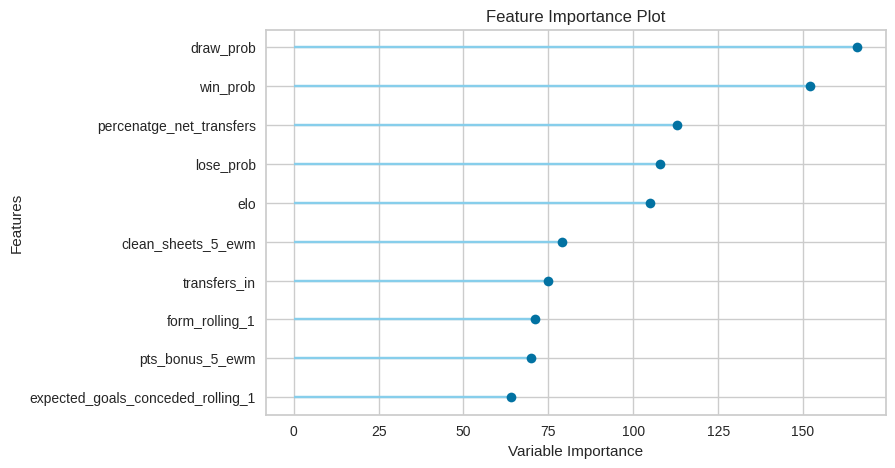

In [32]:
train_data, test_data, player_names, player_ids, test_mask = working_df(data, 9, joint=True)
train_data = train_data.reset_index(drop=True)
base_model_9 = setup(train_data, target = 'xP_25',
                    train_size=0.8,
                    remove_multicollinearity=True,  # Drop collinear features
                    # feature_selection=True,        # Auto-select important features
                    session_id=42,
                    # use_gpu=True


                )
# models()

best_model_9 = base_model_9.compare_models(sort='MAE', n_select=1)
print(best_model_9)

evaluate_model(best_model_9)

plot_model(best_model_9, plot='feature')        # Feature importance


### GW 10


,Description,Value
0,Session id,42
1,Target,xP_25
2,Target type,Regression
3,Original data shape,"(10134, 391)"
4,Transformed data shape,"(10134, 190)"
5,Transformed train set shape,"(8107, 190)"
6,Transformed test set shape,"(2027, 190)"
7,Numeric features,390
8,Preprocess,True
9,Imputation type,simple


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
lightgbm,Light Gradient Boosting Machine,0.9617,1.7340,1.3156,0.6138,0.3980,0.4514,2.7430
xgboost,Extreme Gradient Boosting,0.9696,1.7665,1.3280,0.6066,0.3928,0.4662,2.3560
et,Extra Trees Regressor,0.9868,1.9521,1.3956,0.5655,0.4278,0.4546,12.7020
gbr,Gradient Boosting Regressor,1.0238,2.0100,1.4168,0.5523,0.4337,0.4767,6.6940
rf,Random Forest Regressor,1.0395,2.1248,1.4559,0.5272,0.4433,0.4874,22.3400
br,Bayesian Ridge,1.0462,2.1789,1.4749,0.5153,0.4498,0.4628,1.4270
ridge,Ridge Regression,1.0473,2.1832,1.4764,0.5143,0.4506,0.4550,1.3270
lr,Linear Regression,1.0476,2.1850,1.4770,0.5140,0.4506,0.4555,1.4120
en,Elastic Net,1.2311,2.7167,1.6471,0.3957,0.4943,0.6483,1.4340
omp,Orthogonal Matching Pursuit,1.2663,2.8473,1.6862,0.3668,0.5013,0.6654,1.3160


LGBMRegressor(n_jobs=-1, random_state=42)


interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

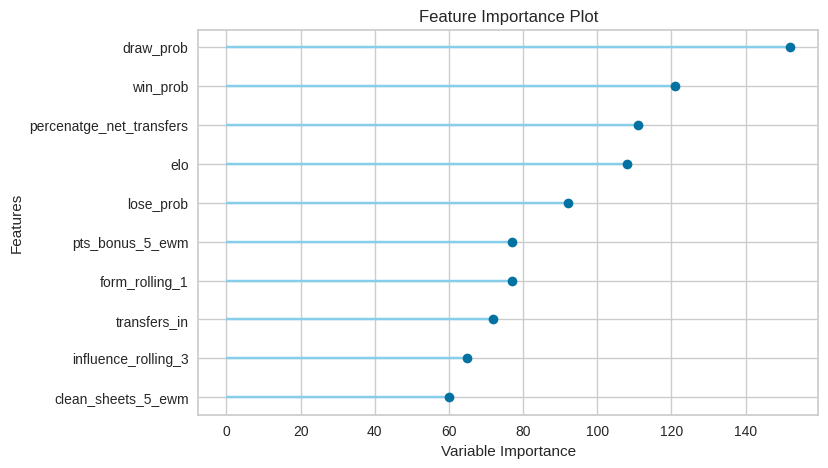

In [33]:
train_data, test_data, player_names, player_ids, test_mask = working_df(data, 10, joint=True)
train_data = train_data.reset_index(drop=True)
base_model_10 = setup(train_data, target = 'xP_25',
                    train_size=0.8,
                    remove_multicollinearity=True,  # Drop collinear features
                    # feature_selection=True,        # Auto-select important features
                    session_id=42,
                    # use_gpu=True


                )
# models()

best_model_10 = base_model_10.compare_models(sort='MAE', n_select=1)
print(best_model_10)

evaluate_model(best_model_10)

plot_model(best_model_10, plot='feature')        # Feature importance


### GW 11


,Description,Value
0,Session id,42
1,Target,xP_25
2,Target type,Regression
3,Original data shape,"(10370, 391)"
4,Transformed data shape,"(10370, 189)"
5,Transformed train set shape,"(8296, 189)"
6,Transformed test set shape,"(2074, 189)"
7,Numeric features,390
8,Preprocess,True
9,Imputation type,simple


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
lightgbm,Light Gradient Boosting Machine,0.9557,1.7461,1.3196,0.6124,0.3967,0.4445,2.5670
xgboost,Extreme Gradient Boosting,0.9705,1.7745,1.3309,0.6063,0.3898,0.4604,2.3460
et,Extra Trees Regressor,0.9827,1.9419,1.3921,0.5695,0.4227,0.4555,12.9680
gbr,Gradient Boosting Regressor,1.0189,1.9971,1.4123,0.5571,0.4298,0.4727,6.9380
rf,Random Forest Regressor,1.0355,2.1078,1.4502,0.5331,0.4393,0.4841,23.0580
br,Bayesian Ridge,1.0390,2.1595,1.4680,0.5219,0.4456,0.4576,1.4320
ridge,Ridge Regression,1.0393,2.1616,1.4687,0.5215,0.4462,0.4498,1.3060
lr,Linear Regression,1.0403,2.1644,1.4697,0.5209,0.4462,0.4507,1.3920
en,Elastic Net,1.2296,2.7125,1.6459,0.3990,0.4911,0.6437,1.4130
omp,Orthogonal Matching Pursuit,1.2549,2.8214,1.6781,0.3742,0.4962,0.6542,1.3160


LGBMRegressor(n_jobs=-1, random_state=42)


interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

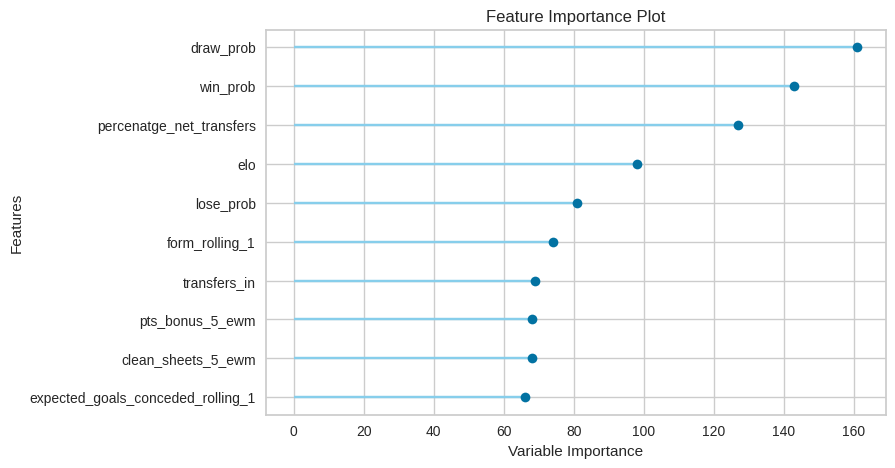

In [34]:
train_data, test_data, player_names, player_ids, test_mask = working_df(data, 11, joint=True)
train_data = train_data.reset_index(drop=True)
base_model_11 = setup(train_data, target = 'xP_25',
                    train_size=0.8,
                    remove_multicollinearity=True,  # Drop collinear features
                    # feature_selection=True,        # Auto-select important features
                    session_id=42,
                    # use_gpu=True


                )
# models()

best_model_11 = base_model_11.compare_models(sort='MAE', n_select=1)
print(best_model_11)

evaluate_model(best_model_11)

plot_model(best_model_11, plot='feature')        # Feature importance


### GW 12


,Description,Value
0,Session id,42
1,Target,xP_25
2,Target type,Regression
3,Original data shape,"(10593, 391)"
4,Transformed data shape,"(10593, 189)"
5,Transformed train set shape,"(8474, 189)"
6,Transformed test set shape,"(2119, 189)"
7,Numeric features,390
8,Preprocess,True
9,Imputation type,simple


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
lightgbm,Light Gradient Boosting Machine,0.9438,1.6736,1.2921,0.6259,0.3912,0.4463,2.6830
xgboost,Extreme Gradient Boosting,0.9630,1.7251,1.3123,0.6137,0.3886,0.4662,2.4310
et,Extra Trees Regressor,0.9715,1.8714,1.3664,0.5814,0.4179,0.4534,13.2910
gbr,Gradient Boosting Regressor,1.0058,1.9338,1.3895,0.5673,0.4245,0.4753,7.0620
rf,Random Forest Regressor,1.0199,2.0189,1.4192,0.5489,0.4331,0.4817,23.3420
br,Bayesian Ridge,1.0256,2.0833,1.4417,0.5341,0.4400,0.4576,1.4490
ridge,Ridge Regression,1.0257,2.0818,1.4411,0.5344,0.4404,0.4510,1.3600
lr,Linear Regression,1.0264,2.0830,1.4415,0.5341,0.4403,0.4517,1.3990
en,Elastic Net,1.2176,2.6334,1.6213,0.4112,0.4861,0.6454,1.4340
omp,Orthogonal Matching Pursuit,1.2655,2.8039,1.6734,0.3727,0.4957,0.6716,1.3510


LGBMRegressor(n_jobs=-1, random_state=42)


interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

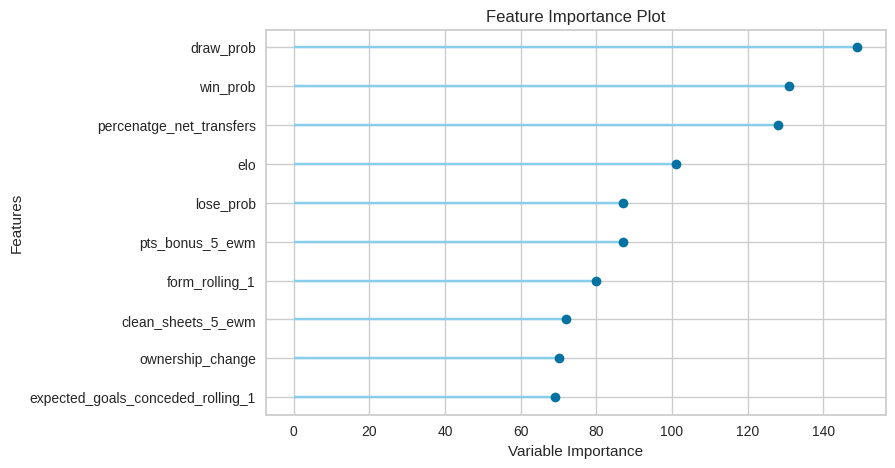

In [35]:
train_data, test_data, player_names, player_ids, test_mask = working_df(data, 12, joint=True)
train_data = train_data.reset_index(drop=True)
base_model_12 = setup(train_data, target = 'xP_25',
                    train_size=0.8,
                    remove_multicollinearity=True,  # Drop collinear features
                    # feature_selection=True,        # Auto-select important features
                    session_id=42,
                    # use_gpu=True


                )
# models()

best_model_12 = base_model_12.compare_models(sort='MAE', n_select=1)
print(best_model_12)

evaluate_model(best_model_12)

plot_model(best_model_12, plot='feature')        # Feature importance


### GW 13


,Description,Value
0,Session id,42
1,Target,xP_25
2,Target type,Regression
3,Original data shape,"(10813, 391)"
4,Transformed data shape,"(10813, 188)"
5,Transformed train set shape,"(8650, 188)"
6,Transformed test set shape,"(2163, 188)"
7,Numeric features,390
8,Preprocess,True
9,Imputation type,simple


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
lightgbm,Light Gradient Boosting Machine,0.9482,1.6793,1.2944,0.6270,0.3889,0.4443,2.6520
xgboost,Extreme Gradient Boosting,0.9598,1.7173,1.3091,0.6181,0.3843,0.4524,2.4250
et,Extra Trees Regressor,0.9708,1.8811,1.3700,0.5820,0.4170,0.4443,13.6600
gbr,Gradient Boosting Regressor,1.0143,1.9497,1.3952,0.5666,0.4239,0.4711,7.2820
rf,Random Forest Regressor,1.0259,2.0444,1.4280,0.5458,0.4333,0.4781,23.9180
br,Bayesian Ridge,1.0302,2.0844,1.4418,0.5373,0.4384,0.4557,1.4730
ridge,Ridge Regression,1.0322,2.0868,1.4426,0.5367,0.4390,0.4503,1.3670
lr,Linear Regression,1.0328,2.0886,1.4433,0.5363,0.4389,0.4506,1.4270
en,Elastic Net,1.2178,2.6354,1.6218,0.4145,0.4839,0.6364,1.4700
omp,Orthogonal Matching Pursuit,1.2523,2.7617,1.6600,0.3861,0.4909,0.6492,1.3710


LGBMRegressor(n_jobs=-1, random_state=42)


interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

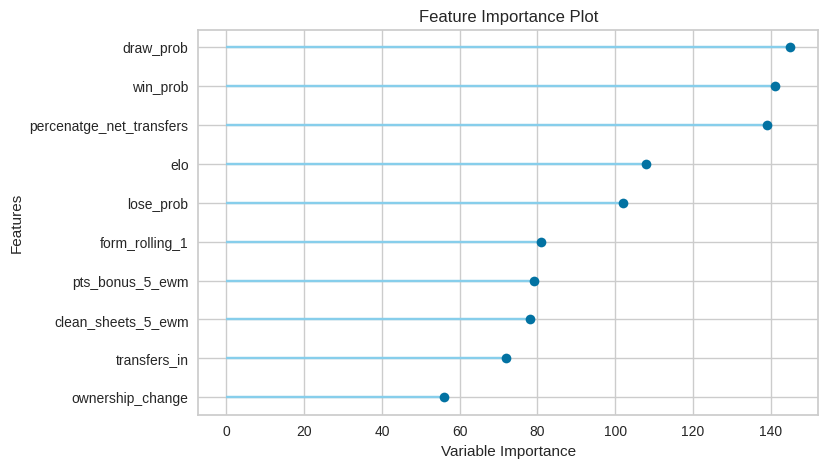

In [36]:
train_data, test_data, player_names, player_ids, test_mask = working_df(data, 13, joint=True)
train_data = train_data.reset_index(drop=True)
base_model_13 = setup(train_data, target = 'xP_25',
                    train_size=0.8,
                    remove_multicollinearity=True,  # Drop collinear features
                    # feature_selection=True,        # Auto-select important features
                    session_id=42,
                    # use_gpu=True


                )
# models()

best_model_13 = base_model_13.compare_models(sort='MAE', n_select=1)
print(best_model_13)

evaluate_model(best_model_13)

plot_model(best_model_13, plot='feature')        # Feature importance


### GW 14


,Description,Value
0,Session id,42
1,Target,xP_25
2,Target type,Regression
3,Original data shape,"(11027, 391)"
4,Transformed data shape,"(11027, 189)"
5,Transformed train set shape,"(8821, 189)"
6,Transformed test set shape,"(2206, 189)"
7,Numeric features,390
8,Preprocess,True
9,Imputation type,simple


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
lightgbm,Light Gradient Boosting Machine,0.9498,1.6952,1.3000,0.6224,0.3899,0.4426,2.6380
xgboost,Extreme Gradient Boosting,0.9628,1.7133,1.3071,0.6184,0.3827,0.4546,2.3610
et,Extra Trees Regressor,0.9806,1.9037,1.3774,0.5763,0.4162,0.4506,14.1220
gbr,Gradient Boosting Regressor,1.0101,1.9438,1.3926,0.5671,0.4222,0.4675,7.5170
br,Bayesian Ridge,1.0261,2.0863,1.4422,0.5357,0.4356,0.4516,1.5170
ridge,Ridge Regression,1.0279,2.0897,1.4433,0.5350,0.4364,0.4456,1.3980
lr,Linear Regression,1.0285,2.0909,1.4437,0.5347,0.4362,0.4467,1.4450
rf,Random Forest Regressor,1.0318,2.0663,1.4354,0.5400,0.4322,0.4795,25.0680
en,Elastic Net,1.2168,2.6445,1.6246,0.4111,0.4825,0.6368,1.4910
omp,Orthogonal Matching Pursuit,1.2675,2.8264,1.6794,0.3710,0.4927,0.6641,1.3720


LGBMRegressor(n_jobs=-1, random_state=42)


interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

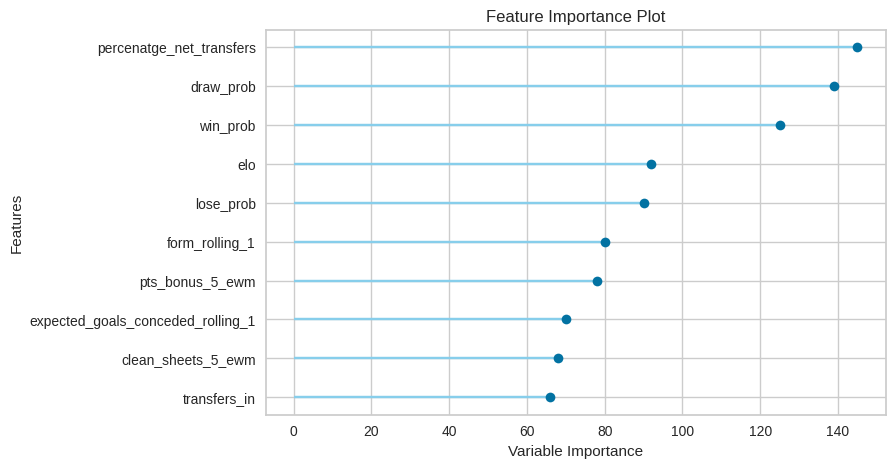

In [37]:
train_data, test_data, player_names, player_ids, test_mask = working_df(data, 14, joint=True)
train_data = train_data.reset_index(drop=True)
base_model_14 = setup(train_data, target = 'xP_25',
                    train_size=0.8,
                    remove_multicollinearity=True,  # Drop collinear features
                    # feature_selection=True,        # Auto-select important features
                    session_id=42,
                    # use_gpu=True


                )
# models()

best_model_14 = base_model_14.compare_models(sort='MAE', n_select=1)
print(best_model_14)

evaluate_model(best_model_14)

plot_model(best_model_14, plot='feature')        # Feature importance


### GW 15


,Description,Value
0,Session id,42
1,Target,xP_25
2,Target type,Regression
3,Original data shape,"(11263, 391)"
4,Transformed data shape,"(11263, 188)"
5,Transformed train set shape,"(9010, 188)"
6,Transformed test set shape,"(2253, 188)"
7,Numeric features,390
8,Preprocess,True
9,Imputation type,simple


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
lightgbm,Light Gradient Boosting Machine,0.9409,1.6611,1.2873,0.6262,0.3864,0.4407,2.8670
xgboost,Extreme Gradient Boosting,0.9557,1.6936,1.2995,0.6186,0.3822,0.4594,2.3810
et,Extra Trees Regressor,0.9696,1.8777,1.3686,0.5776,0.4134,0.4508,14.3400
gbr,Gradient Boosting Regressor,1.0036,1.9192,1.3841,0.5679,0.4186,0.4709,7.5650
br,Bayesian Ridge,1.0195,2.0568,1.4325,0.5374,0.4324,0.4526,1.5290
ridge,Ridge Regression,1.0218,2.0590,1.4332,0.5369,0.4331,0.4476,1.4140
lr,Linear Regression,1.0222,2.0605,1.4337,0.5366,0.4332,0.4478,1.4740
rf,Random Forest Regressor,1.0228,2.0223,1.4202,0.5452,0.4288,0.4844,25.1130
en,Elastic Net,1.2110,2.6186,1.6166,0.4110,0.4795,0.6392,1.5470
omp,Orthogonal Matching Pursuit,1.2598,2.8007,1.6721,0.3698,0.4901,0.6696,1.4200


LGBMRegressor(n_jobs=-1, random_state=42)


interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

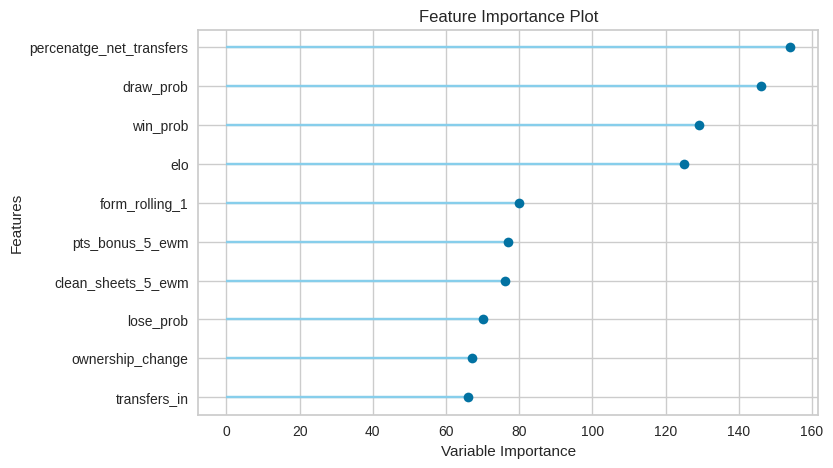

In [38]:
train_data, test_data, player_names, player_ids, test_mask = working_df(data, 15, joint=True)
train_data = train_data.reset_index(drop=True)
base_model_15 = setup(train_data, target = 'xP_25',
                    train_size=0.8,
                    remove_multicollinearity=True,  # Drop collinear features
                    # feature_selection=True,        # Auto-select important features
                    session_id=42,
                    # use_gpu=True


                )
# models()

best_model_15 = base_model_15.compare_models(sort='MAE', n_select=1)
print(best_model_15)

evaluate_model(best_model_15)

plot_model(best_model_15, plot='feature')        # Feature importance


### GW 16


,Description,Value
0,Session id,42
1,Target,xP_25
2,Target type,Regression
3,Original data shape,"(11493, 391)"
4,Transformed data shape,"(11493, 188)"
5,Transformed train set shape,"(9194, 188)"
6,Transformed test set shape,"(2299, 188)"
7,Numeric features,390
8,Preprocess,True
9,Imputation type,simple


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
lightgbm,Light Gradient Boosting Machine,0.9340,1.6487,1.2824,0.6271,0.3833,0.4361,2.8320
xgboost,Extreme Gradient Boosting,0.9551,1.7074,1.3057,0.6132,0.3812,0.4512,2.4190
et,Extra Trees Regressor,0.9596,1.8495,1.3582,0.5817,0.4116,0.4412,14.8280
gbr,Gradient Boosting Regressor,0.9922,1.8847,1.3717,0.5737,0.4146,0.4629,7.8530
br,Bayesian Ridge,1.0081,2.0271,1.4221,0.5416,0.4282,0.4469,1.5800
rf,Random Forest Regressor,1.0084,2.0088,1.4156,0.5458,0.4261,0.4649,26.2490
ridge,Ridge Regression,1.0100,2.0298,1.4229,0.5410,0.4287,0.4419,1.4490
lr,Linear Regression,1.0107,2.0320,1.4237,0.5405,0.4287,0.4423,1.4900
en,Elastic Net,1.2021,2.5885,1.6077,0.4144,0.4752,0.6292,1.5870
omp,Orthogonal Matching Pursuit,1.2445,2.7512,1.6576,0.3771,0.4837,0.6484,1.4500


LGBMRegressor(n_jobs=-1, random_state=42)


interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

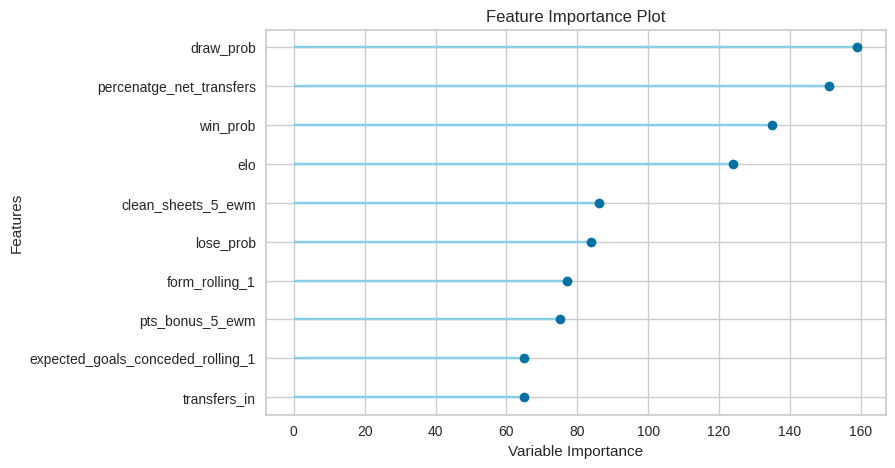

In [39]:
train_data, test_data, player_names, player_ids, test_mask = working_df(data, 16, joint=True)
train_data = train_data.reset_index(drop=True)
base_model_16 = setup(train_data, target = 'xP_25',
                    train_size=0.8,
                    remove_multicollinearity=True,  # Drop collinear features
                    # feature_selection=True,        # Auto-select important features
                    session_id=42,
                    # use_gpu=True


                )
# models()

best_model_16 = base_model_16.compare_models(sort='MAE', n_select=1)
print(best_model_16)

evaluate_model(best_model_16)

plot_model(best_model_16, plot='feature')        # Feature importance


## Feature Importance


In [40]:

def select_best_features(df, features):
    """
    Ranks features using LightGBM feature importance.
    Tree models naturally calculate which features reduce variance the most.
    """
    reliable_df = df[df['round'] >= 6].copy()

    X = reliable_df[features]
    y = reliable_df['xP_25']

    # Use default params for ranking
    model = LGBMRegressor(n_estimators=100, random_state=42, verbose=-1)
    model.fit(X, y)

    importances = pd.DataFrame({
        'Feature': features,
        'Importance': model.feature_importances_
    }).sort_values(by='Importance', ascending=False)

    # Add a 'Rank' column to match the previous structure
    importances['Rank'] = range(1, len(importances) + 1)
    return importances

def run_reliability_test(train_df, test_df, selected_features):
    """
    Simulates the season using only the selected features.
    """
    gws = sorted(train_df['round'].unique())
    results = []

    scaler = StandardScaler()

    # Hyperparameters to tune: Learning Rate and Complexity (num_leaves)
    learning_rates = [0.01, 0.05, 0.1]
    num_leaves_list = [15, 31, 63]

    best_gw_mae = float('inf')
    best_lr = 0.1
    best_leaves = 31

    # train_df = df[df['round'] < round]
    # test_df = df[df['round'] == round]

    X_train = scaler.fit_transform(train_df[selected_features])
    X_test = scaler.transform(test_df[selected_features])

    for lr in learning_rates:
        for leaves in num_leaves_list:
            val_model = LGBMRegressor(
                learning_rate=lr,
                num_leaves=leaves,
                n_estimators=100,
                random_state=42,
                verbose=-1
            )

            val_model.fit(X_train, train_df['xP_25'])
            v_mae = mean_absolute_error(test_df['xP_25'], val_model.predict(X_test))

            if v_mae < best_gw_mae:
                best_gw_mae = v_mae
                best_lr = lr
                best_leaves = leaves

    results.append({'GW': round, 'MAE': best_gw_mae, 'lr': best_lr, 'leaves': best_leaves})

    return pd.DataFrame(results)

def get_gw_best_features(data, round):
    print(f"Step 1: Ranking Features for GW {round} using Recursive Feature Elimination...")
    data_24 = data[data['season'] == 2024]
    data_25 = data[data['season'] == 2025]

    GW_full = data_25['round'].values

    # Split
    GW_TRAIN_END = round - 1
    train_mask = GW_full <= GW_TRAIN_END
    test_mask = GW_full == (GW_TRAIN_END + 1)

    train_data = data_25[train_mask]
    test_df = data_25[test_mask]

    train_df = pd.concat([data_24, train_data])

    # train_df = data[data['round'] < round]
    # test_df = data[data['round'] == round]

    feature_ranks = select_best_features(train_df,  feature_cols)

    # # Step 2: Automated Selection
    print(f"\nStep 2: Finding Optimal Feature Cut-off. of the {len(feature_cols)} features..")

    # We iterate through the top N features to find where MAE stops improving
    best_overall_mae = float('inf')
    best_overall_lr = 1
    best_overall_leaves = 31
    optimal_count = 1

    # Testing up to top 10 (or however many you want to check)
    search_limit = min(len(feature_cols), 50)


    for i in range(1, search_limit + 1):
        trial_features = feature_ranks.head(i)['Feature'].tolist()
        reliability_df = run_reliability_test(train_df, test_df, trial_features)


        avg_mae = reliability_df['MAE'].mean()
        avg_lr = reliability_df['lr'].mean()
        avg_leaves = reliability_df['leaves'].mean()


        print(f"Testing top {i} features: Average MAE = {avg_mae:.4f}")

        if avg_mae < best_overall_mae:
            best_overall_mae = avg_mae
            best_overall_lr = avg_lr
            best_overall_leaves = avg_leaves
            optimal_count = i


    # Final Prediction for the actual Deadline


    chosen_features = feature_ranks.head(optimal_count)['Feature'].tolist()

    final_model = LGBMRegressor(
        learning_rate=best_overall_lr,
        num_leaves=np.int64(best_overall_leaves),
        n_estimators=100,
        random_state=42,
        verbose=-1
    )
    print(best_overall_leaves, best_overall_lr)
    final_model.fit(train_df[chosen_features], train_df['xP_25'])
    actual_mae = mean_absolute_error(test_df['xP_25'], final_model.predict(test_df[chosen_features]))

    print(f"GW {round}: Used {len(chosen_features)} features. MAE: {actual_mae:.4f}")
    print(f"\nOptimal number of features: {optimal_count}")
    print(f"Selected Features: {round}==> {chosen_features}")

    return chosen_features, optimal_count, actual_mae, best_overall_lr, best_overall_leaves



In [41]:
selected_features_24_25 = {}
for round in range(1,24):
    selected_features_24_25[round] = get_gw_best_features(data, round)



Step 1: Ranking Features for GW 1 using Recursive Feature Elimination...

Step 2: Finding Optimal Feature Cut-off. of the 383 features..
Testing top 1 features: Average MAE = 1.6175
Testing top 2 features: Average MAE = 1.6070
Testing top 3 features: Average MAE = 1.5971
Testing top 4 features: Average MAE = 1.5847
Testing top 5 features: Average MAE = 1.5468
Testing top 6 features: Average MAE = 1.4694
Testing top 7 features: Average MAE = 1.4652
Testing top 8 features: Average MAE = 1.4694
Testing top 9 features: Average MAE = 1.6556
Testing top 10 features: Average MAE = 1.6529
Testing top 11 features: Average MAE = 1.5711
Testing top 12 features: Average MAE = 1.5763
Testing top 13 features: Average MAE = 1.5173
Testing top 14 features: Average MAE = 1.5027
Testing top 15 features: Average MAE = 1.5077
Testing top 16 features: Average MAE = 1.5057
Testing top 17 features: Average MAE = 1.5014
Testing top 18 features: Average MAE = 1.4985
Testing top 19 features: Average MAE = 1.496

In [42]:
selections_24_25 = pd.DataFrame(selected_features_24_25).T
selections_24_25.columns = ['best_features', 'optimal_count', 'best_overall_mae', 'best_lr', 'best_leaves']
selections_24_25

,best_features,optimal_count,best_overall_mae,best_lr,best_leaves
1,"[draw_prob, win_prob, lose_prob, elo, xP_rolli...",7,1.466275,0.01,31.0
2,"[draw_prob, win_prob, lose_prob, elo, xP_rolli...",50,1.45304,0.1,31.0
3,"[draw_prob, win_prob, lose_prob, elo, xP_rolli...",11,0.832033,0.05,15.0
4,"[draw_prob, win_prob, lose_prob, elo, xP_rolli...",23,0.752499,0.1,31.0
5,"[draw_prob, win_prob, lose_prob, elo, xP_rolli...",18,0.660114,0.05,31.0
6,"[draw_prob, win_prob, lose_prob, elo, xP_rolli...",42,0.914248,0.1,63.0
7,"[draw_prob, win_prob, lose_prob, elo, percenat...",11,0.665653,0.1,15.0
8,"[draw_prob, win_prob, lose_prob, elo, xP_rolli...",43,0.953405,0.1,31.0
9,"[draw_prob, win_prob, lose_prob, elo, percenat...",11,0.636587,0.05,15.0
10,"[draw_prob, win_prob, lose_prob, percenatge_ne...",18,0.758242,0.1,15.0


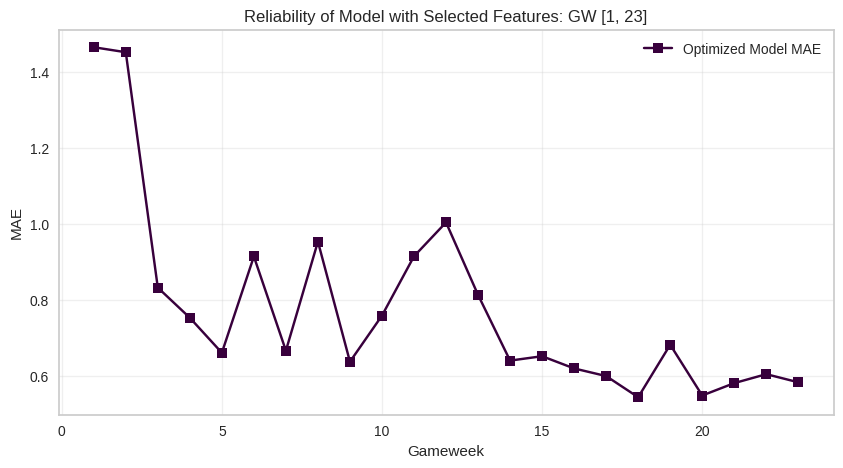

In [43]:

# --- Visualization ---
plt.figure(figsize=(10, 5))
plt.plot(selections_24_25.index, selections_24_25['best_overall_mae'], marker='s', color="#38003c", label='Optimized Model MAE')
plt.title('Reliability of Model with Selected Features: GW [1, 23]', fontsize=12)
plt.xlabel('Gameweek')
plt.ylabel('MAE')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


### AffinePNN


#### Preds


joint
Data prepared. X shape: (13518, 4), M shape: (13518, 9), Y shape: (13518, 2)

Starting Training...
Epoch 1/100


2026-02-26 02:59:15.818897: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_16}}


199/199 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.4902 - mae: 0.2206 - mse: 0.0758 - val_loss: 0.4371 - val_mae: 0.2242 - val_mse: 0.0574 - learning_rate: 1.0000e-04
Epoch 2/100
199/199 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3541 - mae: 0.0815 - mse: 0.0111 - val_loss: 0.3205 - val_mae: 0.1024 - val_mse: 0.0143 - learning_rate: 1.0000e-04
Epoch 3/100
199/199 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2806 - mae: 0.0676 - mse: 0.0077 - val_loss: 0.2468 - val_mae: 0.0614 - val_mse: 0.0060 - learning_rate: 1.0000e-04
Epoch 4/100
199/199 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2196 - mae: 0.0645 - mse: 0.0070 - val_loss: 0.1907 - val_mae: 0.0539 - val_mse: 0.0048 - learning_rate: 1.0000e-04
Epoch 5/100
199/199 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1693 - mae: 0.0615 - mse: 0.0064 - val_loss: 0.1458 - val_mae: 0.0524 - val_mse: 0.0046 - learning_rate: 1.0000e-04
Epoch 6/100
199/199 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1288 - mae: 0.0594 - mse: 0.0060 - val_loss: 0.1101 - 

2026-02-26 02:59:45.321576: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_16}}


12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step

Generating Predictions...
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
{'fpl_name': array(['Schär', 'Joelinton', 'Leno', 'Xhaka', 'Wilson', 'Iwobi',
       'Welbeck', 'Stones', 'Henderson', 'Trippier', 'Gana', 'Grealish',
       'Pickford', 'Smith', 'Virgil', 'Ward-Prowse', 'Adama', 'Gomez',
       'Shaw', 'Cullen', 'B.Fernandes', 'M.Salah', 'A.Becker', 'Lukić',
       'Keane', 'Tarkowski', 'Robertson', 'Bowen', 'Digne', 'Lerma',
       'Casemiro', 'Ødegaard', 'Bernardo', 'Raúl', 'Bruun Larsen', 'Pope',
       'Rice', 'Wan-Bissaka', 'Wilson', 'Sarr', 'Sangaré', 'Mateta',
       'Kamara', 'Tielemans', 'Tete', 'Richarlison', 'Dunk', 'Füllkrug',
       'Hughes', 'Bentancur', 'Milenković', 'Andersen', 'Konaté',
       'Ampadu', 'Rodon', 'Neto', 'Hudson-Odoi', 'Dúbravka', 'Mbeumo',
       'Chalobah', 'C.Jones', 'Aït-Nouri', 'Barnes', 'Todibo', 'Brooks',
       'Cairney', 'Doherty', 'Gibbs-White', 'Saliba', 'Sels',
       'Pedro Porro', 'Georginio', 'Cunha'

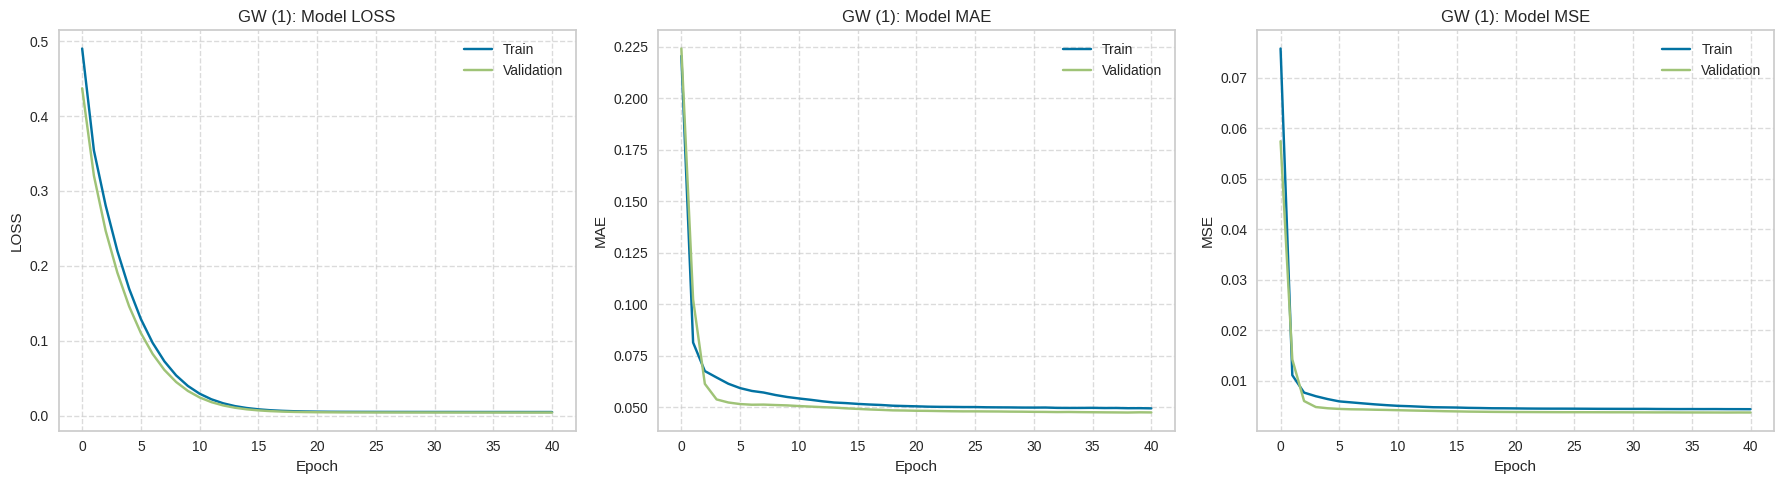

joint
Data prepared. X shape: (13518, 47), M shape: (13518, 9), Y shape: (13518, 2)

Starting Training...
Epoch 1/100
209/209 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.5515 - mae: 0.1368 - mse: 0.0341 - val_loss: 0.4734 - val_mae: 0.0828 - val_mse: 0.0111 - learning_rate: 1.0000e-04
Epoch 2/100
209/209 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4179 - mae: 0.0707 - mse: 0.0087 - val_loss: 0.3641 - val_mae: 0.0617 - val_mse: 0.0065 - learning_rate: 1.0000e-04
Epoch 3/100
209/209 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3195 - mae: 0.0624 - mse: 0.0069 - val_loss: 0.2753 - val_mae: 0.0558 - val_mse: 0.0053 - learning_rate: 1.0000e-04
Epoch 4/100
209/209 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2396 - mae: 0.0571 - mse: 0.0058 - val_loss: 0.2046 - val_mae: 0.0526 - val_mse: 0.0048 - learning_rate: 1.0000e-04
Epoch 5/100
209/209 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1768 - mae: 0.0539 - mse: 0.0052 - val_loss: 0.1496 - val_mae: 0.0502 - val_mse: 0.0044 - learning_rate: 1.0000e-04

2026-02-26 03:00:10.355256: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_16}}


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step

Generating Predictions...
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
{'fpl_name': array(['Schär', 'Joelinton', 'Leno', 'Xhaka', 'Wilson', 'Iwobi',
       'Welbeck', 'Stones', 'Trippier', 'Gana', 'Aina', 'Pickford',
       'Smith', 'Virgil', 'Ward-Prowse', 'Shaw', 'Cullen', 'B.Fernandes',
       'M.Salah', 'A.Becker', 'Lukić', 'Keane', 'Tarkowski', 'Bowen',
       'Digne', 'Casemiro', 'Ødegaard', 'Bernardo', 'Raúl', 'Martinez',
       'Wood', 'Pope', 'Rice', 'Wan-Bissaka', 'Tosin', 'Wilson', 'Sarr',
       'Sangaré', 'Mateta', 'Tielemans', 'Tete', 'Richarlison', 'Dunk',
       'Füllkrug', 'Hughes', 'Bentancur', 'Milenković', 'Pau', 'Andersen',
       'Konaté', 'Rodon', 'Neto', 'Hudson-Odoi', 'Dúbravka', 'Mbeumo',
       'Chalobah', 'C.Jones', 'Aït-Nouri', 'Barnes', 'McNeil', 'Todibo',
       'Brooks', 'Doherty', 'Gibbs-White', 'Saliba', 'Sels',
       'Pedro Porro', 'Cunha', 'Cucurella', 'Romero', 'Smith Rowe',
       'Gyökeres', 'Diakité', 'Dalot', 'Sa

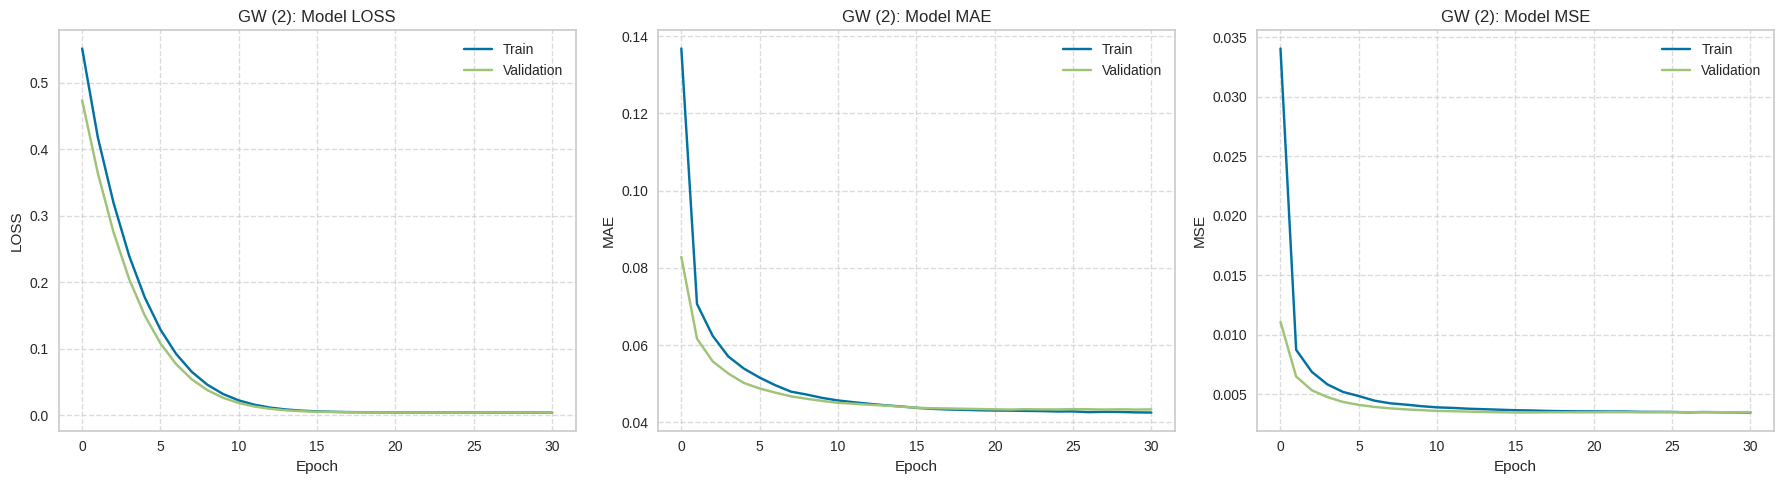

joint
Data prepared. X shape: (13518, 8), M shape: (13518, 9), Y shape: (13518, 2)

Starting Training...
Epoch 1/100
214/214 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.4737 - mae: 0.1410 - mse: 0.0349 - val_loss: 0.4125 - val_mae: 0.1219 - val_mse: 0.0211 - learning_rate: 1.0000e-04
Epoch 2/100
214/214 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3536 - mae: 0.0715 - mse: 0.0087 - val_loss: 0.3092 - val_mae: 0.0722 - val_mse: 0.0092 - learning_rate: 1.0000e-04
Epoch 3/100
214/214 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2676 - mae: 0.0615 - mse: 0.0066 - val_loss: 0.2310 - val_mae: 0.0613 - val_mse: 0.0069 - learning_rate: 1.0000e-04
Epoch 4/100
214/214 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1988 - mae: 0.0576 - mse: 0.0057 - val_loss: 0.1699 - val_mae: 0.0576 - val_mse: 0.0059 - learning_rate: 1.0000e-04
Epoch 5/100
214/214 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1452 - mae: 0.0543 - mse: 0.0052 - val_loss: 0.1231 - val_mae: 0.0556 - val_mse: 0.0053 - learning_rate: 1.0000e-04


2026-02-26 03:00:35.640286: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_16}}


8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step

Generating Predictions...
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
{'fpl_name': array(['Schär', 'Leno', 'Xhaka', 'Wilson', 'Iwobi', 'Welbeck', 'Stones',
       'Henderson', 'Walker', 'Trippier', 'Gana', 'Grealish', 'Aina',
       'Pickford', 'Smith', 'Virgil', 'Ward-Prowse', 'Shaw', 'Cullen',
       'Mings', 'B.Fernandes', 'M.Salah', 'A.Becker', 'Lukić', 'Keane',
       'Tarkowski', 'Bowen', 'Lerma', 'Buendía', 'Casemiro', 'Ødegaard',
       'Bernardo', 'Raúl', 'Wood', 'Merino', 'Bruun Larsen', 'Pope',
       'Rice', 'Tosin', 'James', 'Wilson', 'Gabriel', 'Sarr', 'Sangaré',
       'Mateta', 'Tielemans', 'Tete', 'Richarlison', 'Dunk', 'J.Murphy',
       'Füllkrug', 'Hughes', 'Bentancur', 'Kamada', 'Castagne',
       'Milenković', 'Pau', 'Andersen', 'Konaté', 'Rodon', 'Neto',
       'Hudson-Odoi', 'Dúbravka', 'Mbeumo', 'Chalobah', 'C.Jones',
       'Aït-Nouri', 'Barnes', 'Mavropanos', 'Brooks', 'Sessegnon',
       'Gibbs-White', 'Sels', 'Pedro Porro', 

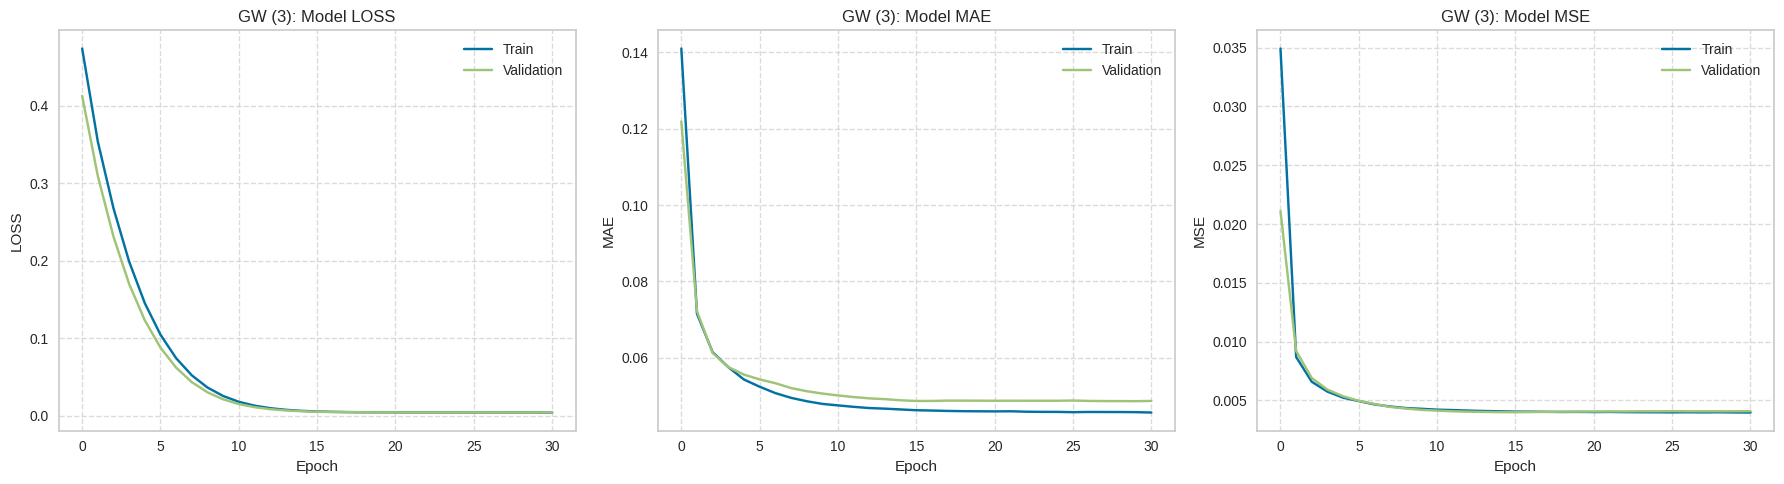

joint
Data prepared. X shape: (13518, 20), M shape: (13518, 9), Y shape: (13518, 2)

Starting Training...
Epoch 1/100
220/220 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.4845 - mae: 0.1297 - mse: 0.0292 - val_loss: 0.4161 - val_mae: 0.0938 - val_mse: 0.0127 - learning_rate: 1.0000e-04
Epoch 2/100
220/220 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3611 - mae: 0.0700 - mse: 0.0083 - val_loss: 0.3105 - val_mae: 0.0630 - val_mse: 0.0064 - learning_rate: 1.0000e-04
Epoch 3/100
220/220 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2690 - mae: 0.0618 - mse: 0.0067 - val_loss: 0.2283 - val_mae: 0.0559 - val_mse: 0.0051 - learning_rate: 1.0000e-04
Epoch 4/100
220/220 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1963 - mae: 0.0576 - mse: 0.0058 - val_loss: 0.1647 - val_mae: 0.0531 - val_mse: 0.0046 - learning_rate: 1.0000e-04
Epoch 5/100
220/220 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1404 - mae: 0.0538 - mse: 0.0051 - val_loss: 0.1167 - val_mae: 0.0510 - val_mse: 0.0043 - learning_rate: 1.0000e-04

2026-02-26 03:00:59.215011: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_16}}


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step

Generating Predictions...
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
{'fpl_name': array(['Schär', 'Joelinton', 'Leno', 'Xhaka', 'Wilson', 'Iwobi',
       'Welbeck', 'Henderson', 'Walker', 'Trippier', 'Gana', 'Grealish',
       'Pickford', 'Virgil', 'Ward-Prowse', 'Walker-Peters', 'Shaw',
       'Cullen', 'Mings', 'B.Fernandes', 'M.Salah', 'A.Becker', 'Lukić',
       'Keane', 'Tarkowski', 'Bowen', 'Digne', 'Lerma', 'Buendía',
       'Rodrigo', 'Ødegaard', 'Bernardo', 'Martinez', 'Wood', 'Merino',
       'Pope', 'Rice', 'Tosin', 'Wilson', 'Gabriel', 'Mukiele', 'Sangaré',
       'Mateta', 'Tielemans', 'Tete', 'Richarlison', 'Dunk', 'J.Murphy',
       'Hughes', 'Kamada', 'Milenković', 'Andersen', 'Konaté', 'Ampadu',
       'Rodon', 'Neto', 'Hudson-Odoi', 'Dúbravka', 'Nmecha', 'Mbeumo',
       'Chalobah', 'Barnes', 'Mavropanos', 'Brooks', 'Sessegnon',
       'Gibbs-White', 'Sels', 'Pedro Porro', 'Georginio', 'Longstaff',
       'Cucurella', 'Isidor', 'Jense

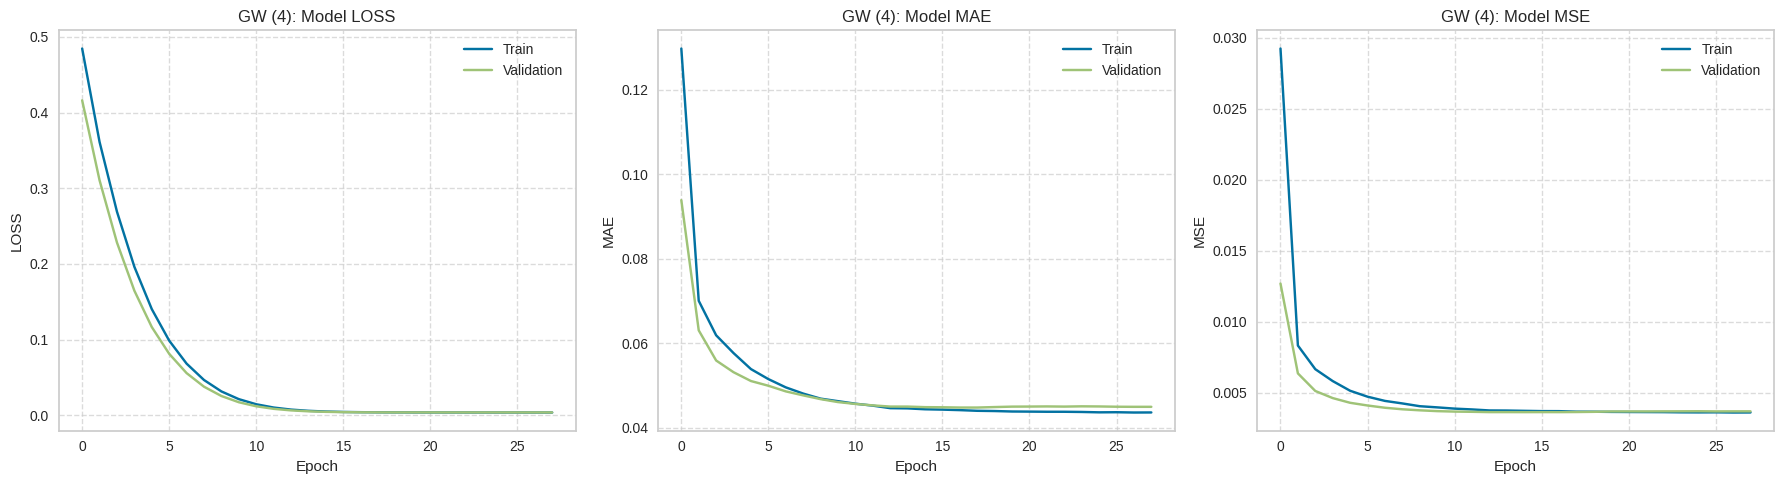

joint
Data prepared. X shape: (13518, 15), M shape: (13518, 9), Y shape: (13518, 2)

Starting Training...
Epoch 1/100
225/225 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.5635 - mae: 0.2960 - mse: 0.1203 - val_loss: 0.4543 - val_mae: 0.1997 - val_mse: 0.0494 - learning_rate: 1.0000e-04
Epoch 2/100
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3798 - mae: 0.0947 - mse: 0.0149 - val_loss: 0.3352 - val_mae: 0.0787 - val_mse: 0.0106 - learning_rate: 1.0000e-04
Epoch 3/100
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2953 - mae: 0.0665 - mse: 0.0075 - val_loss: 0.2589 - val_mae: 0.0611 - val_mse: 0.0068 - learning_rate: 1.0000e-04
Epoch 4/100
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2271 - mae: 0.0599 - mse: 0.0062 - val_loss: 0.1971 - val_mae: 0.0560 - val_mse: 0.0057 - learning_rate: 1.0000e-04
Epoch 5/100
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1719 - mae: 0.0569 - mse: 0.0056 - val_loss: 0.1477 - val_mae: 0.0535 - val_mse: 0.0051 - learning_rate: 1.0000e-04

2026-02-26 03:01:31.356755: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_16}}


8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step

Generating Predictions...
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
{'fpl_name': array(['Leno', 'Xhaka', 'Wilson', 'Milner', 'Iwobi', 'Aké', 'Henderson',
       'Walker', 'Gana', 'Grealish', 'Pickford', 'Darlow', 'Virgil',
       'Ward-Prowse', 'Walker-Peters', 'Shaw', 'Cullen', 'Mings',
       'Donnarumma', 'B.Fernandes', 'M.Salah', 'A.Becker', 'Lukić',
       'Keane', 'Tarkowski', 'Bowen', 'Digne', 'Lerma', 'Buendía',
       'Rodrigo', 'Bernardo', 'Martinez', 'Wood', 'Merino', 'Pope',
       'Rice', 'Calvert-Lewin', 'Tosin', 'Wilson', 'Gabriel', 'Mukiele',
       'Mateta', 'Tete', 'Richarlison', 'Dunk', 'Foden', 'J.Murphy',
       'Füllkrug', 'Hughes', 'Bentancur', 'Kamada', 'Milenković',
       'Andersen', 'Konaté', 'Ampadu', 'Rodon', 'Hudson-Odoi', 'Dúbravka',
       'Mbeumo', 'Chalobah', 'C.Jones', 'Barnes', 'Mavropanos', 'Brooks',
       'Sessegnon', 'Gibbs-White', 'Saliba', 'Sels', 'Pedro Porro',
       'Georginio', 'Longstaff', 'Cunha', 'Cucur

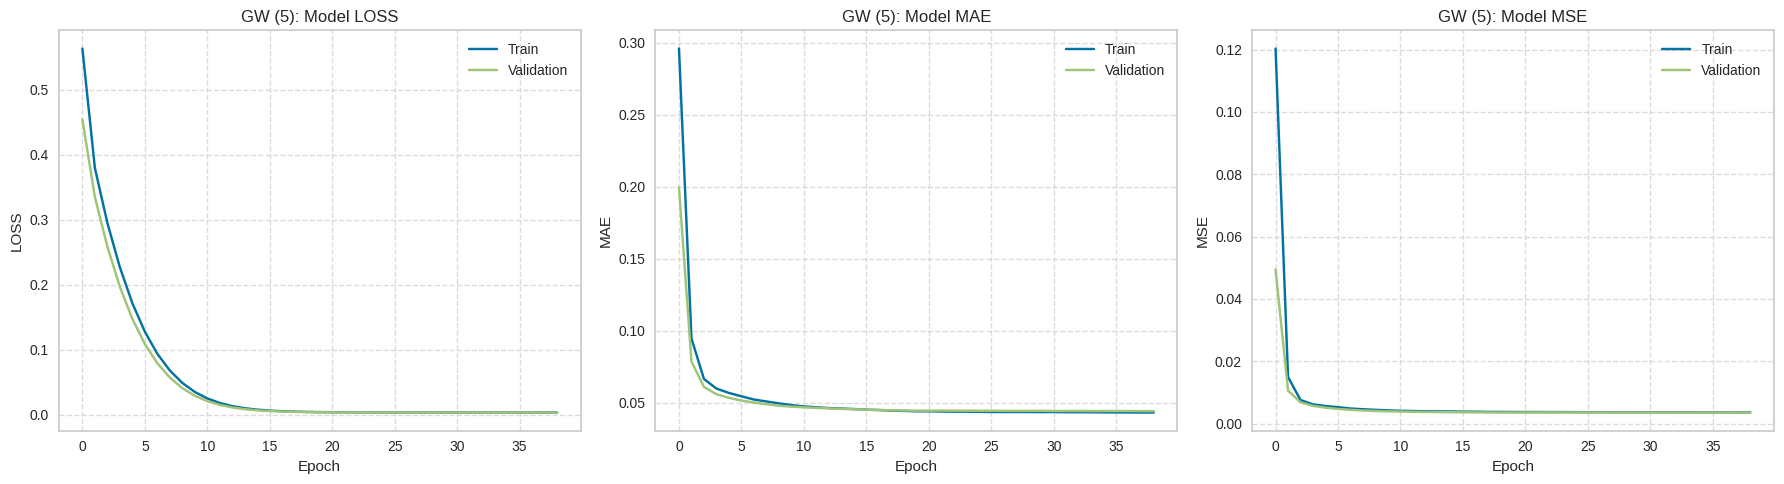

joint
Data prepared. X shape: (13518, 39), M shape: (13518, 9), Y shape: (13518, 2)

Starting Training...
Epoch 1/100
231/231 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.5528 - mae: 0.1608 - mse: 0.0468 - val_loss: 0.4627 - val_mae: 0.0904 - val_mse: 0.0128 - learning_rate: 1.0000e-04
Epoch 2/100
231/231 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4043 - mae: 0.0747 - mse: 0.0095 - val_loss: 0.3473 - val_mae: 0.0592 - val_mse: 0.0057 - learning_rate: 1.0000e-04
Epoch 3/100
231/231 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3018 - mae: 0.0621 - mse: 0.0065 - val_loss: 0.2564 - val_mae: 0.0532 - val_mse: 0.0047 - learning_rate: 1.0000e-04
Epoch 4/100
231/231 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2206 - mae: 0.0571 - mse: 0.0056 - val_loss: 0.1852 - val_mae: 0.0496 - val_mse: 0.0042 - learning_rate: 1.0000e-04
Epoch 5/100
231/231 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1580 - mae: 0.0534 - mse: 0.0049 - val_loss: 0.1312 - val_mae: 0.0474 - val_mse: 0.0039 - learning_rate: 1.0000e-04

2026-02-26 03:01:59.017481: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_16}}


8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step

Generating Predictions...
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
{'fpl_name': array(['Joelinton', 'Leno', 'Xhaka', 'Iwobi', 'Welbeck', 'Henderson',
       'Walker', 'Trippier', 'Gana', 'Grealish', 'Pickford', 'Darlow',
       'Virgil', 'Walker-Peters', 'Johnstone', 'Shaw', 'Cullen', 'Mings',
       'Donnarumma', 'B.Fernandes', 'M.Salah', 'A.Becker', 'Lukić',
       'Keane', 'Tarkowski', 'Maguire', 'Bowen', 'Digne', 'Lerma',
       'Buendía', 'Areola', 'Zinchenko', 'Martinez', 'Wood', 'Merino',
       'Bruun Larsen', 'Pope', 'Rice', 'Calvert-Lewin', 'Wilson',
       'Gabriel', 'Mukiele', 'Sarr', 'Mateta', 'Kamara', 'Richarlison',
       'Dunk', 'Foden', 'J.Murphy', 'Füllkrug', 'Hughes', 'Bentancur',
       'Kamada', 'Castagne', 'Milenković', 'Andersen', 'Konaté', 'Ampadu',
       'Rodon', 'Neto', 'Hudson-Odoi', 'Dúbravka', 'Mbeumo', 'C.Jones',
       'Mavropanos', 'Brooks', 'Sessegnon', 'Gibbs-White', 'Saliba',
       'Sels', 'Pedro Porro', 'Georgin

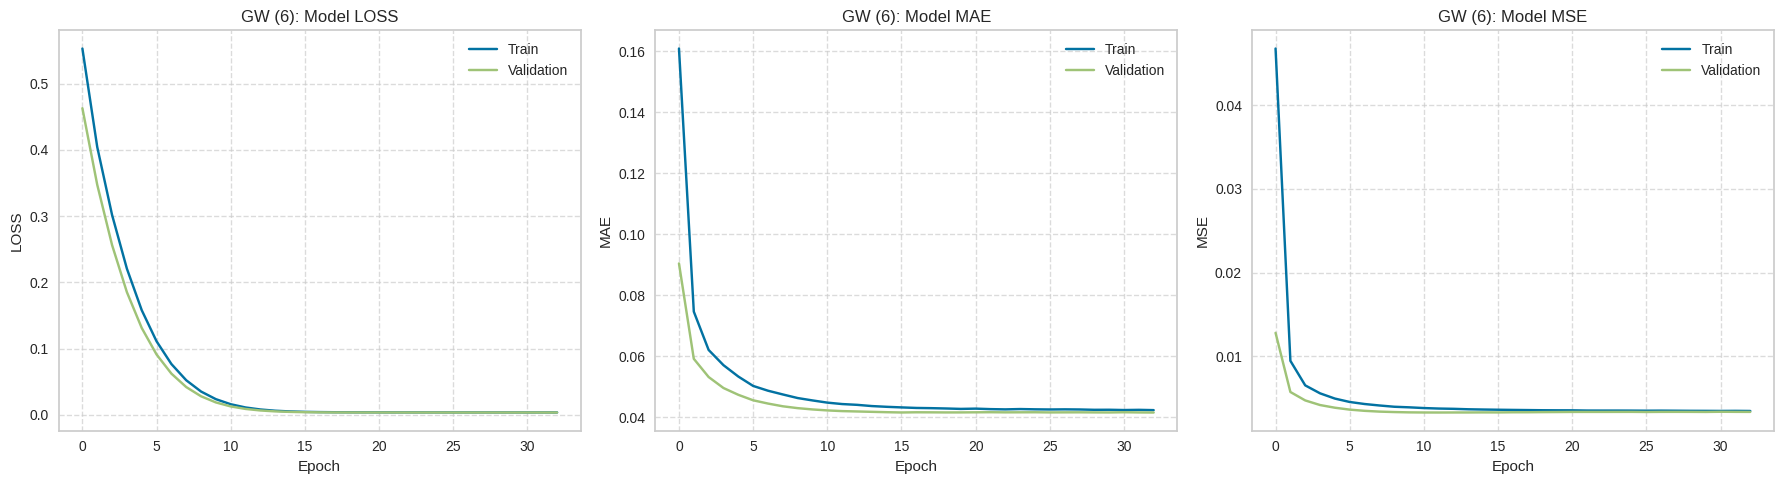

joint
Data prepared. X shape: (13518, 8), M shape: (13518, 9), Y shape: (13518, 2)

Starting Training...
Epoch 1/100
237/237 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.4962 - mae: 0.1935 - mse: 0.0653 - val_loss: 0.4075 - val_mae: 0.1308 - val_mse: 0.0239 - learning_rate: 1.0000e-04
Epoch 2/100
237/237 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3454 - mae: 0.0753 - mse: 0.0096 - val_loss: 0.2961 - val_mae: 0.0667 - val_mse: 0.0068 - learning_rate: 1.0000e-04
Epoch 3/100
237/237 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2559 - mae: 0.0631 - mse: 0.0067 - val_loss: 0.2164 - val_mae: 0.0560 - val_mse: 0.0050 - learning_rate: 1.0000e-04
Epoch 4/100
237/237 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1859 - mae: 0.0589 - mse: 0.0059 - val_loss: 0.1554 - val_mae: 0.0526 - val_mse: 0.0045 - learning_rate: 1.0000e-04
Epoch 5/100
237/237 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1326 - mae: 0.0559 - mse: 0.0054 - val_loss: 0.1097 - val_mae: 0.0506 - val_mse: 0.0042 - learning_rate: 1.0000e-04


2026-02-26 03:02:27.304465: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_16}}


8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step

Generating Predictions...
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
{'fpl_name': array(['Joelinton', 'Leno', 'Xhaka', 'Iwobi', 'Welbeck', 'Henderson',
       'Walker', 'Trippier', 'Gana', 'Pickford', 'Darlow', 'Virgil',
       'Johnstone', 'Shaw', 'Cullen', 'Donnarumma', 'B.Fernandes',
       'M.Salah', 'Keane', 'Tarkowski', 'Robertson', 'Masuaku', 'Bowen',
       'Digne', 'Buendía', 'Areola', 'Rodrigo', 'Martinez', 'Wood',
       'Isak', 'Pope', 'Rice', 'Calvert-Lewin', 'Wilson', 'Gabriel',
       'Mukiele', 'Sarr', 'Mateta', 'Kamara', 'Richarlison', 'Dunk',
       'Foden', 'J.Murphy', 'Füllkrug', 'Bentancur', 'Kamada', 'Castagne',
       'Milenković', 'Pau', 'Andersen', 'Konaté', 'Ampadu', 'Rodon',
       'Neto', 'Hudson-Odoi', 'Dúbravka', 'Mbeumo', 'C.Jones', 'Barnes',
       'Mavropanos', 'Brooks', 'Sessegnon', 'Gibbs-White', 'Saliba',
       'Sels', 'Pedro Porro', 'Georginio', 'Kluivert', 'Longstaff',
       'Cunha', 'Cucurella', 'Isidor', 'Jense

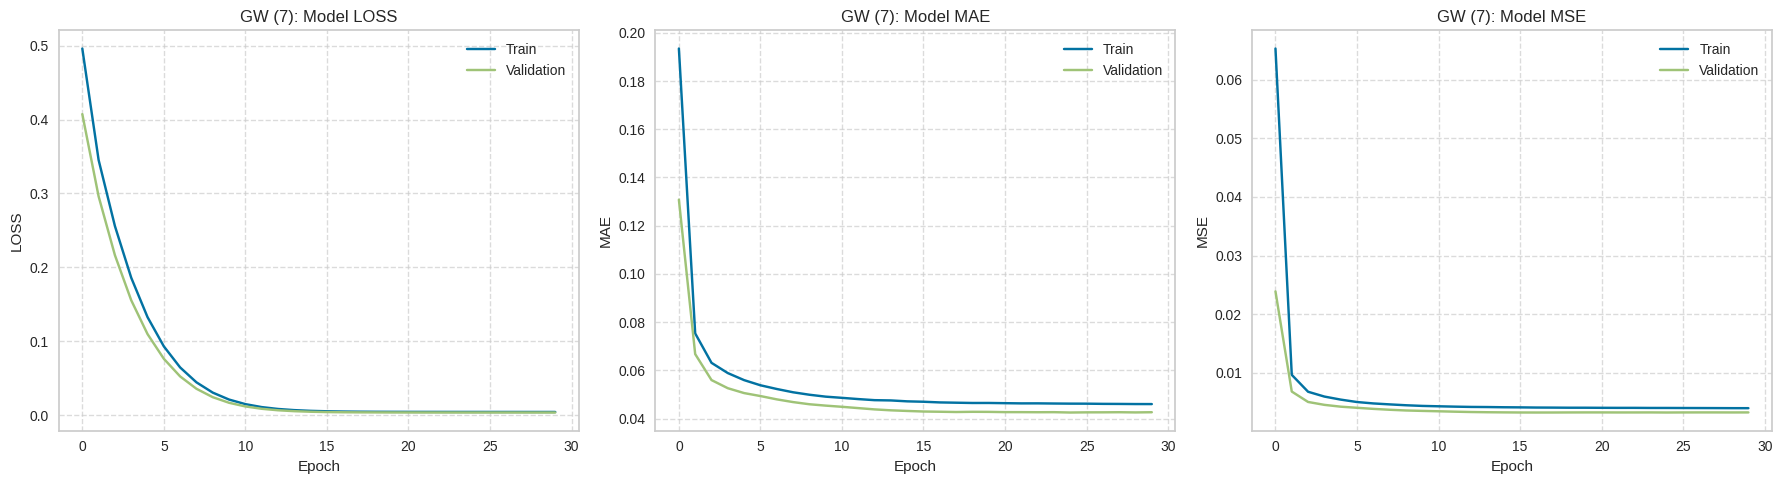

joint
Data prepared. X shape: (13518, 40), M shape: (13518, 9), Y shape: (13518, 2)

Starting Training...
Epoch 1/100
242/242 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.5757 - mae: 0.2107 - mse: 0.0737 - val_loss: 0.4709 - val_mae: 0.1007 - val_mse: 0.0174 - learning_rate: 1.0000e-04
Epoch 2/100
242/242 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4152 - mae: 0.0801 - mse: 0.0115 - val_loss: 0.3620 - val_mae: 0.0628 - val_mse: 0.0071 - learning_rate: 1.0000e-04
Epoch 3/100
242/242 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3188 - mae: 0.0661 - mse: 0.0078 - val_loss: 0.2748 - val_mae: 0.0558 - val_mse: 0.0056 - learning_rate: 1.0000e-04
Epoch 4/100
242/242 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2396 - mae: 0.0603 - mse: 0.0063 - val_loss: 0.2042 - val_mae: 0.0515 - val_mse: 0.0047 - learning_rate: 1.0000e-04
Epoch 5/100
242/242 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1767 - mae: 0.0566 - mse: 0.0057 - val_loss: 0.1488 - val_mae: 0.0486 - val_mse: 0.0042 - learning_rate: 1.0000e-04

2026-02-26 03:02:56.196027: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_16}}


8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step

Generating Predictions...
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
{'fpl_name': array(['Joelinton', 'Leno', 'Xhaka', 'Iwobi', 'Welbeck', 'Henderson',
       'Walker', 'Trippier', 'Gana', 'Traoré', 'Pickford', 'Darlow',
       'Virgil', 'Walker-Peters', 'Tuanzebe', 'Johnstone', 'Shaw',
       'Cullen', 'Donnarumma', 'B.Fernandes', 'M.Salah', 'Keane',
       'Tarkowski', 'Maguire', 'Bowen', 'Digne', 'Buendía', 'Casemiro',
       'Areola', 'Zinchenko', 'Diop', 'Bernardo', 'Martinez', 'Wood',
       'Isak', 'Merino', 'Bruun Larsen', 'Pope', 'Rice', 'Calvert-Lewin',
       'Wan-Bissaka', 'Wilson', 'Gabriel', 'Mukiele', 'Sarr', 'Mateta',
       'Kamara', 'Richarlison', 'Dunk', 'Foden', 'J.Murphy', 'Bentancur',
       'Douglas Luiz', 'Kamada', 'Castagne', 'Milenković', 'Pau',
       'Andersen', 'Konaté', 'Ampadu', 'Rodon', 'Neto', 'Hudson-Odoi',
       'Nketiah', 'Dúbravka', 'Mbeumo', 'Chalobah', 'C.Jones', 'Barnes',
       'Mavropanos', 'Cairney', 'Sessegn

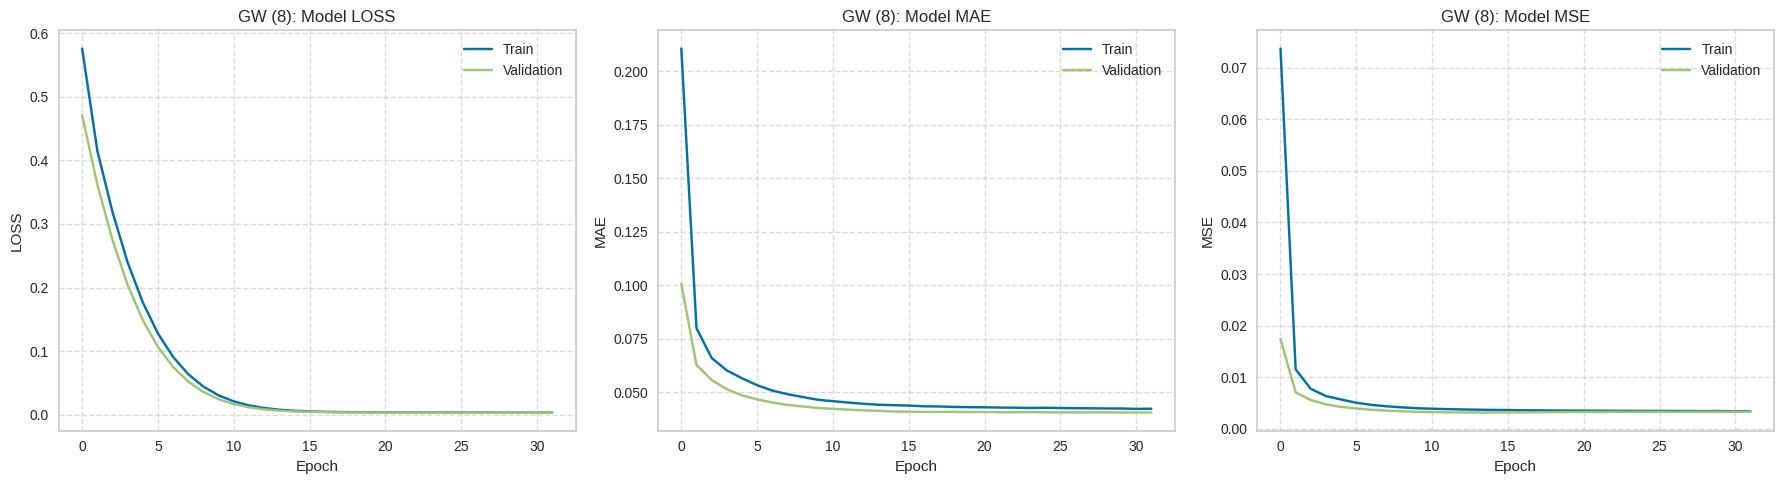

joint
Data prepared. X shape: (13518, 8), M shape: (13518, 9), Y shape: (13518, 2)

Starting Training...
Epoch 1/100
248/248 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.4457 - mae: 0.1272 - mse: 0.0273 - val_loss: 0.3736 - val_mae: 0.0985 - val_mse: 0.0130 - learning_rate: 1.0000e-04
Epoch 2/100
248/248 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3143 - mae: 0.0657 - mse: 0.0072 - val_loss: 0.2621 - val_mae: 0.0565 - val_mse: 0.0051 - learning_rate: 1.0000e-04
Epoch 3/100
248/248 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2214 - mae: 0.0588 - mse: 0.0059 - val_loss: 0.1819 - val_mae: 0.0504 - val_mse: 0.0042 - learning_rate: 1.0000e-04
Epoch 4/100
248/248 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1525 - mae: 0.0559 - mse: 0.0053 - val_loss: 0.1236 - val_mae: 0.0481 - val_mse: 0.0039 - learning_rate: 1.0000e-04
Epoch 5/100
248/248 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1029 - mae: 0.0529 - mse: 0.0049 - val_loss: 0.0823 - val_mae: 0.0468 - val_mse: 0.0037 - learning_rate: 1.0000e-04


2026-02-26 03:03:22.001850: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_16}}


8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step

Generating Predictions...
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
{'fpl_name': array(['Joelinton', 'Leno', 'Xhaka', 'Iwobi', 'Welbeck', 'Henderson',
       'Walker', 'Trippier', 'Gana', 'Grealish', 'Traoré', 'Pickford',
       'Virgil', 'Adama', 'Tuanzebe', 'Johnstone', 'Shaw', 'Cullen',
       'Donnarumma', 'B.Fernandes', 'M.Salah', 'Lukić', 'Keane',
       'Tarkowski', 'Bowen', 'Digne', 'Buendía', 'Casemiro', 'Areola',
       'Diop', 'Bernardo', 'Raúl', 'Martinez', 'Danso', 'Bruun Larsen',
       'Pope', 'Rice', 'Calvert-Lewin', 'Wan-Bissaka', 'Gabriel',
       'Mukiele', 'Sarr', 'Mateta', 'Kamara', 'Richarlison', 'Dunk',
       'Foden', 'J.Murphy', 'Bentancur', 'Douglas Luiz', 'Kamada',
       'Milenković', 'Pau', 'Konaté', 'Ampadu', 'Rodon', 'Neto',
       'Hudson-Odoi', 'Nketiah', 'Dúbravka', 'Mbeumo', 'Chalobah',
       'C.Jones', 'Todibo', 'Brooks', 'Sessegnon', 'Gibbs-White',
       'Saliba', 'Sels', 'Pedro Porro', 'Georginio', 'Kluivert',
 

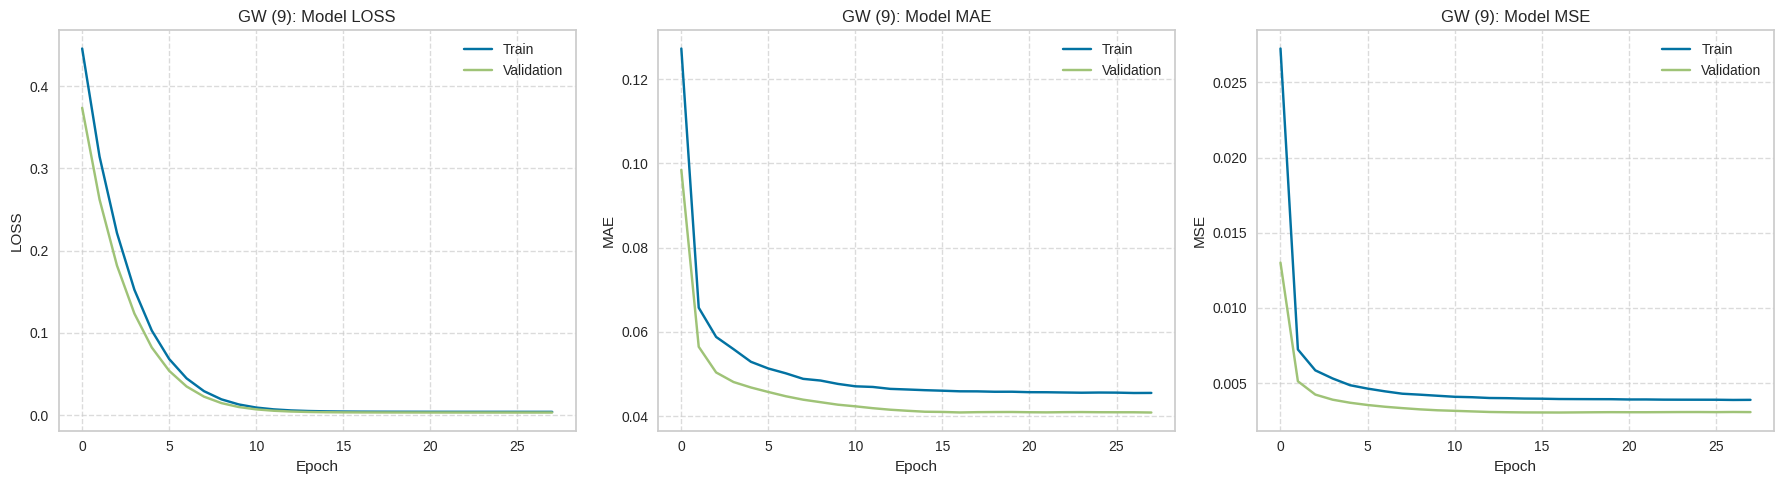

joint
Data prepared. X shape: (13518, 15), M shape: (13518, 9), Y shape: (13518, 2)

Starting Training...
Epoch 1/100
254/254 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.4835 - mae: 0.1646 - mse: 0.0456 - val_loss: 0.3956 - val_mae: 0.0873 - val_mse: 0.0107 - learning_rate: 1.0000e-04
Epoch 2/100
254/254 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3416 - mae: 0.0694 - mse: 0.0083 - val_loss: 0.2882 - val_mae: 0.0513 - val_mse: 0.0044 - learning_rate: 1.0000e-04
Epoch 3/100
254/254 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2478 - mae: 0.0597 - mse: 0.0061 - val_loss: 0.2060 - val_mae: 0.0454 - val_mse: 0.0036 - learning_rate: 1.0000e-04
Epoch 4/100
254/254 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1756 - mae: 0.0556 - mse: 0.0054 - val_loss: 0.1439 - val_mae: 0.0432 - val_mse: 0.0032 - learning_rate: 1.0000e-04
Epoch 5/100
254/254 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1217 - mae: 0.0526 - mse: 0.0048 - val_loss: 0.0983 - val_mae: 0.0415 - val_mse: 0.0030 - learning_rate: 1.0000e-04

2026-02-26 03:03:48.684626: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_16}}


8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step

Generating Predictions...
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
{'fpl_name': array(['Joelinton', 'Leno', 'Xhaka', 'Wilson', 'Iwobi', 'Welbeck',
       'Henderson', 'Walker', 'Gana', 'Grealish', 'Traoré', 'Pickford',
       'Virgil', 'Tuanzebe', 'Johnstone', 'Shaw', 'Cullen', 'Donnarumma',
       'B.Fernandes', 'M.Salah', 'Keane', 'Tarkowski', 'Robertson',
       'Bowen', 'Digne', 'Casemiro', 'Areola', 'Bernardo', 'Raúl',
       'Martinez', 'Danso', 'Merino', 'Bruun Larsen', 'Pope', 'Rice',
       'Calvert-Lewin', 'Wan-Bissaka', 'Wilson', 'Gabriel', 'Mukiele',
       'Sarr', 'Mateta', 'Kolo Muani', 'Kamara', 'Tete', 'Richarlison',
       'Dunk', 'Foden', 'J.Murphy', 'Bentancur', 'Kamada', 'Milenković',
       'Pau', 'Andersen', 'Konaté', 'Ampadu', 'Rodon', 'Neto',
       'Hudson-Odoi', 'Dúbravka', 'Mbeumo', 'Chalobah', 'Barnes', 'Bijol',
       'Todibo', 'Brooks', 'Cairney', 'Sessegnon', 'Gibbs-White',
       'Saliba', 'Sels', 'Pedro Porro', 'Georg

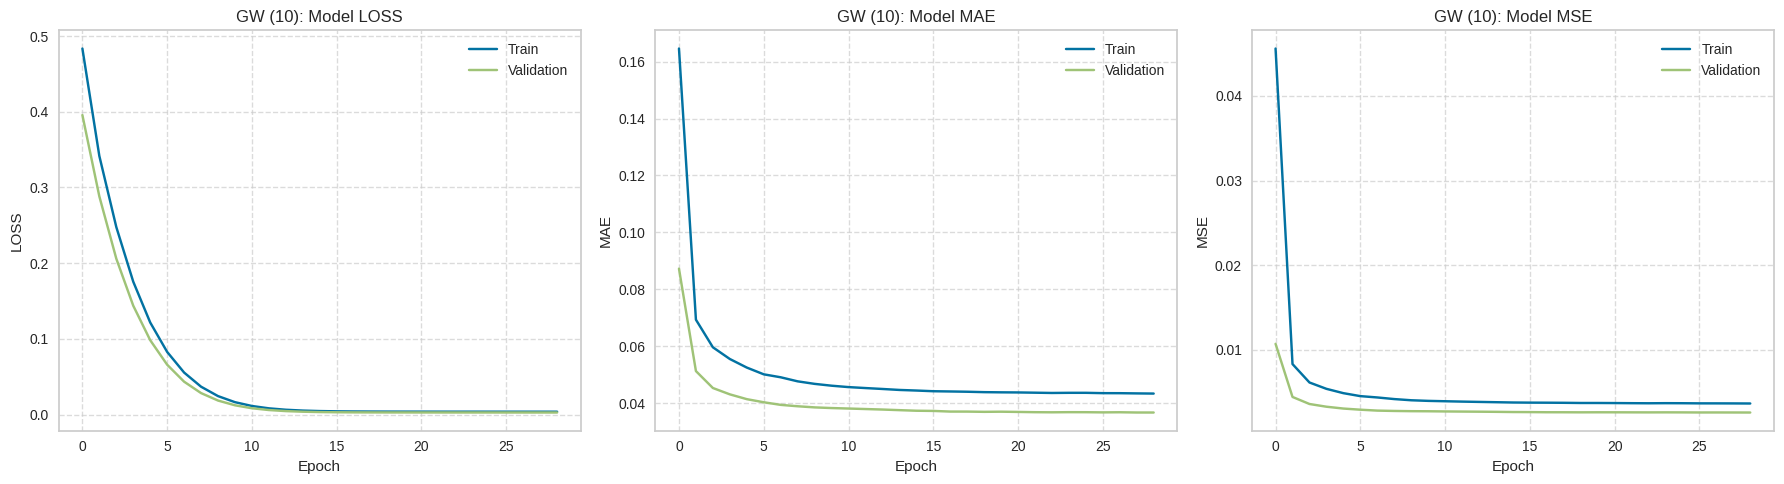

joint
Data prepared. X shape: (13518, 45), M shape: (13518, 9), Y shape: (13518, 2)

Starting Training...
Epoch 1/100
260/260 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.5158 - mae: 0.1168 - mse: 0.0239 - val_loss: 0.4270 - val_mae: 0.0652 - val_mse: 0.0068 - learning_rate: 1.0000e-04
Epoch 2/100
260/260 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3630 - mae: 0.0652 - mse: 0.0073 - val_loss: 0.2998 - val_mae: 0.0504 - val_mse: 0.0044 - learning_rate: 1.0000e-04
Epoch 3/100
260/260 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2520 - mae: 0.0583 - mse: 0.0059 - val_loss: 0.2047 - val_mae: 0.0461 - val_mse: 0.0038 - learning_rate: 1.0000e-04
Epoch 4/100
260/260 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1703 - mae: 0.0543 - mse: 0.0052 - val_loss: 0.1361 - val_mae: 0.0438 - val_mse: 0.0034 - learning_rate: 1.0000e-04
Epoch 5/100
260/260 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1123 - mae: 0.0515 - mse: 0.0047 - val_loss: 0.0883 - val_mae: 0.0421 - val_mse: 0.0032 - learning_rate: 1.0000e-04

2026-02-26 03:04:14.412691: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_16}}


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step

Generating Predictions...
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
{'fpl_name': array(['Joelinton', 'Leno', 'Xhaka', 'Wilson', 'Iwobi', 'Welbeck',
       'Barkley', 'Henderson', 'Walker', 'Trippier', 'Gana', 'Grealish',
       'Traoré', 'Pickford', 'Virgil', 'Tuanzebe', 'Johnstone', 'Shaw',
       'Cullen', 'Donnarumma', 'B.Fernandes', 'M.Salah', 'Keane',
       'Tarkowski', 'Robertson', 'Bowen', 'Digne', 'Lerma', 'Buendía',
       'Casemiro', 'Areola', 'Bernardo', 'Raúl', 'Martinez', 'Merino',
       'Bruun Larsen', 'Pope', 'Rice', 'Calvert-Lewin', 'Wan-Bissaka',
       'James', 'Wilson', 'Mukiele', 'Sarr', 'Sangaré', 'Mateta',
       'Kolo Muani', 'Kamara', 'Tete', 'Richarlison', 'Dunk', 'Foden',
       'J.Murphy', 'Kamada', 'Milenković', 'Pau', 'Andersen', 'Konaté',
       'Sancho', 'Ampadu', 'Rodon', 'Neto', 'Dúbravka', 'Nmecha',
       'Mbeumo', 'Chalobah', 'C.Jones', 'Barnes', 'Bijol', 'Todibo',
       'Sessegnon', 'Gibbs-White', 'Saliba', 'Sel

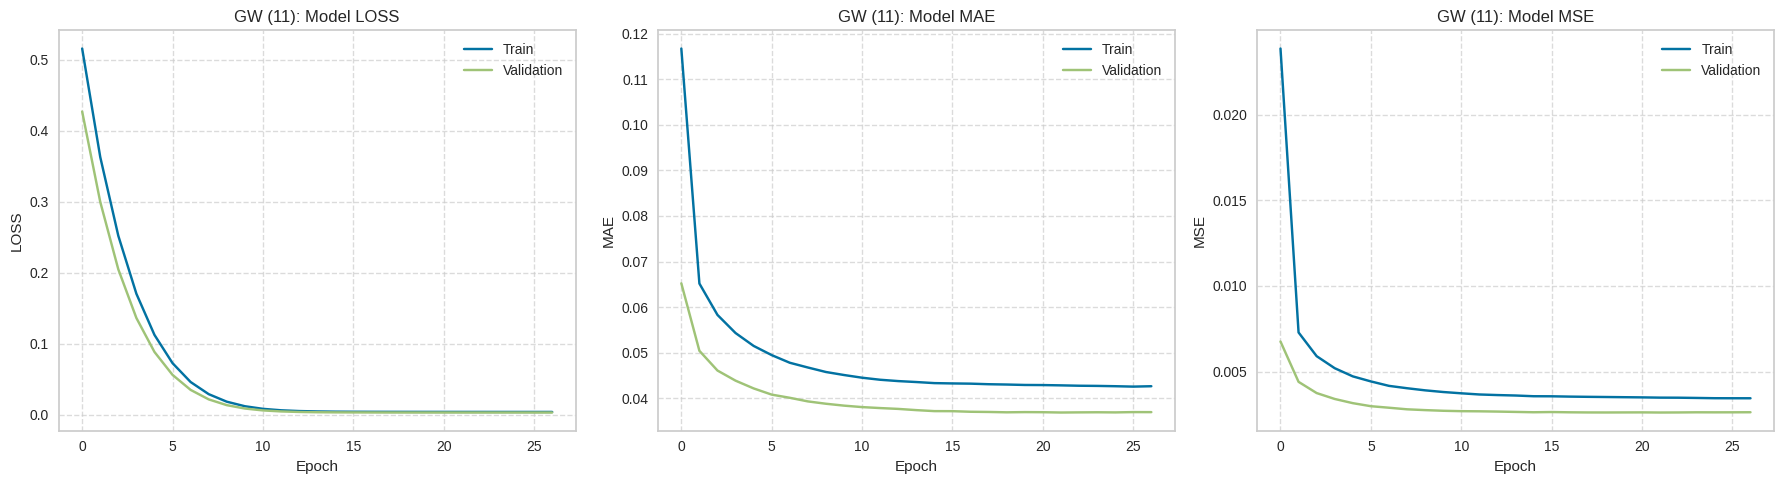

joint
Data prepared. X shape: (13518, 29), M shape: (13518, 9), Y shape: (13518, 2)

Starting Training...
Epoch 1/100
265/265 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.5633 - mae: 0.2374 - mse: 0.0869 - val_loss: 0.4414 - val_mae: 0.1019 - val_mse: 0.0170 - learning_rate: 1.0000e-04
Epoch 2/100
265/265 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3844 - mae: 0.0841 - mse: 0.0126 - val_loss: 0.3265 - val_mae: 0.0558 - val_mse: 0.0055 - learning_rate: 1.0000e-04
Epoch 3/100
265/265 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2838 - mae: 0.0663 - mse: 0.0076 - val_loss: 0.2385 - val_mae: 0.0491 - val_mse: 0.0043 - learning_rate: 1.0000e-04
Epoch 4/100
265/265 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2050 - mae: 0.0595 - mse: 0.0062 - val_loss: 0.1699 - val_mae: 0.0455 - val_mse: 0.0037 - learning_rate: 1.0000e-04
Epoch 5/100
265/265 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1449 - mae: 0.0559 - mse: 0.0055 - val_loss: 0.1183 - val_mae: 0.0430 - val_mse: 0.0033 - learning_rate: 1.0000e-04

2026-02-26 03:04:42.190320: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_16}}


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step

Generating Predictions...
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
{'fpl_name': array(['Schär', 'Joelinton', 'Leno', 'Xhaka', 'Wilson', 'Iwobi',
       'Welbeck', 'Barkley', 'Henderson', 'Walker', 'Grealish', 'Traoré',
       'Pickford', 'Virgil', 'Tuanzebe', 'Johnstone', 'Shaw', 'Cullen',
       'Donnarumma', 'B.Fernandes', 'M.Salah', 'Keane', 'Tarkowski',
       'Robertson', 'Bowen', 'Cook', 'Digne', 'Buendía', 'Casemiro',
       'Areola', 'Bernardo', 'Raúl', 'Martinez', 'Danso', 'Merino',
       'Pope', 'Rice', 'Calvert-Lewin', 'Wan-Bissaka', 'James', 'Wilson',
       'Mukiele', 'Sarr', 'Sangaré', 'Mateta', 'Kolo Muani', 'Kamara',
       'Tete', 'Richarlison', 'Dunk', 'Foden', 'J.Murphy', 'Bentancur',
       'Kamada', 'Milenković', 'Pau', 'Andersen', 'Konaté', 'Sancho',
       'Ampadu', 'Rodon', 'Neto', 'Dúbravka', 'Nmecha', 'Mbeumo',
       'Chalobah', 'C.Jones', 'Barnes', 'Todibo', 'Brooks', 'Sessegnon',
       'Gibbs-White', 'Saliba', 'Sels', '

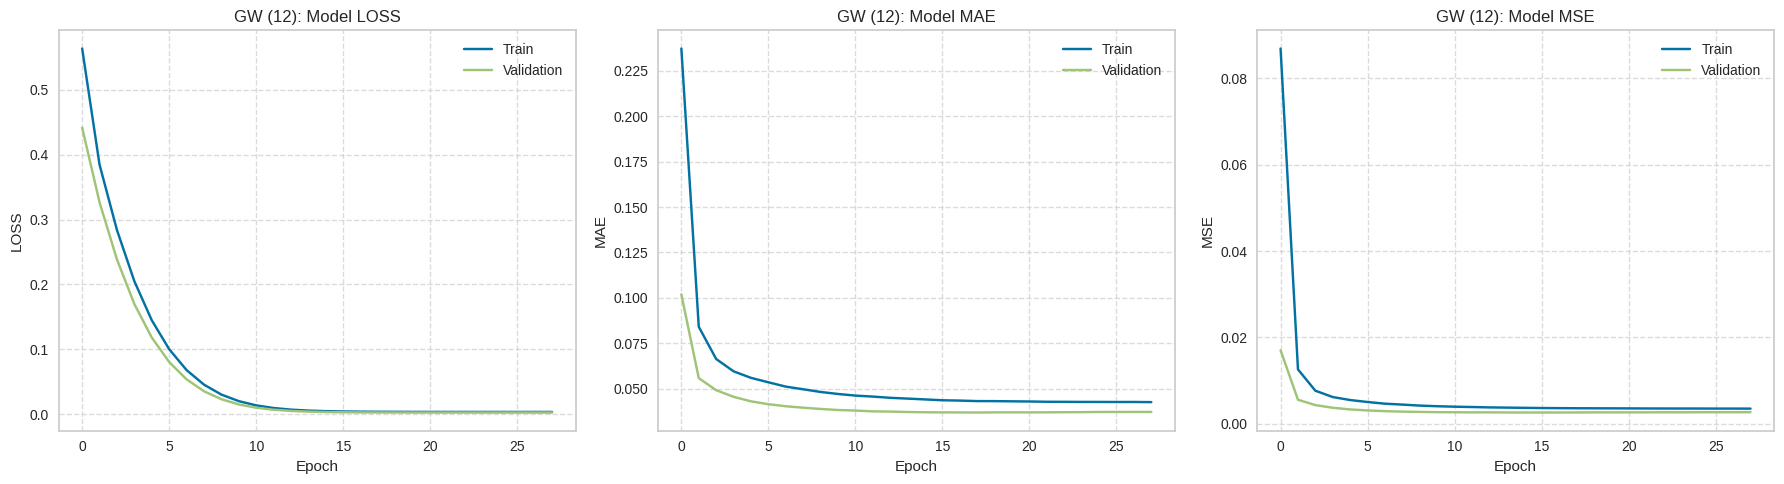

joint
Data prepared. X shape: (13518, 5), M shape: (13518, 9), Y shape: (13518, 2)

Starting Training...
Epoch 1/100
271/271 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.4489 - mae: 0.1457 - mse: 0.0369 - val_loss: 0.3740 - val_mae: 0.1113 - val_mse: 0.0163 - learning_rate: 1.0000e-04
Epoch 2/100
271/271 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3121 - mae: 0.0660 - mse: 0.0072 - val_loss: 0.2595 - val_mae: 0.0543 - val_mse: 0.0045 - learning_rate: 1.0000e-04
Epoch 3/100
271/271 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2195 - mae: 0.0606 - mse: 0.0062 - val_loss: 0.1784 - val_mae: 0.0461 - val_mse: 0.0035 - learning_rate: 1.0000e-04
Epoch 4/100
271/271 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1497 - mae: 0.0576 - mse: 0.0056 - val_loss: 0.1193 - val_mae: 0.0441 - val_mse: 0.0032 - learning_rate: 1.0000e-04
Epoch 5/100
271/271 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0994 - mae: 0.0553 - mse: 0.0052 - val_loss: 0.0777 - val_mae: 0.0427 - val_mse: 0.0030 - learning_rate: 1.0000e-04


2026-02-26 03:05:11.353943: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_16}}


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step

Generating Predictions...
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
{'fpl_name': array(['Joelinton', 'Leno', 'Xhaka', 'Wilson', 'Iwobi', 'Welbeck',
       'Henderson', 'Walker', 'Grealish', 'Traoré', 'Pickford', 'Virgil',
       'Tuanzebe', 'Johnstone', 'Shaw', 'Cullen', 'Donnarumma',
       'B.Fernandes', 'A.Becker', 'Keane', 'Tarkowski', 'Bowen', 'Digne',
       'Buendía', 'Casemiro', 'Areola', 'Bernardo', 'Raúl', 'Martinez',
       'Isak', 'Danso', 'Merino', 'Rice', 'Calvert-Lewin', 'Wan-Bissaka',
       'James', 'Wilson', 'Mukiele', 'Sarr', 'Sangaré', 'Mateta',
       'Kolo Muani', 'Kamara', 'Tielemans', 'Tete', 'Richarlison', 'Dunk',
       'Foden', 'Bentancur', 'Kamada', 'Milenković', 'Pau', 'Andersen',
       'Konaté', 'Ampadu', 'Rodon', 'Neto', 'Hudson-Odoi', 'Dúbravka',
       'Nmecha', 'Mbeumo', 'Chalobah', 'Barnes', 'Bijol', 'Todibo',
       'Sessegnon', 'Gibbs-White', 'Sels', 'Pedro Porro', 'Georginio',
       'Cucurella', 'Isidor', 'Chukw

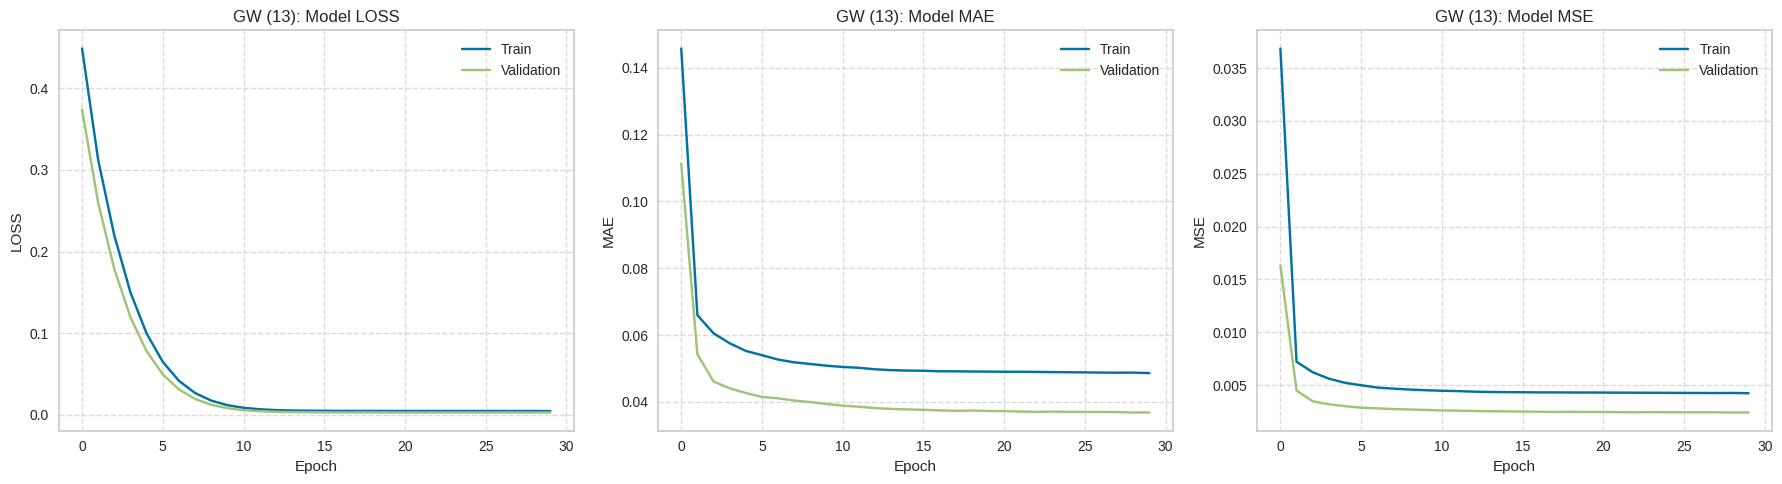

joint
Data prepared. X shape: (13518, 44), M shape: (13518, 9), Y shape: (13518, 2)

Starting Training...
Epoch 1/100
259/276 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.5806 - mae: 0.1546 - mse: 0.0394

2026-02-26 03:05:16.422800: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_16}}


276/276 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.5232 - mae: 0.1125 - mse: 0.0224 - val_loss: 0.4307 - val_mae: 0.0705 - val_mse: 0.0077 - learning_rate: 1.0000e-04
Epoch 2/100
276/276 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3607 - mae: 0.0656 - mse: 0.0074 - val_loss: 0.2937 - val_mae: 0.0521 - val_mse: 0.0045 - learning_rate: 1.0000e-04
Epoch 3/100
276/276 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2431 - mae: 0.0580 - mse: 0.0058 - val_loss: 0.1941 - val_mae: 0.0461 - val_mse: 0.0035 - learning_rate: 1.0000e-04
Epoch 4/100
276/276 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1589 - mae: 0.0533 - mse: 0.0050 - val_loss: 0.1244 - val_mae: 0.0427 - val_mse: 0.0031 - learning_rate: 1.0000e-04
Epoch 5/100
276/276 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1010 - mae: 0.0498 - mse: 0.0044 - val_loss: 0.0775 - val_mae: 0.0404 - val_mse: 0.0028 - learning_rate: 1.0000e-04
Epoch 6/100
276/276 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0626 - mae: 0.0477 - mse: 0.0041 - val_loss: 0.0470 - 

2026-02-26 03:05:39.257209: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_16}}


8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step

Generating Predictions...
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
{'fpl_name': array(['Joelinton', 'Leno', 'Xhaka', 'Wilson', 'Iwobi', 'Welbeck',
       'Henderson', 'Walker', 'Grealish', 'Pickford', 'Virgil',
       'Johnstone', 'Gomez', 'Shaw', 'Cullen', 'Donnarumma',
       'B.Fernandes', 'M.Salah', 'A.Becker', 'Tarkowski', 'Robertson',
       'Bowen', 'Digne', 'Lerma', 'Casemiro', 'Areola', 'Bernardo',
       'Raúl', 'Isak', 'Danso', 'Merino', 'Bruun Larsen', 'Rice',
       'Calvert-Lewin', 'Wan-Bissaka', 'Tosin', 'Wilson', 'Ramsdale',
       'Mukiele', 'Sangaré', 'Mateta', 'Kolo Muani', 'Kamara',
       'Tielemans', 'Tete', 'Dunk', 'Foden', 'J.Murphy', 'Bentancur',
       'Kamada', 'Milenković', 'Pau', 'Andersen', 'Konaté', 'Ampadu',
       'Rodon', 'Neto', 'Hudson-Odoi', 'Nketiah', 'Dúbravka', 'Nmecha',
       'Mbeumo', 'Chalobah', 'C.Jones', 'Barnes', 'Mavropanos', 'Bijol',
       'Todibo', 'Sessegnon', 'Gibbs-White', 'Sels', 'Pedro Porro',
 

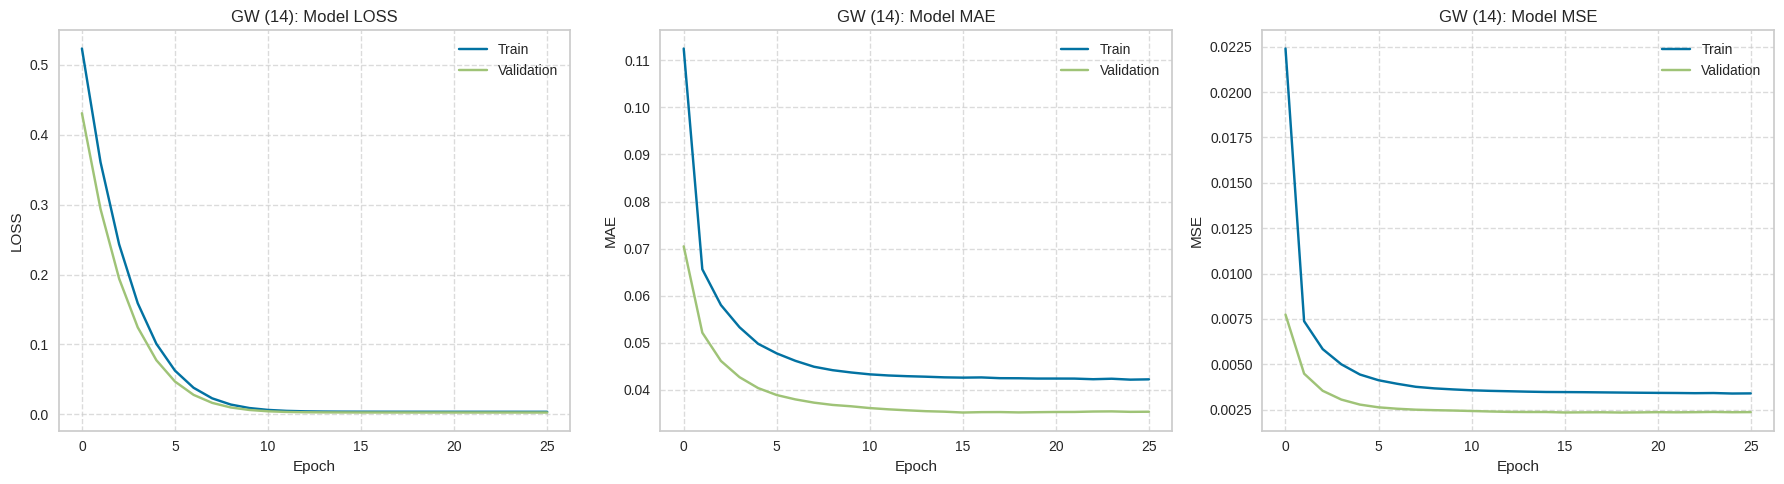

joint
Data prepared. X shape: (13518, 44), M shape: (13518, 9), Y shape: (13518, 2)

Starting Training...
Epoch 1/100
282/282 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.5345 - mae: 0.1460 - mse: 0.0379 - val_loss: 0.4372 - val_mae: 0.0730 - val_mse: 0.0085 - learning_rate: 1.0000e-04
Epoch 2/100
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3723 - mae: 0.0662 - mse: 0.0075 - val_loss: 0.3091 - val_mae: 0.0525 - val_mse: 0.0046 - learning_rate: 1.0000e-04
Epoch 3/100
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2600 - mae: 0.0585 - mse: 0.0059 - val_loss: 0.2116 - val_mae: 0.0465 - val_mse: 0.0037 - learning_rate: 1.0000e-04
Epoch 4/100
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1758 - mae: 0.0540 - mse: 0.0051 - val_loss: 0.1404 - val_mae: 0.0432 - val_mse: 0.0032 - learning_rate: 1.0000e-04
Epoch 5/100
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1155 - mae: 0.0508 - mse: 0.0045 - val_loss: 0.0905 - val_mae: 0.0408 - val_mse: 0.0029 - learning_rate: 1.0000e-04

2026-02-26 03:06:07.756572: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_16}}


8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step

Generating Predictions...
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
{'fpl_name': array(['Schär', 'Joelinton', 'Leno', 'Xhaka', 'Wilson', 'Iwobi',
       'Welbeck', 'Henderson', 'Grealish', 'Traoré', 'Pickford', 'Smith',
       'Virgil', 'Johnstone', 'Gomez', 'Shaw', 'Cullen', 'Donnarumma',
       'B.Fernandes', 'A.Becker', 'Keane', 'Tarkowski', 'Bowen', 'Lerma',
       'Casemiro', 'Areola', 'Ødegaard', 'Bernardo', 'Raúl', 'Martinez',
       'Merino', 'Bruun Larsen', 'Rice', 'Calvert-Lewin', 'Wan-Bissaka',
       'Wilson', 'Ramsdale', 'Mukiele', 'Sangaré', 'Mateta', 'Kolo Muani',
       'Kamara', 'Tielemans', 'Tete', 'Richarlison', 'Dunk', 'Foden',
       'Bentancur', 'Kamada', 'Castagne', 'Milenković', 'Pau', 'Andersen',
       'Konaté', 'Ampadu', 'Rodon', 'Neto', 'Hudson-Odoi', 'Nketiah',
       'Dúbravka', 'Mbeumo', 'Chalobah', 'C.Jones', 'Mavropanos', 'Bijol',
       'Todibo', 'Brooks', 'Gibbs-White', 'Sels', 'Pedro Porro',
       'Georginio', 'Klu

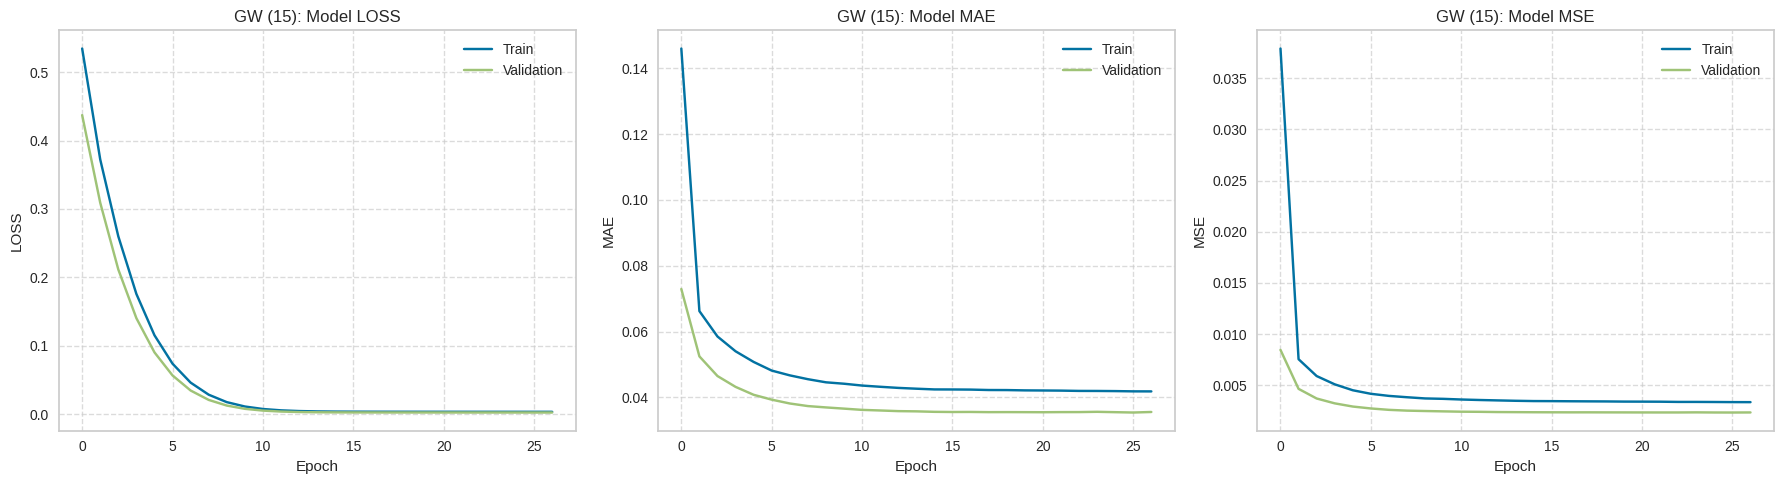

joint
Data prepared. X shape: (13518, 9), M shape: (13518, 9), Y shape: (13518, 2)

Starting Training...
Epoch 1/100
288/288 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.4540 - mae: 0.1465 - mse: 0.0370 - val_loss: 0.3704 - val_mae: 0.0986 - val_mse: 0.0138 - learning_rate: 1.0000e-04
Epoch 2/100
288/288 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3079 - mae: 0.0666 - mse: 0.0076 - val_loss: 0.2520 - val_mae: 0.0507 - val_mse: 0.0044 - learning_rate: 1.0000e-04
Epoch 3/100
288/288 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2104 - mae: 0.0589 - mse: 0.0060 - val_loss: 0.1686 - val_mae: 0.0445 - val_mse: 0.0035 - learning_rate: 1.0000e-04
Epoch 4/100
288/288 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1394 - mae: 0.0546 - mse: 0.0052 - val_loss: 0.1096 - val_mae: 0.0416 - val_mse: 0.0030 - learning_rate: 1.0000e-04
Epoch 5/100
288/288 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0900 - mae: 0.0519 - mse: 0.0047 - val_loss: 0.0693 - val_mae: 0.0396 - val_mse: 0.0028 - learning_rate: 1.0000e-04


2026-02-26 03:06:45.175420: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_16}}


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step

Generating Predictions...
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
{'fpl_name': array(['Schär', 'Leno', 'Xhaka', 'Clyne', 'Henderson', 'Grealish',
       'Pickford', 'Smith', 'Virgil', 'Johnstone', 'Shaw', 'Cullen',
       'Donnarumma', 'B.Fernandes', 'A.Becker', 'Keane', 'Tarkowski',
       'Bowen', 'Areola', 'Ødegaard', 'Bernardo', 'Raúl', 'Merino',
       'Bruun Larsen', 'Rice', 'Calvert-Lewin', 'Wilson', 'Ramsdale',
       'Mukiele', 'Mateta', 'Kolo Muani', 'Kamara', 'Tielemans', 'Tete',
       'Richarlison', 'Foden', 'J.Murphy', 'Bentancur', 'Milenković',
       'Andersen', 'Konaté', 'Ampadu', 'Rodon', 'Neto', 'Hudson-Odoi',
       'Nketiah', 'Dúbravka', 'Chalobah', 'Willock', 'C.Jones', 'Barnes',
       'Mavropanos', 'Bijol', 'Todibo', 'Gibbs-White', 'Pedro Porro',
       'Georginio', 'Kluivert', 'Cunha', 'Cucurella', 'Isidor', 'Jensen',
       'Romero', 'Smith Rowe', 'Gyökeres', 'Diakité', 'Dalot', 'Saka',
       'L.Paquetá', 'Garner', 'Zubime

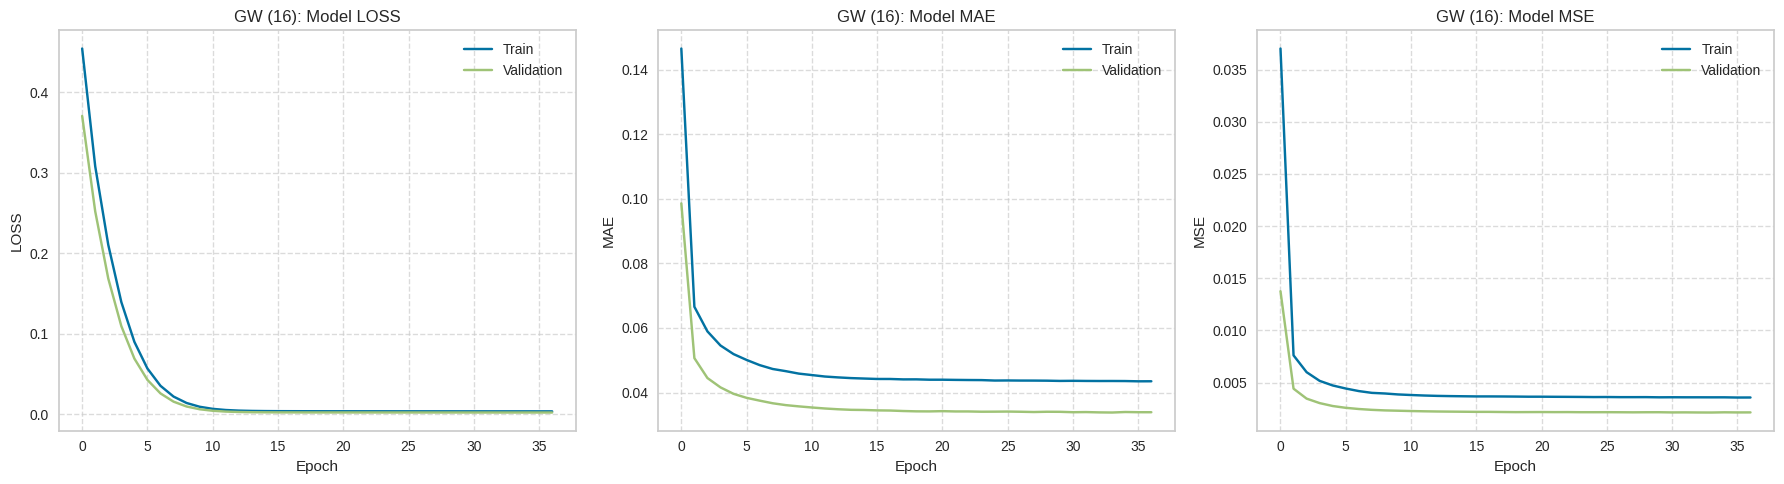

joint
Data prepared. X shape: (13518, 12), M shape: (13518, 9), Y shape: (13518, 2)

Starting Training...
Epoch 1/100
293/293 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.4912 - mae: 0.1892 - mse: 0.0584 - val_loss: 0.3891 - val_mae: 0.0908 - val_mse: 0.0120 - learning_rate: 1.0000e-04
Epoch 2/100
293/293 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3314 - mae: 0.0730 - mse: 0.0090 - val_loss: 0.2748 - val_mae: 0.0523 - val_mse: 0.0045 - learning_rate: 1.0000e-04
Epoch 3/100
293/293 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2331 - mae: 0.0621 - mse: 0.0066 - val_loss: 0.1896 - val_mae: 0.0461 - val_mse: 0.0035 - learning_rate: 1.0000e-04
Epoch 4/100
293/293 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1590 - mae: 0.0566 - mse: 0.0055 - val_loss: 0.1271 - val_mae: 0.0433 - val_mse: 0.0031 - learning_rate: 1.0000e-04
Epoch 5/100
293/293 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1057 - mae: 0.0530 - mse: 0.0049 - val_loss: 0.0829 - val_mae: 0.0409 - val_mse: 0.0028 - learning_rate: 1.0000e-04

2026-02-26 03:07:16.634690: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_16}}


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step

Generating Predictions...
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
{'fpl_name': array(['Schär', 'Leno', 'Xhaka', 'Clyne', 'Walker', 'Grealish',
       'Pickford', 'Virgil', 'Shaw', 'Cullen', 'Donnarumma', 'A.Becker',
       'Lukić', 'Keane', 'Tarkowski', 'Bowen', 'Lerma', 'Areola',
       'Ødegaard', 'Bernardo', 'Raúl', 'Martinez', 'Bruun Larsen', 'Rice',
       'Calvert-Lewin', 'Wilson', 'Ramsdale', 'Mukiele', 'Mateta',
       'Kolo Muani', 'Kamara', 'Tielemans', 'Tete', 'Foden', 'J.Murphy',
       'Lindelöf', 'Bentancur', 'Milenković', 'Andersen', 'Konaté',
       'Ampadu', 'Rodon', 'Neto', 'Hudson-Odoi', 'Nketiah', 'Dúbravka',
       'Chalobah', 'C.Jones', 'Barnes', 'Bijol', 'Todibo', 'Doherty',
       'Gibbs-White', 'Saliba', 'Pedro Porro', 'Georginio', 'Kluivert',
       'Cunha', 'Cucurella', 'Isidor', 'Jensen', 'Smith Rowe', 'Gyökeres',
       'Diakité', 'Dalot', 'Saka', 'Kilman', 'L.Paquetá', 'Garner',
       'Zubimendi', 'Fofana', 'Guéhi', 'T

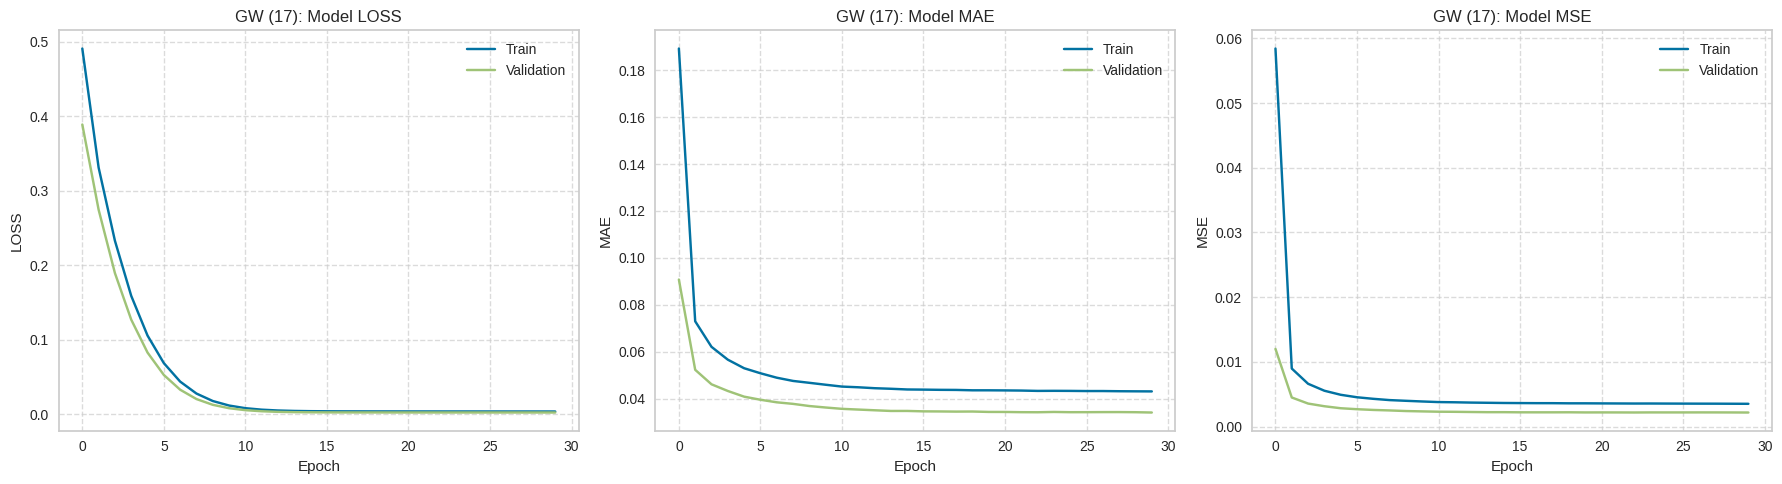

joint
Data prepared. X shape: (13518, 9), M shape: (13518, 9), Y shape: (13518, 2)

Starting Training...
Epoch 1/100
298/298 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.4993 - mae: 0.2116 - mse: 0.0714 - val_loss: 0.3896 - val_mae: 0.1056 - val_mse: 0.0155 - learning_rate: 1.0000e-04
Epoch 2/100
298/298 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3303 - mae: 0.0753 - mse: 0.0093 - val_loss: 0.2746 - val_mae: 0.0512 - val_mse: 0.0042 - learning_rate: 1.0000e-04
Epoch 3/100
298/298 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2343 - mae: 0.0644 - mse: 0.0069 - val_loss: 0.1912 - val_mae: 0.0451 - val_mse: 0.0034 - learning_rate: 1.0000e-04
Epoch 4/100
298/298 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1615 - mae: 0.0592 - mse: 0.0059 - val_loss: 0.1294 - val_mae: 0.0427 - val_mse: 0.0030 - learning_rate: 1.0000e-04
Epoch 5/100
298/298 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1086 - mae: 0.0558 - mse: 0.0053 - val_loss: 0.0856 - val_mae: 0.0411 - val_mse: 0.0028 - learning_rate: 1.0000e-04


2026-02-26 03:07:52.911853: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_16}}


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step

Generating Predictions...
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
{'fpl_name': array(['Schär', 'Leno', 'Xhaka', 'Clyne', 'Walker', 'Pickford', 'Smith',
       'Virgil', 'Walker-Peters', 'Shaw', 'Cullen', 'Donnarumma',
       'A.Becker', 'Lukić', 'Keane', 'Tarkowski', 'Bowen', 'Cook',
       'Lerma', 'Casemiro', 'Areola', 'Ødegaard', 'Bernardo', 'Raúl',
       'Martinez', 'Merino', 'Bruun Larsen', 'Rice', 'Calvert-Lewin',
       'Wilson', 'Ramsdale', 'Mukiele', 'Mateta', 'Kolo Muani', 'Wissa',
       'Tielemans', 'Tete', 'Richarlison', 'Dunk', 'Foden', 'J.Murphy',
       'Lindelöf', 'Hughes', 'Bentancur', 'Milenković', 'Andersen',
       'Konaté', 'Ampadu', 'Rodon', 'Neto', 'Hudson-Odoi', 'Nketiah',
       'Dúbravka', 'Chalobah', 'C.Jones', 'Barnes', 'McNeil', 'Bijol',
       'Todibo', 'Brooks', 'Doherty', 'Gibbs-White', 'Saliba',
       'Pedro Porro', 'Georginio', 'Kluivert', 'Cunha', 'Cucurella',
       'Isidor', 'Jensen', 'Smith Rowe', 'Gyökeres',

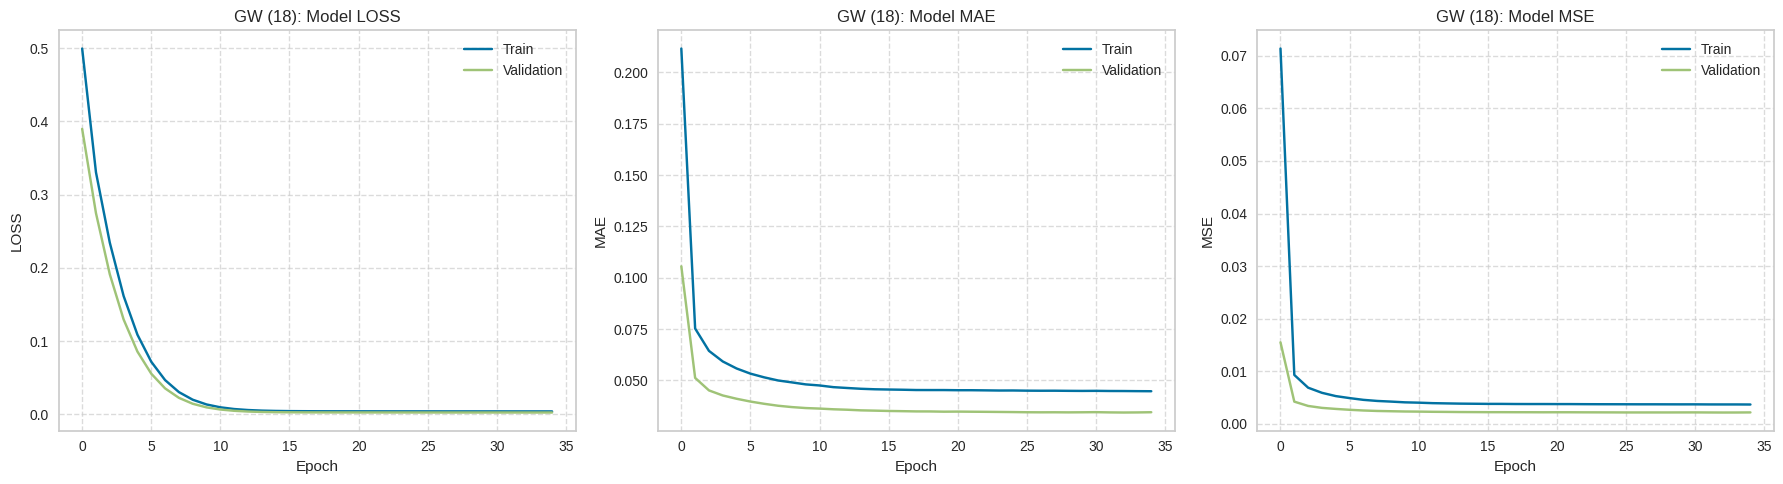

joint
Data prepared. X shape: (13518, 46), M shape: (13518, 9), Y shape: (13518, 2)

Starting Training...
Epoch 1/100
303/303 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.5180 - mae: 0.1193 - mse: 0.0249 - val_loss: 0.4197 - val_mae: 0.0652 - val_mse: 0.0069 - learning_rate: 1.0000e-04
Epoch 2/100
303/303 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3485 - mae: 0.0643 - mse: 0.0072 - val_loss: 0.2802 - val_mae: 0.0507 - val_mse: 0.0043 - learning_rate: 1.0000e-04
Epoch 3/100
303/303 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2290 - mae: 0.0567 - mse: 0.0056 - val_loss: 0.1801 - val_mae: 0.0458 - val_mse: 0.0035 - learning_rate: 1.0000e-04
Epoch 4/100
303/303 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1452 - mae: 0.0520 - mse: 0.0048 - val_loss: 0.1116 - val_mae: 0.0418 - val_mse: 0.0030 - learning_rate: 1.0000e-04
Epoch 5/100
303/303 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0891 - mae: 0.0490 - mse: 0.0043 - val_loss: 0.0667 - val_mae: 0.0391 - val_mse: 0.0026 - learning_rate: 1.0000e-04

2026-02-26 03:08:21.966710: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_16}}


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step

Generating Predictions...
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
{'fpl_name': array(['Schär', 'Leno', 'Xhaka', 'Wilson', 'Clyne', 'Henderson', 'Walker',
       'Grealish', 'Pickford', 'Virgil', 'Walker-Peters', 'Shaw',
       'Donnarumma', 'A.Becker', 'Lukić', 'Tarkowski', 'Bowen', 'Lerma',
       'Buendía', 'Casemiro', 'Areola', 'Ødegaard', 'Bernardo', 'Raúl',
       'Martinez', 'Merino', 'Bruun Larsen', 'Calvert-Lewin', 'Wilson',
       'Mukiele', 'Mateta', 'Kolo Muani', 'Wissa', 'Tielemans', 'Tete',
       'Richarlison', 'Dunk', 'Foden', 'J.Murphy', 'Lindelöf', 'Hughes',
       'Bentancur', 'Douglas Luiz', 'Milenković', 'Andersen', 'Konaté',
       'Neto', 'Hudson-Odoi', 'Dúbravka', 'Chalobah', 'C.Jones', 'Barnes',
       'Mavropanos', 'McNeil', 'Bijol', 'Todibo', 'Brooks', 'Doherty',
       'Gibbs-White', 'Saliba', 'Pedro Porro', 'Georginio', 'Kluivert',
       'Cunha', 'Isidor', 'Romero', 'Smith Rowe', 'Gyökeres', 'Dalot',
       'Saka', 'Kilm

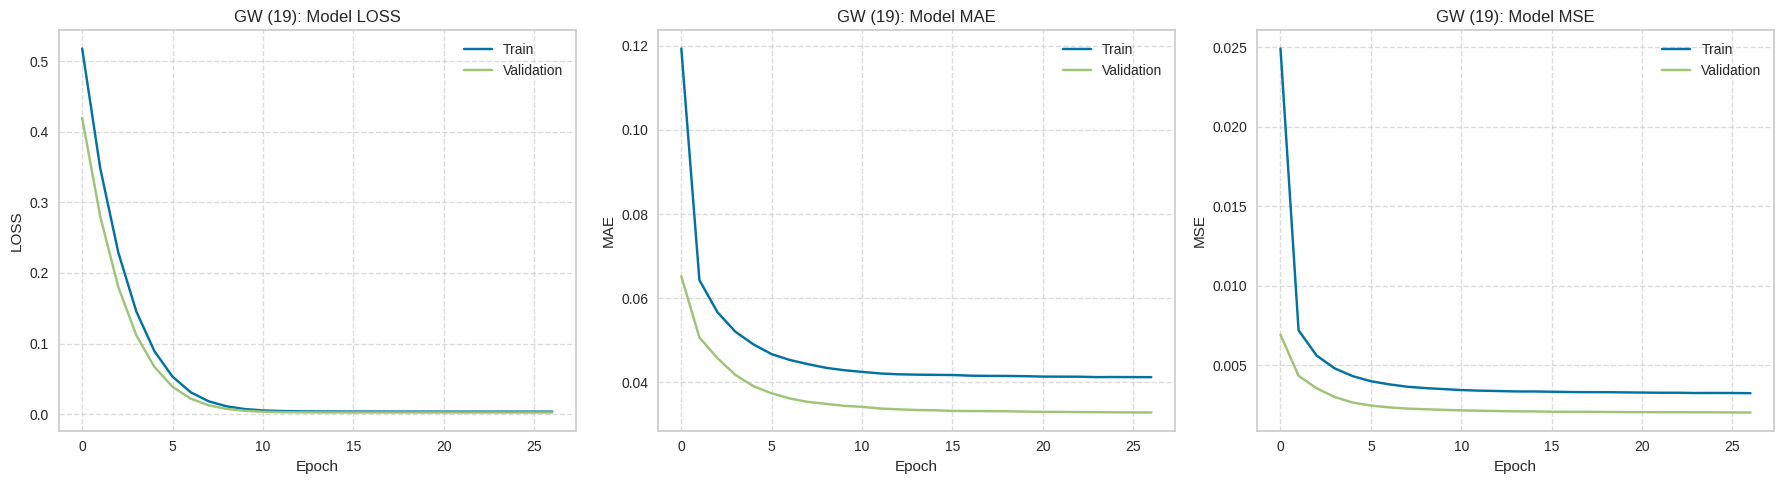

joint
Data prepared. X shape: (13518, 8), M shape: (13518, 9), Y shape: (13518, 2)

Starting Training...
Epoch 1/100
309/309 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.4137 - mae: 0.1016 - mse: 0.0186 - val_loss: 0.3285 - val_mae: 0.0692 - val_mse: 0.0069 - learning_rate: 1.0000e-04
Epoch 2/100
309/309 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2658 - mae: 0.0586 - mse: 0.0060 - val_loss: 0.2075 - val_mae: 0.0442 - val_mse: 0.0032 - learning_rate: 1.0000e-04
Epoch 3/100
309/309 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1668 - mae: 0.0535 - mse: 0.0050 - val_loss: 0.1269 - val_mae: 0.0400 - val_mse: 0.0027 - learning_rate: 1.0000e-04
Epoch 4/100
309/309 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1010 - mae: 0.0504 - mse: 0.0045 - val_loss: 0.0749 - val_mae: 0.0379 - val_mse: 0.0024 - learning_rate: 1.0000e-04
Epoch 5/100
309/309 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0594 - mae: 0.0484 - mse: 0.0042 - val_loss: 0.0428 - val_mae: 0.0364 - val_mse: 0.0023 - learning_rate: 1.0000e-04


2026-02-26 03:08:50.910571: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_16}}


8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step

Generating Predictions...
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
{'fpl_name': array(['Schär', 'Joelinton', 'Leno', 'Xhaka', 'Wilson', 'Welbeck',
       'Clyne', 'Henderson', 'Walker', 'Grealish', 'Pickford', 'Virgil',
       'Walker-Peters', 'Shaw', 'Donnarumma', 'A.Becker', 'Lukić',
       'Keane', 'Tarkowski', 'Bowen', 'Cook', 'Digne', 'Lerma', 'Buendía',
       'Casemiro', 'Areola', 'Ødegaard', 'Bernardo', 'Raúl', 'Martinez',
       'Bruun Larsen', 'G.Jesus', 'Pope', 'Rice', 'Calvert-Lewin',
       'Wilson', 'Gabriel', 'Mukiele', 'Mateta', 'Kolo Muani', 'Wissa',
       'Kamara', 'Tielemans', 'Richarlison', 'Dunk', 'Foden', 'J.Murphy',
       'Lindelöf', 'Hughes', 'Bentancur', 'Castagne', 'Milenković',
       'Andersen', 'Konaté', 'Sancho', 'Neto', 'Dúbravka', 'Chalobah',
       'C.Jones', 'Barnes', 'Mavropanos', 'McNeil', 'Bijol', 'Brooks',
       'Cairney', 'Gibbs-White', 'Saliba', 'Pedro Porro', 'Georginio',
       'Kluivert', 'Cunha', 'Jensen

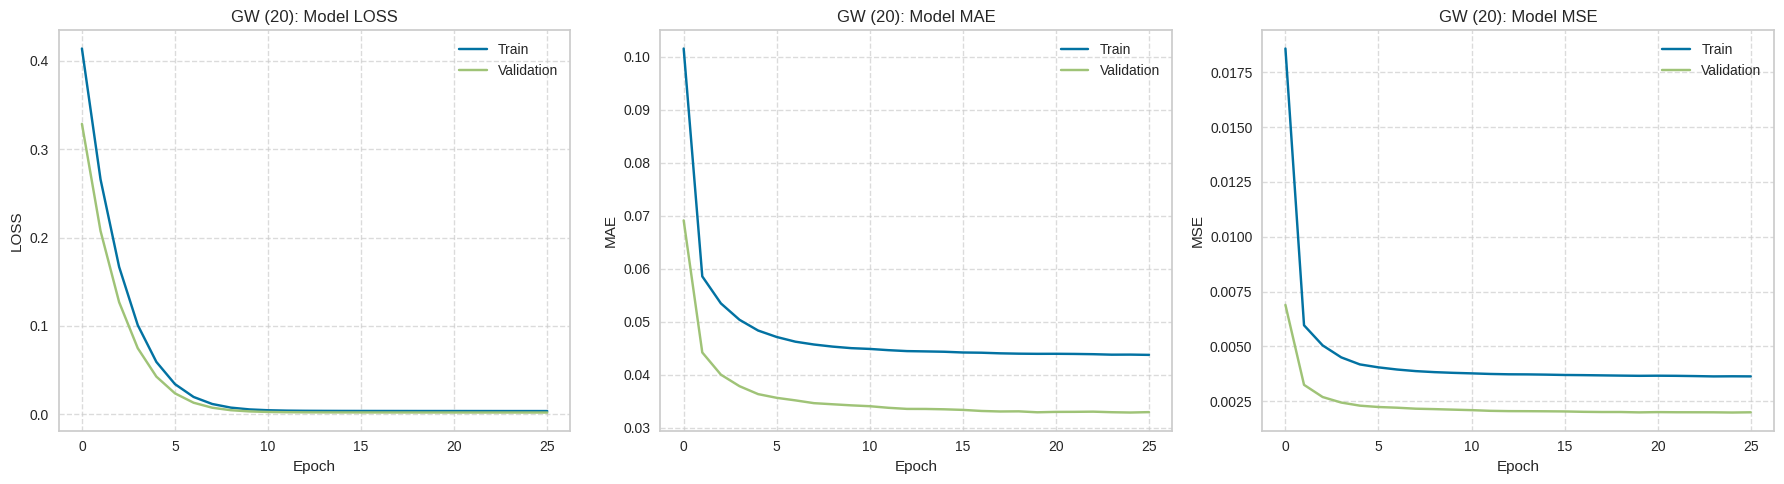

joint
Data prepared. X shape: (13518, 15), M shape: (13518, 9), Y shape: (13518, 2)

Starting Training...
Epoch 1/100
315/315 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.4225 - mae: 0.0908 - mse: 0.0147 - val_loss: 0.3325 - val_mae: 0.0589 - val_mse: 0.0052 - learning_rate: 1.0000e-04
Epoch 2/100
315/315 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2675 - mae: 0.0581 - mse: 0.0058 - val_loss: 0.2064 - val_mae: 0.0439 - val_mse: 0.0031 - learning_rate: 1.0000e-04
Epoch 3/100
315/315 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1640 - mae: 0.0522 - mse: 0.0048 - val_loss: 0.1234 - val_mae: 0.0399 - val_mse: 0.0026 - learning_rate: 1.0000e-04
Epoch 4/100
315/315 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0970 - mae: 0.0483 - mse: 0.0042 - val_loss: 0.0711 - val_mae: 0.0370 - val_mse: 0.0023 - learning_rate: 1.0000e-04
Epoch 5/100
315/315 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0555 - mae: 0.0458 - mse: 0.0038 - val_loss: 0.0395 - val_mae: 0.0353 - val_mse: 0.0022 - learning_rate: 1.0000e-04

2026-02-26 03:09:18.125973: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_16}}


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step

Generating Predictions...
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
{'fpl_name': array(['Joelinton', 'Leno', 'Xhaka', 'Aké', 'Walker', 'Grealish', 'Aina',
       'Pickford', 'Virgil', 'Walker-Peters', 'Shaw', 'Donnarumma',
       'A.Becker', 'Lukić', 'Tarkowski', 'Bowen', 'Cook', 'Digne',
       'Buendía', 'Casemiro', 'Areola', 'Rodrigo', 'Ødegaard', 'Diop',
       'Bernardo', 'Raúl', 'Martinez', 'G.Jesus', 'Pope', 'Rice',
       'Calvert-Lewin', 'Wilson', 'Gabriel', 'Mukiele', 'Mateta',
       'Kolo Muani', 'Tielemans', 'Dunk', 'Foden', 'Lindelöf', 'Hughes',
       'Castagne', 'Milenković', 'Andersen', 'Konaté', 'Sancho', 'Ampadu',
       'Neto', 'Hudson-Odoi', 'Dúbravka', 'Chalobah', 'Barnes',
       'Mavropanos', 'McNeil', 'Bijol', 'Todibo', 'Brooks', 'Cairney',
       'Gibbs-White', 'Saliba', 'Pedro Porro', 'Georginio', 'Cunha',
       'Cucurella', 'Jensen', 'Romero', 'Smith Rowe', 'Gyökeres', 'Dalot',
       'Saka', 'L.Paquetá', 'Garner', 'Zubime

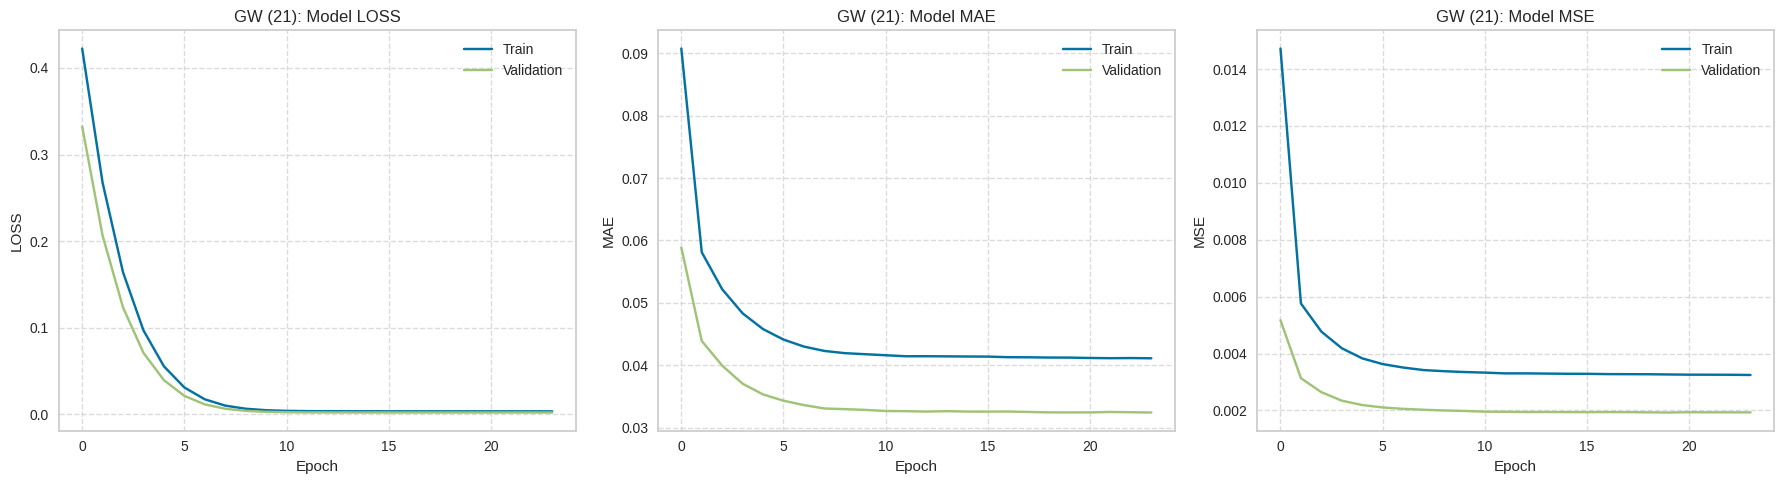

joint
Data prepared. X shape: (13518, 3), M shape: (13518, 9), Y shape: (13518, 2)

Starting Training...
Epoch 1/100
320/320 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.3928 - mae: 0.0855 - mse: 0.0127 - val_loss: 0.3069 - val_mae: 0.0717 - val_mse: 0.0072 - learning_rate: 1.0000e-04
Epoch 2/100
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.2415 - mae: 0.0580 - mse: 0.0057 - val_loss: 0.1829 - val_mae: 0.0417 - val_mse: 0.0030 - learning_rate: 1.0000e-04
Epoch 3/100
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1434 - mae: 0.0526 - mse: 0.0048 - val_loss: 0.1055 - val_mae: 0.0372 - val_mse: 0.0025 - learning_rate: 1.0000e-04
Epoch 4/100
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0820 - mae: 0.0497 - mse: 0.0044 - val_loss: 0.0585 - val_mae: 0.0357 - val_mse: 0.0023 - learning_rate: 1.0000e-04
Epoch 5/100
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0455 - mae: 0.0482 - mse: 0.0042 - val_loss: 0.0313 - val_mae: 0.0350 - val_mse: 0.0023 - learning_rate: 1.0000e-04


2026-02-26 03:09:48.143630: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_16}}


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step

Generating Predictions...
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
{'fpl_name': array(['Joelinton', 'Leno', 'Xhaka', 'Groß', 'Welbeck', 'Aké', 'Walker',
       'Aina', 'Pickford', 'Virgil', 'Shaw', 'Donnarumma', 'B.Fernandes',
       'A.Becker', 'Tarkowski', 'Bowen', 'Cook', 'Digne', 'Lerma',
       'Buendía', 'Casemiro', 'Areola', 'Rodrigo', 'Ødegaard', 'Bernardo',
       'Raúl', 'Martinez', 'Merino', 'G.Jesus', 'Pope', 'Rice',
       'Calvert-Lewin', 'Wilson', 'Gabriel', 'Mukiele', 'Mateta',
       'Kolo Muani', 'Wissa', 'Tielemans', 'Dunk', 'Foden', 'Hughes',
       'Castagne', 'Milenković', 'Andersen', 'Konaté', 'Ampadu', 'Rodon',
       'Neto', 'Hudson-Odoi', 'Dúbravka', 'Chalobah', 'C.Jones', 'Barnes',
       'Mavropanos', 'McNeil', 'Todibo', 'Cairney', 'Gibbs-White',
       'Saliba', 'Sels', 'Pedro Porro', 'Georginio', 'Cunha', 'Jensen',
       'Romero', 'Smith Rowe', 'Gyökeres', 'Dalot', 'Saka', 'Garner',
       'Zubimendi', 'Fofana', 'Trossa

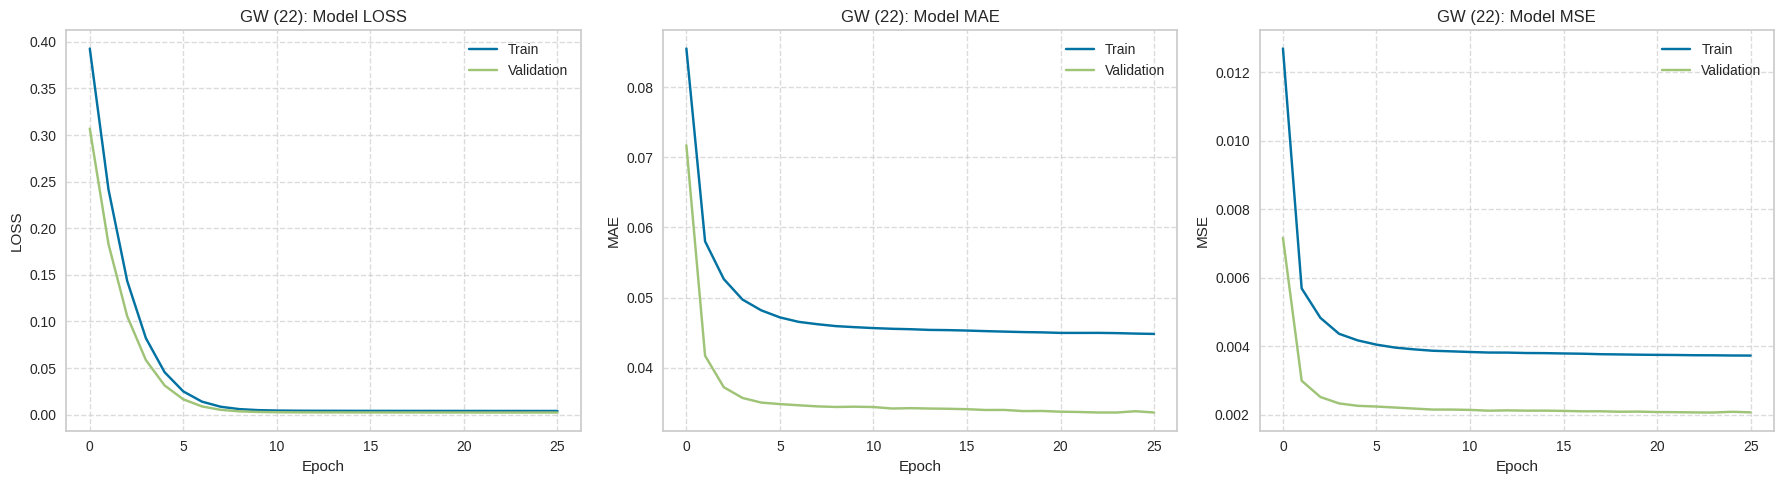

joint
Data prepared. X shape: (13518, 43), M shape: (13518, 9), Y shape: (13518, 2)

Starting Training...
Epoch 1/100
322/325 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6232 - mae: 0.2494 - mse: 0.0926

2026-02-26 03:09:53.488458: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_16}}


325/325 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.5450 - mae: 0.1709 - mse: 0.0509 - val_loss: 0.4275 - val_mae: 0.0697 - val_mse: 0.0078 - learning_rate: 1.0000e-04
Epoch 2/100
325/325 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3601 - mae: 0.0726 - mse: 0.0091 - val_loss: 0.2912 - val_mae: 0.0493 - val_mse: 0.0041 - learning_rate: 1.0000e-04
Epoch 3/100
325/325 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2412 - mae: 0.0608 - mse: 0.0064 - val_loss: 0.1909 - val_mae: 0.0436 - val_mse: 0.0032 - learning_rate: 1.0000e-04
Epoch 4/100
325/325 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1559 - mae: 0.0546 - mse: 0.0052 - val_loss: 0.1205 - val_mae: 0.0398 - val_mse: 0.0027 - learning_rate: 1.0000e-04
Epoch 5/100
325/325 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0974 - mae: 0.0505 - mse: 0.0045 - val_loss: 0.0735 - val_mae: 0.0371 - val_mse: 0.0023 - learning_rate: 1.0000e-04
Epoch 6/100
325/325 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0591 - mae: 0.0477 - mse: 0.0041 - val_loss: 0.0434 - 

2026-02-26 03:10:20.681650: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_16}}


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step

Generating Predictions...
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
{'fpl_name': array(['Leno', 'Groß', 'Wilson', 'Welbeck', 'Walker', 'Trippier', 'Aina',
       'Pickford', 'Darlow', 'Virgil', 'Tuanzebe', 'Shaw', 'Donnarumma',
       'B.Fernandes', 'A.Becker', 'Tarkowski', 'Maguire', 'Bowen', 'Cook',
       'Lerma', 'Buendía', 'Casemiro', 'Areola', 'Rodrigo', 'Ødegaard',
       'Bernardo', 'Raúl', 'Martinez', 'G.Jesus', 'Pope', 'Rice',
       'Calvert-Lewin', 'Wan-Bissaka', 'Wilson', 'Gabriel', 'Mukiele',
       'Sangaré', 'Mateta', 'Wissa', 'Tielemans', 'Dunk', 'Foden',
       'Castagne', 'Milenković', 'Pau', 'Andersen', 'Sancho', 'Ampadu',
       'Rodon', 'Neto', 'Hudson-Odoi', 'Dúbravka', 'Mbeumo', 'Chalobah',
       'C.Jones', 'Barnes', 'Mavropanos', 'McNeil', 'Todibo', 'Cairney',
       'Sessegnon', 'Gibbs-White', 'Saliba', 'Sels', 'Cunha', 'Cucurella',
       'Jensen', 'Romero', 'Smith Rowe', 'B.Badiashile', 'Gyökeres',
       'Dalot', 'White',

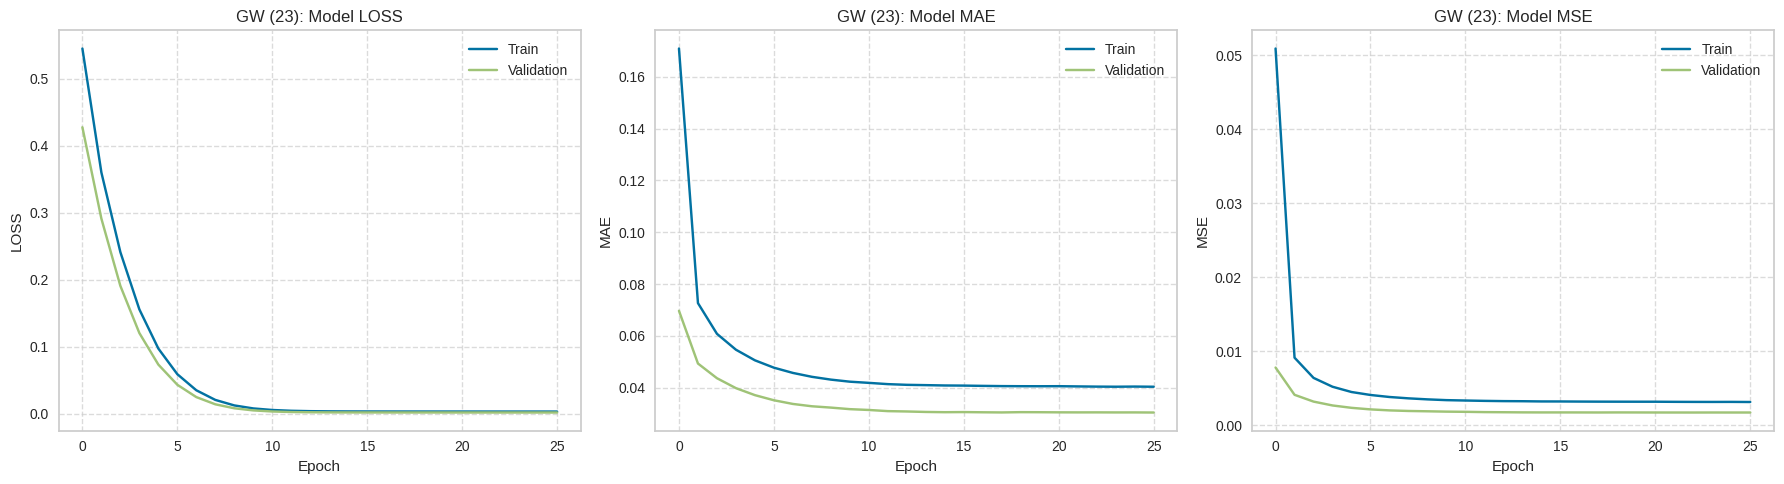

In [44]:
eval_metrics_affine_joint = {}
preds = {}
for round in range(1,24):
    history, evaluation_metrics, preds_df, _ = apnn_trainer(data, selections_24_25.loc[round, 'best_features'], round, joint=True)
    preds[round] = preds_df
    eval_metrics_affine_joint[round] = evaluation_metrics

    # Plot History
    plot_training_history(history, round)


#### Plots


In [45]:
eval_metrics_affine_joint_ = pd.DataFrame(eval_metrics_affine_joint).T
eval_metrics_affine_joint_

,test_loss,test_mae,test_mse,test_R2
1,0.004625,1.391605,3.076507,0.173771
2,0.007268,1.679960,4.823728,0.093321
3,0.002017,0.818500,1.194319,0.719181
4,0.002493,0.888407,1.467691,0.650332
5,0.001469,0.708305,0.863542,0.719568
6,0.002403,0.885367,1.477413,0.622849
7,0.001502,0.666277,0.836242,0.743727
8,0.003081,1.009140,1.933905,0.551077
9,0.001756,0.748730,1.016051,0.699401
10,0.002164,0.876966,1.317478,0.668284


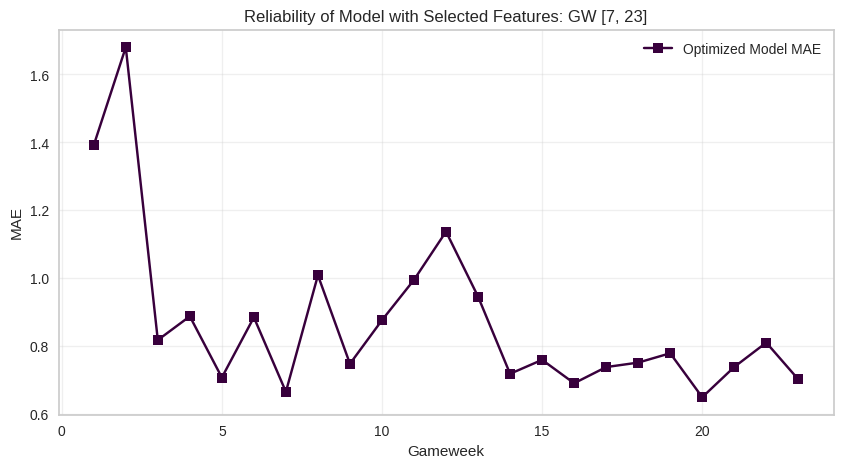

In [46]:

# --- Visualization ---
plt.figure(figsize=(10, 5))
plt.plot(eval_metrics_affine_joint_.index, eval_metrics_affine_joint_['test_mae'], marker='s', color="#38003c", label='Optimized Model MAE')
plt.title('Reliability of Model with Selected Features: GW [7, 23]', fontsize=12)
plt.xlabel('Gameweek')
plt.ylabel('MAE')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


In [61]:
selections_24_25

,best_features,optimal_count,best_overall_mae,best_lr,best_leaves
1,"[draw_prob, win_prob, lose_prob, elo, xP_rolli...",7,1.466275,0.01,31.0
2,"[draw_prob, win_prob, lose_prob, elo, xP_rolli...",50,1.45304,0.1,31.0
3,"[draw_prob, win_prob, lose_prob, elo, xP_rolli...",11,0.832033,0.05,15.0
4,"[draw_prob, win_prob, lose_prob, elo, xP_rolli...",23,0.752499,0.1,31.0
5,"[draw_prob, win_prob, lose_prob, elo, xP_rolli...",18,0.660114,0.05,31.0
6,"[draw_prob, win_prob, lose_prob, elo, xP_rolli...",42,0.914248,0.1,63.0
7,"[draw_prob, win_prob, lose_prob, elo, percenat...",11,0.665653,0.1,15.0
8,"[draw_prob, win_prob, lose_prob, elo, xP_rolli...",43,0.953405,0.1,31.0
9,"[draw_prob, win_prob, lose_prob, elo, percenat...",11,0.636587,0.05,15.0
10,"[draw_prob, win_prob, lose_prob, percenatge_ne...",18,0.758242,0.1,15.0


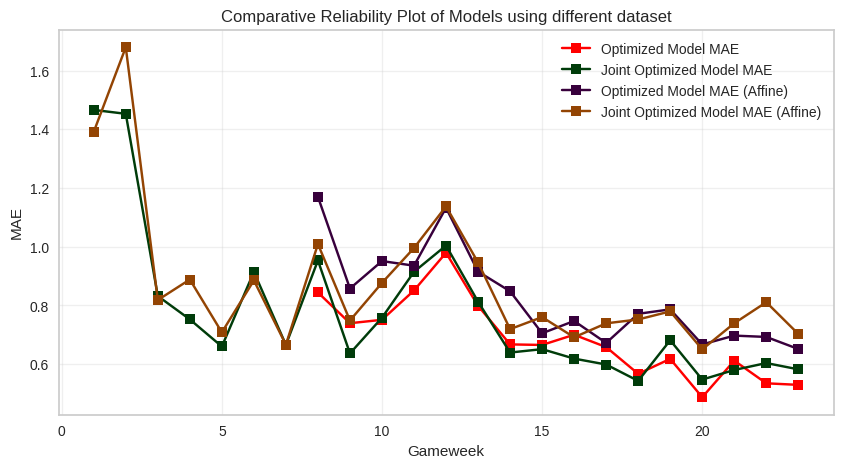

In [67]:

# --- Visualization ---
plt.figure(figsize=(10, 5))
# selections_24_25
plt.plot(selections.index, selections['best_overall_mae'], marker='s', color="#ff0000", label='Optimized Model MAE')
plt.plot(selections_24_25.index, selections_24_25['best_overall_mae'], marker='s', color="#003c0a", label='Joint Optimized Model MAE')

plt.plot(pd.DataFrame(eval_metrics_affine).T.index, pd.DataFrame(eval_metrics_affine).T['test_mae'], marker='s', color="#38003c", label='Optimized Model MAE (Affine)')
plt.plot(eval_metrics_affine_joint_.index, eval_metrics_affine_joint_['test_mae'], marker='s', color="#934403", label='Joint Optimized Model MAE (Affine)')
plt.title('Comparative Reliability Plot of Models using different dataset', fontsize=12)
plt.xlabel('Gameweek')
plt.ylabel('MAE')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()
